In [13]:
#Import Modules
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # needed for 3D projection
from matplotlib.animation import FuncAnimation
import matplotlib.cm as cm
from matplotlib.patches import Patch
import matplotlib.colors as colors
import pandas as pd
from scipy.interpolate import CubicSpline, PchipInterpolator, Akima1DInterpolator
import ctypes
from scipy import fft
import os
import sys
sys.path.append('/home/tylerhdo/.local/lib/python3.10/site-packages')
import imageio_ffmpeg
import matplotlib
from IPython.display import HTML
from pathlib import Path

# Point matplotlib to the binary
matplotlib.rcParams['animation.ffmpeg_path'] = imageio_ffmpeg.get_ffmpeg_exe()
print("ffmpeg path set to:", imageio_ffmpeg.get_ffmpeg_exe())

ffmpeg path set to: C:\Users\tydou\anaconda3\Lib\site-packages\imageio_ffmpeg\binaries\ffmpeg-win-x86_64-v7.1.exe


## Numerical Methods

#### Loading in Moisture/Cooling Profiles

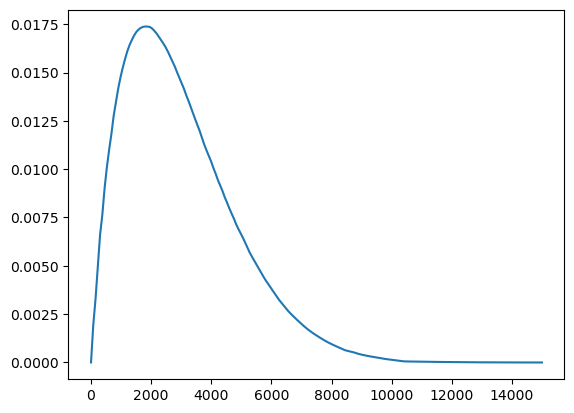

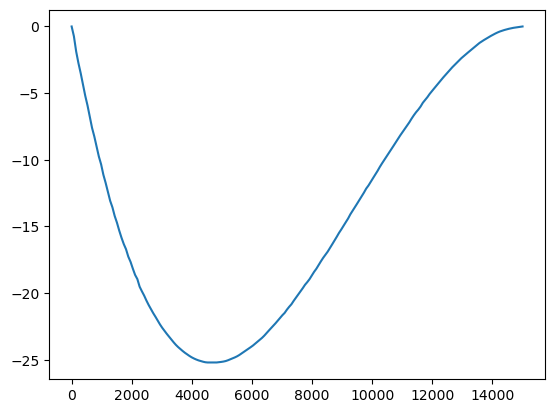

In [2]:
moisturedata = pd.read_csv('Moisture - Moisture.csv', delimiter=',')
coolingdata = pd.read_csv('Cooling - Cooling.csv', delimiter=',')
moisturedata = moisturedata.drop_duplicates().sort_values(by='y')
coolingdata = coolingdata.drop_duplicates().sort_values(by='y')
zmoist = moisturedata['y'].to_numpy()
moistz = moisturedata['x'].to_numpy()
zcool = coolingdata['y'].to_numpy()
coolz = coolingdata['x'].to_numpy()

def moistrate(x,z):
    moistrat = (PchipInterpolator(zmoist, moistz)(z/1000))/(86400*1000)
    return moistrat

def moistlooker(z):
    moistrat = (PchipInterpolator(zmoist, moistz)(z/1000))/(86400*1000)
    return moistrat 

def coolrate(x,z):
    coolrat =  (PchipInterpolator(zcool, coolz)(z/1000))/(86400)
    return coolrat

def coollooker(z):
    coolrat =  (PchipInterpolator(zcool, coolz)(z/1000))/(86400)
    return coolrat

ztau = np.linspace(0,15000, 200)
moist_int = 1/15000*np.trapz(moistlooker(ztau), ztau)
cool_int  = 1/15000*np.trapz(coollooker(ztau), ztau)

plt.plot(ztau, moistlooker(ztau)*86400)
plt.show()
plt.plot(ztau, coollooker(ztau)*86400)

## MAC Methods

#### Jacobi Method (better on Python)

In [14]:
#Defines Jacobi method
#f = vorticity , g = intial stream function guess, tol = tolerance, M = max number of iterations, L = grid size, grid = number of points, BC = B
def Jacobi(f, g, tol, M, L, grid, xBC='periodic', yBC='periodic'):

    #unpack 2d parameters (r0, L, grid, v, gamma)
    Lx, Ly = L
    I, J = grid
    
    #arrays
    R = np.zeros((I+2,J+2)) #Residual array for calculations

    #Precalculate Parameters
    dx = Lx/(I-1) #spatial step, -1 accounts for the extra boundary position
    dy = Ly/(J-1) #spatial step, -1 accounts for the extra boundary position
    x, y = np.meshgrid(np.linspace(-dx,Lx+dx,I+2), np.linspace(-dy,Ly+dy,J+2), indexing='ij') #spatial positions, including ghost nodes
    
    #Computational Parameters
    sigma = 1/(1+(dx/dy)**2) * (np.cos(np.pi/I) + (dx/dy)**2 * np.cos(np.pi/J)) 
    Dx =  1/dx**2 #parameters which appear during iteration
    Dy = 1/dy**2
    De = 2*(Dx + Dy)
    Da = 1/(2*(Dx+Dy))
    
    if xBC == 'periodic':
        xi, xf = 1, I+1
    elif xBC == 'dirichlet':
        xi, xf = 2, I
    if yBC == 'periodic':
        yi, yf = 1, J+1
    elif yBC == 'dirichlet':
        yi, yf = 2, J

    #------------------------------------------------------------------------------------------------
    #Initial conditions
    V = f
    if (xBC == 'periodic' and yBC == 'periodic'):
        V_avg = np.sum(V[1:I, 1:J])*dx*dy/(Lx*Ly) 
        m = 0
        while np.abs(V_avg) >= tol and m<=M/10:  #decreases V to be averaged at 0
            V-= V_avg
            V_avg = np.sum(V[1:I, 1:J])*dx*dy/(Lx*Ly) 
            m+=1
    psi = g
    #calculate initial residual
    R[xi:xf,yi:yf] = Dx*(psi[xi-1:xf-1,yi:yf]-2*psi[xi:xf,yi:yf]+psi[xi+1:xf+1,yi:yf]) + Dy*(psi[xi:xf,yi-1:yf-1]-2*psi[xi:xf,yi:yf]+psi[xi:xf,yi+1:yf+1]) - V[xi:xf,yi:yf]
    #calculate initial error criterion
    e = np.max(np.abs(R[xi:xf,yi:yf]))/(De*np.sum(np.abs(psi[xi:xf,yi:yf]))+np.max(np.abs(V[xi:xf,yi:yf])))
    
    # main loop
    l = 0 #initialize l for saver
    while e > tol and l<=M:
        R[xi:xf,yi:yf] = Dx*(psi[xi-1:xf-1,yi:yf]-2*psi[xi:xf,yi:yf]+psi[xi+1:xf+1,yi:yf]) + Dy*(psi[xi:xf,yi-1:yf-1]-2*psi[xi:xf,yi:yf]+psi[xi:xf,yi+1:yf+1]) - V[xi:xf,yi:yf]
        psi[xi:xf,yi:yf] += Da*R[xi:xf,yi:yf] #Jacobi iteration
        # BC
        #psi[I+1,yi:yf] = psi[2,yi:yf].copy() #updates right ghost column
        #psi[0, yi:yf] = psi[I-1,yi:yf].copy() #updates left ghost column
        #psi[xi:xf,J+1] = psi[xi:xf,2].copy() #updates top ghost row
        #psi[xi:xf,0] = psi[xi:xf,J-1].copy()  #updates bottom ghost row
        
        e = np.max(np.abs(R[xi:xf,yi:yf]))/(De*np.sum(np.abs(psi[xi:xf,yi:yf]))+np.max(np.abs(V[xi:xf,yi:yf]))) #calculates and saves max(error)
        l+=1 #iterate l for saver
     
    return l, psi

In [16]:
    #FTCS First Step:
    for n in range(1,2):
        
        #update variables
        P_o, pot_o, u_o, w_o, qt_o, qr_o = P.copy(), pot.copy(), u.copy(), w.copy(), qt.copy(), qr.copy()
        source = np.zeros_like(P_o)

        #dqr/dz (backwards in space), normally I'd update for periodic BC but I'm only using Dirichlet rn
        dqrdz = (qr_o[xi:xf, zi+1:zf+1]-qr_o[xi:xf, zi-1:zf-1])/dZ

        #Solve for new potential temperature (using semi-implicit)
        pot[xi:xf, zi:zf] = pot_o[xi:xf, zi:zf] 
        pot[xi:xf, zi:zf] += -1/2*(u_o[xi:xf, zi:zf]+u_o[xi-1:xf-1, zi:zf])*dt/dX*(pot_o[xi+1:xf+1, zi:zf]-pot_o[xi-1:xf-1, zi:zf])
        pot[xi:xf, zi:zf] += -1/2*(w_o[xi:xf, zi:zf]+w_o[xi:xf, zi-1:zf-1])*dt/dZ*(pot_o[xi:xf, zi+1:zf+1]-pot_o[xi:xf, zi-1:zf-1])
        pot[xi:xf, zi:zf] += LCp*Vt*dqrdz*dt
        pot[xi:xf, zi:zf] += (G/2)*(pot[xi+1:xf+1,zi:zf] -2*pot[xi:xf,zi:zf]+pot[xi-1:xf-1,zi:zf]) + (G/2)*(pot[xi:xf,zi+1:zf+1] -2*pot[xi:xf,zi:zf]+pot[xi:xf,zi-1:zf-1]) #FTCS diffusion
        #Potential Temp Periodic BC:
        pot[I+1,zi:zf] = pot[2,zi:zf].copy()  #updates right ghost column
        pot[0, zi:zf] = pot[I-1,zi:zf].copy()  #updates left ghost column
        pot[xi:xf, J+1] = pot[xi:xf, 2].copy()
        pot[xi:xf, 0] = pot[xi:xf, J-1].copy()

        #Solve for new qt (semi-implicit): 
        qt[xi:xf, zi:zf] = qt_o[xi:xf, zi:zf] 
        qt[xi:xf, zi:zf] += -1/2*(u_o[xi:xf, zi:zf]+u_o[xi-1:xf-1, zi:zf])*dt/dX*(qt_o[xi+1:xf+1, zi:zf]-qt_o[xi-1:xf-1, zi:zf])
        qt[xi:xf, zi:zf] += -1/2*(w_o[xi:xf, zi:zf]+w_o[xi:xf, zi-1:zf-1])*dt/dZ*(qt_o[xi:xf, zi+1:zf+1]-qt_o[xi:xf, zi-1:zf-1])
        qt[xi:xf, zi:zf] += -Vt*dqrdz*dt
        qt[xi:xf, zi:zf] += (G/2)*(qt[xi+1:xf+1,zi:zf] -2*qt[xi:xf,zi:zf]+qt[xi-1:xf-1,zi:zf]) + (G/2)*(qt[xi:xf,zi+1:zf+1] -2*qt[xi:xf,zi:zf]+qt[xi:xf,zi-1:zf-1]) #FTCS diffusion (Lie splitting)
        #qt Periodic BC:
        qt[I+1,zi:zf] = qt[2,zi:zf].copy()  #updates right ghost column
        qt[0, zi:zf] = qt[I-1,zi:zf].copy()  #updates left ghost column
        qt[xi:xf, J+1] = qt[xi:xf, 2].copy()
        qt[xi:xf, 0] = qt[xi:xf, J-1].copy() 

        #new "b" parameter for w eq.
        potinter = winterpol(pot,xi,xf,zi,zf)
        potterm = g0*(potinter - potilinter)
        qtinter = winterpol(qt,xi,xf,zi,zf)
        b = potterm + 9.8*np.where(qtinter<qvsinter, epsilon0*(qtinter-qvtilinter), (LCp/theta0 -1)*(qtinter-qvsinter) + epsilon0*(qvsinter-qvtilinter)) #calculates b for full array
        b1 = b[:,1:] #calculates b for current spatial step
        b2 = b[:,:-1] #calculates b for spatial step -1
        
        #Solve for new pressure using the discrete PPE
        u1 = -u_o[xi:xf, zi:zf]*(u_o[xi+1:xf+1, zi:zf]-u_o[xi-1:xf-1, zi:zf])/dX
        u2 = -0.25*(w_o[xi:xf, zi-1:zf-1] + w_o[xi:xf, zi:zf] + w_o[xi+1:xf+1, zi-1:zf-1]+w_o[xi+1:xf+1, zi:zf])*(u_o[xi:xf, zi+1:zf+1] - u_o[xi:xf, zi-1:zf-1])/dZ
        w1 = -w_o[xi:xf, zi:zf]*(w_o[xi:xf, zi+1:zf+1] - w_o[xi:xf, zi-1:zf-1])/dZ
        w2 = -0.25*(u_o[xi-1:xf-1,zi:zf]+u_o[xi:xf,zi:zf]+u_o[xi:xf,zi+1:zf+1]+u_o[xi-1:xf-1,zi+1:zf+1])*(w_o[xi+1:xf+1, zi:zf] - w_o[xi-1:xf-1, zi:zf])/dX
        w3 = b1

        source[xi:xf, zi:zf] = rho0[xi:xf, zi:zf]/dx*((u_o[xi:xf, zi:zf]-u_o[xi-1:xf-1, zi:zf])/dt)
        source[xi:xf, zi:zf] += rho0[xi:xf, zi:zf]/dx*(u1 + u_o[xi-1:xf-1, zi:zf]*(u_o[xi:xf, zi:zf]-u_o[xi-2:xf-2, zi:zf])/dX)
        source[xi:xf, zi:zf] += rho0[xi:xf, zi:zf]/dx*(u2)
        source[xi:xf, zi:zf] += rho0[xi:xf, zi:zf]/dx*(0.25*(w_o[xi-1:xf-1, zi-1:zf-1] + w_o[xi-1:xf-1, zi:zf] + w_o[xi:xf, zi-1:zf-1]+w_o[xi:xf, zi:zf])*(u_o[xi-1:xf-1, zi+1:zf+1] - u_o[xi-1:xf-1, zi-1:zf-1])/dZ)
        source[xi:xf, zi:zf] += rho0[xi:xf, zi:zf]/dz*((w_o[xi:xf, zi:zf]-w_o[xi:xf, zi-1:zf-1])/dt)
        source[xi:xf, zi:zf] += rho0[xi:xf, zi:zf]/dz*(w1 + w_o[xi:xf, zi-1:zf-1]*(w_o[xi:xf, zi:zf] - w_o[xi:xf, zi-2:zf-2])/dZ)
        source[xi:xf, zi:zf] += rho0[xi:xf, zi:zf]/dz*(w2)
        source[xi:xf, zi:zf] += rho0[xi:xf, zi:zf]/dz*(0.25*(u_o[xi-1:xf-1,zi-1:zf-1]+u_o[xi:xf,zi-1:zf-1]+u_o[xi:xf,zi:zf]+u_o[xi-1:xf-1,zi:zf])*(w_o[xi+1:xf+1, zi-1:zf-1] - w_o[xi-1:xf-1, zi-1:zf-1])/dX)
        source[xi:xf, zi:zf] += rho0[xi:xf, zi:zf]/dz*(w3 - b2)
        
        #calculates pressure
        l[n], P = SOR(source, P_o, tol, M, L, grid, xBC='dirichlet', yBC='dirichlet') 
        
        #Solve for new velocities using discrete PPE
        u[xi:xf, zi:zf] = u_o[xi:xf, zi:zf] - u_o[xi:xf, zi:zf]*(u_o[xi+1:xf+1, zi:zf]-u_o[xi-1:xf-1, zi:zf])*dt/dx
        u[xi:xf, zi:zf] += -0.25*(w_o[xi:xf, zi-1:zf-1] + w_o[xi:xf, zi:zf] + w_o[xi+1:xf+1, zi-1:zf-1]+w_o[xi+1:xf+1, zi:zf])*(u_o[xi:xf, zi+1:zf+1] - u_o[xi:xf, zi-1:zf-1])/dz*dt
        u[xi:xf, zi:zf] += -1/rho0[xi:xf, zi:zf]*dt/dx*(P[xi+1:xf+1,zi:zf]-P[xi:xf,zi:zf])
        u[xi:xf, zi:zf] += (S/2)*(u[xi+1:xf+1,zi:zf] -2*u[xi:xf,zi:zf]+u[xi-1:xf-1,zi:zf]) + (S/2)*(u[xi:xf,zi+1:zf+1] -2*u[xi:xf,zi:zf]+u[xi:xf,zi-1:zf-1]) #FTCS diffusion (Lie splitting)
        
        w[xi:xf, zi:zf] = w_o[xi:xf, zi:zf] -w_o[xi:xf, zi:zf]*(w_o[xi:xf, zi+1:zf+1] - w_o[xi:xf, zi-1:zf-1])/dz*dt
        w[xi:xf, zi:zf] += -0.25*(u_o[xi-1:xf-1,zi:zf]+u_o[xi:xf,zi:zf]+u_o[xi:xf,zi+1:zf+1]+u_o[xi-1:xf-1,zi+1:zf+1])*(w_o[xi+1:xf+1, zi:zf] - w_o[xi-1:xf-1, zi:zf])/dx*dt
        w[xi:xf, zi:zf] += -1/rho0inter[:,1:]*dt/dz*(P[xi:xf,zi+1:zf+1]-P[xi:xf,zi:zf]) + w3*dt 
        w[xi:xf, zi:zf] += (S/2)*(w[xi+1:xf+1,zi:zf] -2*w[xi:xf,zi:zf]+w[xi-1:xf-1,zi:zf]) + (S/2)*(w[xi:xf,zi+1:zf+1] -2*w[xi:xf,zi:zf]+w[xi:xf,zi-1:zf-1]) #FTCS diffusion (Lie splitting)

        #update piecewise variables
        qr = np.maximum(qt-qvs,0)
        qv = np.minimum(qt,qvs)
        pot_real = pot+LCp*(qt - qv)
        
        #Statistics savers:
        cons_potr[n] = np.sum(pot[1:I, 1:J])*dx*dz 
        cons_pote[n] = np.sum(pot[1:I, 1:J]+LCp*qv[1:I, 1:J])*dx*dz 
        cons_qt[n] = np.sum(qt[1:I, 1:J])*dx*dz
        C[n] = np.max(np.abs(u)*dt/dx + np.abs(w)*dt/dz) #saves max Courant number
        w_max[n] = np.max(np.abs(w))
        temp_max[n] = np.max(pot_real[1:J])        #complete solution saver
        if n % s == 0: #saves every s iterations
            P_s[m], pot_s[m], u_s[m], w_s[m], qv_s[m], qr_s[m] = P[1:-1, 1:-1], pot_real[1:-1, 1:-1], u[1:-1, 1:-1], w[1:-1, 1:-1], qv[1:-1, 1:-1], qr[1:-1, 1:-1]
            print(f"\r Save {m}!", end="", flush=True)
            m+=1

NameError: name 'P' is not defined

### SOR

In [31]:
# Load the DLL (adjust path as needed)
dll_path = r"C:\Users\tydou\AOS 180 Final\sor_solver.dll"
sor_lib = ctypes.CDLL(dll_path)

# Define argument and return types
sor_lib.SOR.argtypes = [
    ctypes.POINTER(ctypes.c_double),  # f
    ctypes.POINTER(ctypes.c_double),  # g
    ctypes.c_double,                  # tol
    ctypes.c_int,                     # M
    ctypes.c_double, ctypes.c_double, # Lx, Ly
    ctypes.c_int, ctypes.c_int,       # I, J
    ctypes.c_char_p, ctypes.c_char_p, # xBC, yBC
    ctypes.POINTER(ctypes.c_double),  # out_psi
    ctypes.POINTER(ctypes.c_int)      # out_iterations
]
sor_lib.SOR.restype = None

# Python wrapper function
def SOR(f, g, tol, M, L, grid, xBC='dirichlet', yBC='dirichlet'):
    Lx, Ly = L
    I, J = grid
    size = (I + 2) * (J + 2)

    # Flatten inputs
    f_arr = f.astype(np.float64).flatten()
    g_arr = g.astype(np.float64).flatten()
    out_psi = np.zeros_like(g_arr)
    out_iterations = ctypes.c_int()

    # Call the C++ function
    sor_lib.SOR(
        f_arr.ctypes.data_as(ctypes.POINTER(ctypes.c_double)),
        g_arr.ctypes.data_as(ctypes.POINTER(ctypes.c_double)),
        ctypes.c_double(tol), ctypes.c_int(M),
        ctypes.c_double(Lx), ctypes.c_double(Ly),
        ctypes.c_int(I), ctypes.c_int(J),
        xBC.encode(), yBC.encode(),
        out_psi.ctypes.data_as(ctypes.POINTER(ctypes.c_double)),
        ctypes.byref(out_iterations)
    )

    # Return reshaped psi and iterations
    psi = out_psi.reshape((I + 3, J + 3))
    l = out_iterations.value
    return l, psi

### Rising Thermal Solver

In [11]:
def RiseTherm(f, tol, M, L, grid, dt, T, s, theta0, rho0, vis_art, gam_art):
    
    #unpack 2d parameters (r0, L, grid, v, gamma)
    Lx, Lz = L
    I, J = grid

    #saved arrays
    N = int(T/dt+1) #number of times, including initial condition
    t = np.linspace(0, T, N)
    n_t = np.linspace(0, N-1, N)
    l = np.zeros(N) #number of iterations for each Jacobi
    C = np.zeros(N) #max absolute courant number
    w_max = np.zeros(N) #max vertical velocity
    temp_max = np.zeros(N) #maximum temperature
    K = np.zeros(N) #conservation of kinetic energy
    U = np.zeros(N) #conservation of buoyant potential energy
    
    pot_s = np.empty((int((N-1)//s+1),I,J)) #Potential Temperature
    P_s = np.empty((int((N-1)//s+1),I,J)) #x velocity 
    u_s = np.empty((int((N-1)//s+1),I,J)) #x velocity 
    w_s = np.empty((int((N-1)//s+1),I,J)) #y velocity

    #calculation arrays
    P = np.zeros((I+2,J+2)) #Current Vorticity
    pot = np.zeros((I+2,J+2)) #Current POT temprature
    u = np.zeros((I+2,J+2)) #x velocity 
    w = np.zeros((I+2,J+2)) #z velocity
    source = np.zeros((I+2,J+2)) #parameter for poisson solver
    
    #Precalculate general parameters:
    dx = Lx/(I-1) #spatial step, -1 accounts for the extra boundary position
    dz = Lz/(J-1) #spatial step, -1 accounts for the extra boundary position
    x, z = np.meshgrid(np.linspace(-dx,Lx+dx,I+2), np.linspace(-dz,Lz+dz,J+2), indexing='ij') #spatial positions, including ghost nodes
    xi, xf = 2, I #periodic X
    zi, zf = 2, J #dirichlet Y

    #Advection-Diffusion Parameters:
    dX = 2*dx
    dZ = 2*dz
    dT = 2*dt
    CX = dt/dX
    CZ = dt/dZ
    S = vis_art*dt/(dx**2) #Von Neumann number
    G = gam_art*dt/(dx**2) #gamma number, precalculated
    g0 = 9.8/theta0 #gravity in m/s^2 divided by theta_0 in Kelvin
    g1 = 9.8*rho0/(dZ*theta0) 

    #----------------------------------------------------------------
    #Initial Conditions:
    pot = f(x,z) #initialize potential temperature
    K[0] = 1/2*np.sum(u[1:I, 1:J]**2 + w[1:I, 1:J]**2)*dx*dz #save kinetic energy in m^4/s^-2    
    U[0] = 9.8/theta0*np.sum(z[1:J]*(pot[1:J]-theta0))*dx*dz #saves buoyant potential energy
    C[0] = np.max(np.abs(u)*dt/dx + np.abs(w)*dt/dz) #saves max courant number
    w_max[0] = np.max(np.abs(w))
    temp_max[0] = np.max(pot[1:J])

    #save initial conditions:
    P_s[0], pot_s[0], u_s[0], w_s[0] = P[1:-1, 1:-1], pot[1:-1, 1:-1], u[1:-1, 1:-1], w[1:-1, 1:-1]

    #----------------------------------------------------------------
    m = 1 #initialize m for saver
    #FTCS Main Loop:
    for n in range(1,N):

        #update variables
        P_o, pot_o, u_o, w_o = P.copy(), pot.copy(), u.copy(), w.copy()
        source = np.zeros_like(P_o)

        #Solve for new potential temperature (using semi-implicit)
        pot[xi:xf, zi:zf] = pot_o[xi:xf, zi:zf] 
        pot[xi:xf, zi:zf] += -1/2*(u_o[xi:xf, zi:zf]+u_o[xi-1:xf-1, zi:zf])*dt/dX*(pot_o[xi+1:xf+1, zi:zf]-pot_o[xi-1:xf-1, zi:zf])
        pot[xi:xf, zi:zf] += -1/2*(w_o[xi:xf, zi:zf]+w_o[xi:xf, zi-1:zf-1])*dt/dZ*(pot_o[xi:xf, zi+1:zf+1]-pot_o[xi:xf, zi-1:zf-1])
        pot[xi:xf, zi:zf] += (G)*(pot[xi+1:xf+1,zi:zf] -2*pot[xi:xf,zi:zf]+pot[xi-1:xf-1,zi:zf]) + (G)*(pot[xi:xf,zi+1:zf+1] -2*pot[xi:xf,zi:zf]+pot[xi:xf,zi-1:zf-1]) #FTCS diffusion (Lie splitting)
        #Potential Temp Periodic BC:
        pot[I+1,zi:zf] = pot[2,zi:zf].copy()  #updates right ghost column
        pot[0, zi:zf] = pot[I-1,zi:zf].copy()  #updates left ghost column
        pot[xi:xf, J+1] = pot[xi:xf, 2].copy()
        pot[xi:xf, 0] = pot[xi:xf, J-1].copy() 
        
        #Solve for new pressure using the discrete PPE
        u1 = -u_o[xi:xf, zi:zf]*(u_o[xi+1:xf+1, zi:zf]-u_o[xi-1:xf-1, zi:zf])/dX
        u2 = -0.25*(w_o[xi:xf, zi-1:zf-1] + w_o[xi:xf, zi:zf] + w_o[xi+1:xf+1, zi-1:zf-1]+w_o[xi+1:xf+1, zi:zf])*(u_o[xi:xf, zi+1:zf+1] - u_o[xi:xf, zi-1:zf-1])/dZ
        w1 = -w_o[xi:xf, zi:zf]*(w_o[xi:xf, zi+1:zf+1] - w_o[xi:xf, zi-1:zf-1])/dZ
        w2 = -0.25*(u_o[xi-1:xf-1,zi:zf]+u_o[xi:xf,zi:zf]+u_o[xi:xf,zi+1:zf+1]+u_o[xi-1:xf-1,zi+1:zf+1])*(w_o[xi+1:xf+1, zi:zf] - w_o[xi-1:xf-1, zi:zf])/dX
        w3 = 0.5*(g0)*(pot[xi:xf,zi+1:zf+1]+pot[xi:xf,zi:zf]-2*theta0)
        
        source[xi:xf, zi:zf] = rho0/dx*((u_o[xi:xf, zi:zf]-u_o[xi-1:xf-1, zi:zf])/dt)
        source[xi:xf, zi:zf] += rho0/dx*(u1 + u_o[xi-1:xf-1, zi:zf]*(u_o[xi:xf, zi:zf]-u_o[xi-2:xf-2, zi:zf])/dX)
        source[xi:xf, zi:zf] += rho0/dx*(u2)
        source[xi:xf, zi:zf] += rho0/dx*(0.25*(w_o[xi-1:xf-1, zi-1:zf-1] + w_o[xi-1:xf-1, zi:zf] + w_o[xi:xf, zi-1:zf-1]+w_o[xi:xf, zi:zf])*(u_o[xi-1:xf-1, zi+1:zf+1] - u_o[xi-1:xf-1, zi-1:zf-1])/dZ)

        source[xi:xf, zi:zf] += rho0/dz*((w_o[xi:xf, zi:zf]-w_o[xi:xf, zi-1:zf-1])/dt)
        source[xi:xf, zi:zf] += rho0/dz*(w1 + w_o[xi:xf, zi-1:zf-1]*(w_o[xi:xf, zi:zf] - w_o[xi:xf, zi-2:zf-2])/dZ)
        source[xi:xf, zi:zf] += rho0/dz*(w2)
        source[xi:xf, zi:zf] += rho0/dz*(0.25*(u_o[xi-1:xf-1,zi-1:zf-1]+u_o[xi:xf,zi-1:zf-1]+u_o[xi:xf,zi:zf]+u_o[xi-1:xf-1,zi:zf])*(w_o[xi+1:xf+1, zi-1:zf-1] - w_o[xi-1:xf-1, zi-1:zf-1])/dX)
        source[xi:xf, zi:zf] += rho0/dz*(w3 - 0.5*(g0)*(pot[xi:xf,zi:zf]+pot[xi:xf,zi-1:zf-1]-2*theta0))
        
        #wrap periodic BC around q to ensure stability
        #source[I+1,zi:zf] = source[2,zi:zf]  #updates right ghost column
        #source[0, zi:zf] = source[I-1,zi:zf]  #updates left ghost column
        #source[xi:xf, J+1] = source[xi:xf, 2]
        #source[xi:xf, 0] = source[xi:xf, J-1]
        
        #calculates pressure
        l[n], P = Jacobi(source, P_o, tol, M, L, grid, xBC='dirichlet', yBC='dirichlet') 
        
        #Solve for new velocities using discrete PPE 
        u[xi:xf, zi:zf] = u_o[xi:xf, zi:zf] + u1*dt
        u[xi:xf, zi:zf] += u2*dt
        u[xi:xf, zi:zf] += -1/rho0*dt/dx*(P[xi+1:xf+1,zi:zf]-P[xi:xf,zi:zf])
        u[xi:xf, zi:zf] += (S)*(u[xi+1:xf+1,zi:zf] -2*u[xi:xf,zi:zf]+u[xi-1:xf-1,zi:zf]) + (S)*(u[xi:xf,zi+1:zf+1] -2*u[xi:xf,zi:zf]+u[xi:xf,zi-1:zf-1]) #FTCS diffusion (Lie splitting)
        
        w[xi:xf, zi:zf] = w_o[xi:xf, zi:zf] + w1*dt
        w[xi:xf, zi:zf] += w2*dt
        w[xi:xf, zi:zf] += -1/rho0*dt/dz*(P[xi:xf,zi+1:zf+1]-P[xi:xf,zi:zf]) + w3*dt # (include background theta)
        w[xi:xf, zi:zf] += (S)*(w[xi+1:xf+1,zi:zf] -2*w[xi:xf,zi:zf]+w[xi-1:xf-1,zi:zf]) + (S)*(w[xi:xf,zi+1:zf+1] -2*w[xi:xf,zi:zf]+w[xi:xf,zi-1:zf-1]) #FTCS diffusion (Lie splitting)


        #Velocity Periodic BC:
        u[I+1,zi:zf] = u[2,zi:zf].copy()  #updates right ghost 
        u[0, zi:zf] = u[I-1,zi:zf].copy()  #updates left ghost 
        u[xi:xf, J+1] = u[xi:xf, 2].copy() # top ghost
        u[xi:xf, 0] = u[xi:xf, J-1].copy() # bot ghost
        w[I+1,zi:zf] = w[2,zi:zf].copy()  #updates right ghost 
        w[0, zi:zf] = w[I-1,zi:zf].copy()  #updates left ghost 
        w[xi:xf, J+1] = w[xi:xf, 2].copy() # top ghost
        w[xi:xf, 0] = w[xi:xf, J-1].copy() # bot ghost
        
        #Statistics savers:
        K[n] = 1/2*np.sum(u[1:I, 1:J]**2 + w[1:I, 1:J]**2)*dx*dz #save kinetic energy
        U[n] = g0*np.sum(z[1:J]*(pot[1:J]-theta0))*dx*dz #saves buoyant potential energy
        C[n] = np.max(np.abs(u)*dt/dx + np.abs(w)*dt/dz) #saves max Courant number
        w_max[n] = np.max(np.abs(w))
        temp_max[n] = np.max(pot[1:J])        #complete solution saver
        if n % s == 0: #saves every s iterations
            P_s[m], pot_s[m], u_s[m], w_s[m] = P[1:-1, 1:-1], pot[1:-1, 1:-1], u[1:-1, 1:-1], w[1:-1, 1:-1]
            print(f"\r Save {m}!", end="", flush=True)
            m+=1
    
    t_s = t[::s] #time for saved complete solution
    x = x[1:-1,1:-1] #redefines x and y to exclude boundary nodes
    z = z[1:-1,1:-1]

    return n_t, t, l, K, U, C, w_max, temp_max, t_s, x, z, P_s, pot_s, u_s, w_s

### FARE Model

In [50]:
def FARE(poti, qvi, ui, tol, M, L, grid, dt, T, s, pot0, f0, vis_art, gam_art, rob_filt):
    
    #unpack 2d parameters (r0, L, grid, v, gamma)
    Lx, Lz = L
    I, J = grid

    #saved arrays
    N = int(T/dt+1) #number of times, including initial condition
    t = np.linspace(0, T, N)
    n_t = np.linspace(0, N-1, N)
    l = np.zeros(N) #number of iterations for each Jacobi
    C = np.zeros(N) #max absolute courant number
    w_max = np.zeros(N) #max vertical velocity
    temp_max = np.zeros(N) #maximum potential temperature (rainy)
    cons_potr = np.zeros(N) #conservation of rainy potential temperature
    cons_pote = np.zeros(N) #conservation of equivalent potential temperature
    cons_qt = np.zeros(N) #conservation of total water
    
    pot_s = np.empty((int((N-1)//s+1),I,J)) #Potential Temperature
    qv_s = np.empty((int((N-1)//s+1),I,J)) #Water Vapor concentration
    qr_s = np.empty((int((N-1)//s+1),I,J)) #Rainwater concentration
    P_s = np.empty((int((N-1)//s+1),I,J)) #Pressure 
    u_s = np.empty((int((N-1)//s+1),I,J)) #x velocity 
    w_s = np.empty((int((N-1)//s+1),I,J)) #y velocity


    #calculation arrays
    P = np.zeros((I+3,J+3)) #Current Pressure
    pot = np.zeros((I+3,J+3)) #Current rainy POT temprature
    qt = np.zeros((I+3,J+3)) #total water
    qr = np.zeros((I+3,J+3)) #rain water
    u = np.zeros((I+3,J+3)) #x velocity 
    w = np.zeros((I+3,J+3)) #z velocity
    source = np.zeros((I+3,J+3)) #parameter for poisson solver
    
    #Precalculate general parameters:
    dx = Lx/(I-1) #spatial step, -1 accounts for the extra boundary position
    dz = Lz/(J-1) #spatial step, -1 accounts for the extra boundary position
    x, z = np.meshgrid(np.linspace(-dx,Lx+dx,I+3), np.linspace(-dz,Lz+dz,J+3), indexing='ij') #spatial positions, including ghost nodes
    xi, xf = 2, I+2 #p
    zi, zf = 2, J+2 #p Y
    #physical is from 3 to J+1, nodes 0 and J+2 are never used except in the calculation of u/w

    #Advection-Diffusion Parameters:
    dX = 2*dx
    dZ = 2*dz
    dT = 2*dt
    tauu = 14400
    CX = dt/dX
    CZ = dt/dZ
    Sx = vis_art*dt/(dx**2) #Von Neumann number
    Sz = vis_art*dt/(dz**2)
    Gx = gam_art*dt/(dx**2) #gamma number, precalculated
    Gz = gam_art*dt/(dz**2)
    g0 = 9.8/theta0 #gravity in m/s^2 divided by theta_0 in Kelvin

    #define helper functions:
    def winterpol(arr):
        return 0.5*(arr[xi:xf,zi:zf+1]+arr[xi:xf,zi-1:zf])
    
    #-------------------------------------------------------------------------------
    #Initial Conditions:
    pot = poti(x,z) #initialize potential temperature
    potil = pot0(x,z) #initialize background potential temperature
    pot0_s = pot0(x,z)[2:-1, 2:-1] # save background for analysis
    DpotilBS = (potil[xi:xf,zi:zf+1]-potil[xi:xf,zi-1:zf])/dz #Neumann BC
    DpotilCS = (potil[xi:xf,zi+1:zf+1]-potil[xi:xf,zi-1:zf-1])/dZ #Neumann BC
    ubg = ui(x,z)
    u = ubg.copy()
    qvtil = qvi(x,z)
    DqvtilBS = (qvtil[xi:xf,zi:zf+1]-qvtil[xi:xf,zi-1:zf])/dz #Neumann BC
    DqvtilCS = (qvtil[xi:xf,zi+1:zf+1]-qvtil[xi:xf,zi-1:zf-1])/dZ #Neumann BC
    f0 = f0(x,z)
    P0 = f0**(CpRd)
    qt = qvtil.copy() 
    qvs = qvso/f0**(CpRd)*np.exp(-LL/Rv * (1/(f0*potil) -1/theta0))
    rho0 = p0/(Rd*potil)*f0**(CpRd-1) #background density
    potilinter = winterpol(potil,xi,xf,zi,zf)
    potilinterw = winterpol(potil,2,I+2,2,J+1)
    qvtilinter = winterpol(qvtil,xi,xf,zi,zf)
    qvtilinterw = winterpol(qvtil,2,I+2,2,J+1)
    qvsinter = winterpol(qvs,xi,xf,zi,zf)
    qvsinterw = winterpol(qvs,2,I+2,2,J+1)
    rho0inter = winterpol(rho0,xi,xf,zi,zf)
    rho0interw = winterpol(rho0,2,I+2,2,J+1)
    coolingprof = coolrate(x,z)
    moistenprof = moistrate(x,z)
    lengthmulti = 0/Lx
    
    #piecewise variables
    qr = np.maximum(qt-qvs,0)
    qv = np.minimum(qt,qvs)
    pot_real = pot+LCp*(qt - qv)
    
    #statistics
    cons_potr[0] = np.sum(pot[2:I+1, 2:J+1])*dx*dz 
    cons_pote[0] = np.sum(pot[2:I+1, 2:J+1]+LCp*qv[2:I+1, 2:J+1])*dx*dz 
    cons_qt[0] = np.sum(qt[2:I+1, 2:J+1])*dx*dz
    C[0] = np.max(np.abs(u)*dt/dx + np.abs(w)*dt/dz) #saves max Courant number
    w_max[0] = np.max(np.abs(w))
    temp_max[0] = np.max(pot[2:J+1])

    #save initial conditions:
    P_s[0], pot_s[0], u_s[0], w_s[0], qv_s[0], qr_s[0] = P[2:-1, 2:-1], pot_real[2:-1, 2:-1], u[2:-1, 2:-1], w[2:-1, 2:-1], qv[2:-1, 2:-1], qr[2:-1, 2:-1]

    #--------------------------------------------------------------------------------
    #===================================================================================================================================================================================================
    m = 1 #initialize m for saver

    P_o, pot_o, u_o, w_o, qt_o, qr_o = P.copy(), pot.copy(), u.copy(), w.copy(), qt.copy(), qr.copy() 
    #FTBS first step
    for n in range(1,2):

        #update variables
        P_O, pot_O, u_O, w_O, qt_O, qr_O = P_o.copy(), pot_o.copy(), u_o.copy(), w_o.copy(), qt_o.copy(), qr_o.copy()
        P_o, pot_o, u_o, w_o, qt_o, qr_o = P.copy(), pot.copy(), u.copy(), w.copy(), qt.copy(), qr.copy()
        source = np.zeros_like(P_o)

        #reset x,z to default neumann BC
        xi = 2
        xf = I+2
        zi = 2
        zf = J+2
        
        #dqr/dz (backwards in space)
        dqrdz = (qr_o[xi:xf, zi+1:zf+1]-qr_o[xi:xf, zi:zf])/dz

        #Solve for new potential temperature
        pot[xi:xf, zi:zf] = pot_o[xi:xf, zi:zf] 
        pot[xi:xf, zi:zf] += -1/2*(u_o[xi:xf, zi:zf]+u_o[xi-1:xf-1, zi:zf])*dt/dx*(pot_o[xi:xf, zi:zf]-pot_o[xi-1:xf-1, zi:zf])
        pot[xi:xf, zi:zf] += -1/2*(w_o[xi:xf, zi:zf]+w_o[xi:xf, zi-1:zf-1])*dt/dz*(pot_o[xi:xf, zi:zf]-pot_o[xi:xf, zi-1:zf-1])
        pot[xi:xf, zi:zf] += -LCp*Vt*dqrdz*dt
        pot[xi:xf, zi:zf] += coolingprof[xi:xf, zi:zf]*dt*lengthmulti #cooling rate
        pot[xi:xf, zi:zf] += (Gx)*(pot[xi+1:xf+1,zi:zf] -2*pot[xi:xf,zi:zf]+pot[xi-1:xf-1,zi:zf]) + (Gz)*(pot[xi:xf,zi+1:zf+1] -2*pot[xi:xf,zi:zf]+pot[xi:xf,zi-1:zf-1]) #FTCS diffusion
        #X Periodic BC:
        pot[I+2,zi:zf] = pot[3,zi:zf].copy()  #updates right ghost column
        pot[1, zi:zf] = pot[I,zi:zf].copy()  #updates left ghost column
        #Z Neumann BC: df/dz = dfbackground/dz
        pot[xi:xf, J+2] = pot[xi:xf, J+1].copy() + DpotilBS[:,-1]*dz
        pot[xi:xf, 1] = pot[xi:xf, 2].copy() - DpotilBS[:,0]*dz

        #Solve for new qt
        qt[xi:xf, zi:zf] = qt_o[xi:xf, zi:zf] 
        qt[xi:xf, zi:zf] += -1/2*(u_o[xi:xf, zi:zf]+u_o[xi-1:xf-1, zi:zf])*dt/dx*(qt_o[xi:xf, zi:zf]-qt_o[xi-1:xf-1, zi:zf])
        qt[xi:xf, zi:zf] += -1/2*(w_o[xi:xf, zi:zf]+w_o[xi:xf, zi-1:zf-1])*dt/dz*(qt_o[xi:xf, zi:zf]-qt_o[xi:xf, zi-1:zf-1])
        qt[xi:xf, zi:zf] += Vt*dqrdz*dt
        qt[xi:xf, zi:zf] += moistenprof[xi:xf, zi:zf]*dt*lengthmulti #moistening rate
        qt[xi:xf, zi:zf] += (Gx)*(qt[xi+1:xf+1,zi:zf] -2*qt[xi:xf,zi:zf]+qt[xi-1:xf-1,zi:zf]) + (Gz)*(qt[xi:xf,zi+1:zf+1] -2*qt[xi:xf,zi:zf]+qt[xi:xf,zi-1:zf-1]) #FTCS diffusion (Lie splitting)
        #X Periodic BC:
        qt[I+2,zi:zf] = qt[3,zi:zf].copy()  #updates right ghost column
        qt[1, zi:zf] = qt[I,zi:zf].copy()  #updates left ghost column
        #Z Neumann BC: df/dz = 0
        qt[xi:xf, J+2] = qt[xi:xf, J+1].copy() + DqvtilBS[:,-1]*dz
        qt[xi:xf, 1] = qt[xi:xf, 2].copy() - DqvtilBS[:,0]*dz
        
        #new "b" parameter for w eq.
        potinter = winterpol(pot_o,xi,xf,zi,zf)
        potterm = g0*(potinter - potilinter)
        qtinter = winterpol(qt_o,xi,xf,zi,zf)
        b = potterm + 9.8*np.where(qtinter<qvsinter, epsilon0*(qtinter-qvtilinter), (LCp/theta0 -1)*(qtinter-qvsinter) + epsilon0*(qvsinter-qvtilinter)) #calculates b for full array
        b1 = b[:,1:] #calculates b for current spatial step
        b2 = b[:,:-1] #calculates b for spatial step -1
        
        #Solve for new pressure using the discrete PPE
        u1 = -u_o[xi:xf, zi:zf]*(u_o[xi+1:xf+1, zi:zf]-u_o[xi-1:xf-1, zi:zf])/dX
        u2 = -0.25*(w_o[xi:xf, zi-1:zf-1] + w_o[xi:xf, zi:zf] + w_o[xi+1:xf+1, zi-1:zf-1]+w_o[xi+1:xf+1, zi:zf])*(u_o[xi:xf, zi+1:zf+1] - u_o[xi:xf, zi-1:zf-1])/dZ
        w1 = -w_o[xi:xf, zi:zf]*(w_o[xi:xf, zi+1:zf+1] - w_o[xi:xf, zi-1:zf-1])/dZ
        w2 = -0.25*(u_o[xi-1:xf-1,zi:zf]+u_o[xi:xf,zi:zf]+u_o[xi:xf,zi+1:zf+1]+u_o[xi-1:xf-1,zi+1:zf+1])*(w_o[xi+1:xf+1, zi:zf] - w_o[xi-1:xf-1, zi:zf])/dX
        w3 = b1
        
        source[xi:xf, zi:zf] = rho0[xi:xf, zi:zf]/dx*((u_o[xi:xf, zi:zf]-u_o[xi-1:xf-1, zi:zf])/dt)
        source[xi:xf, zi:zf] += rho0[xi:xf, zi:zf]/dx*(u1 + u_o[xi-1:xf-1, zi:zf]*(u_o[xi:xf, zi:zf]-u_o[xi-2:xf-2, zi:zf])/dX)
        source[xi:xf, zi:zf] += rho0[xi:xf, zi:zf]/dx*(u2)
        source[xi:xf, zi:zf] += rho0[xi:xf, zi:zf]/dx*(0.25*(w_o[xi-1:xf-1, zi-1:zf-1] + w_o[xi-1:xf-1, zi:zf] + w_o[xi:xf, zi-1:zf-1]+w_o[xi:xf, zi:zf])*(u_o[xi-1:xf-1, zi+1:zf+1] - u_o[xi-1:xf-1, zi-1:zf-1])/dZ)
        source[xi:xf, zi:zf] += rho0[xi:xf, zi:zf]/dz*((w_o[xi:xf, zi:zf]-w_o[xi:xf, zi-1:zf-1])/dt)
        source[xi:xf, zi:zf] += rho0[xi:xf, zi:zf]/dz*(w1 + w_o[xi:xf, zi-1:zf-1]*(w_o[xi:xf, zi:zf] - w_o[xi:xf, zi-2:zf-2])/dZ)
        source[xi:xf, zi:zf] += rho0[xi:xf, zi:zf]/dz*(w2)
        source[xi:xf, zi:zf] += rho0[xi:xf, zi:zf]/dz*(0.25*(u_o[xi-1:xf-1,zi-1:zf-1]+u_o[xi:xf,zi-1:zf-1]+u_o[xi:xf,zi:zf]+u_o[xi-1:xf-1,zi:zf])*(w_o[xi+1:xf+1, zi-1:zf-1] - w_o[xi-1:xf-1, zi-1:zf-1])/dX)
        source[xi:xf, zi:zf] += rho0[xi:xf, zi:zf]/dz*(w3 - b2)
        #X Periodic BC:
        source[I+2,zi:zf] = source[3,zi:zf].copy()  #updates right ghost column
        source[1, zi:zf] = source[I,zi:zf].copy()  #updates left ghost column
        #Z Neumann BC: df/dz = 0
        source[xi:xf, J+2] = source[xi:xf, J+1].copy()
        source[xi:xf, 1] = source[xi:xf, 2].copy()
        
        #calculates pressure
        l[n], P = SOR(source, P_o, tol, M, L, grid, xBC='periodic', yBC='periodic') # y BC is technically actually Neumann (the SOR implements this)
        #l[n], P = FFTSolver(source, P_o, tol, M, L, grid, xBC='periodic', yBC='neumann')

        #Staggered grid BC (x per, z neu higher/diri lower)
        xi = 1
        xf = I+2
        zi = 3
        zf = J+2
        #Solve for new velocities using discrete PPE
        u[xi:xf, zi:zf] = u_o[xi:xf, zi:zf] - u_o[xi:xf, zi:zf]*(u_o[xi:xf, zi:zf]-u_o[xi-1:xf-1, zi:zf])*dt/dx
        u[xi:xf, zi:zf] += -0.25*(w_o[xi:xf, zi-1:zf-1] + w_o[xi:xf, zi:zf] + w_o[xi+1:xf+1, zi-1:zf-1]+w_o[xi+1:xf+1, zi:zf])*(u_o[xi:xf, zi:zf] - u_o[xi:xf, zi-1:zf-1])/dz*dt
        u[xi:xf, zi:zf] += -2/(rho0[xi:xf, zi:zf]+rho0[xi+1:xf+1, zi:zf])*dt/dx*(P[xi+1:xf+1,zi:zf]-P[xi:xf,zi:zf])
        u[xi:xf, zi:zf] += -1/tauu*(np.mean(u_o[1:I+1, zi:zf], axis=0)-ubg[xi:xf, zi:zf])*dt #relaxation to ubg
        u[xi:xf, zi:zf] += (Sx)*(u[xi+1:xf+1,zi:zf] -2*u[xi:xf,zi:zf]+u[xi-1:xf-1,zi:zf]) + (Sz)*(u[xi:xf,zi+1:zf+1] -2*u[xi:xf,zi:zf]+u[xi:xf,zi-1:zf-1]) #FTCS diffusion (Lie splitting)
        
        #X Periodic BC:
        u[I+2,zi:zf] = u[2,zi:zf].copy()  #updates right ghost column
        u[0, zi:zf] = u[I,zi:zf].copy()  #updates left ghost column
        # Top Z Neumann BC: df/dz = 0
        u[xi:xf, J+2] = u[xi:xf, J+1].copy()

        #X periodic, Y Dirichlet both
        xi = 2
        xf = I+2
        zi = 2
        zf = J+1
        
        potinterw = winterpol(pot_o,xi,xf,zi,zf)
        pottermw = g0*(potinterw - potilinterw)
        qtinterw = winterpol(qt_o,xi,xf,zi,zf)
        b = pottermw + 9.8*np.where(qtinterw<qvsinterw, epsilon0*(qtinterw-qvtilinterw), (LCp/theta0 -1)*(qtinterw-qvsinterw) + epsilon0*(qvsinterw-qvtilinterw)) #calculates b for full array
        b1 = b[:,1:] #calculates b for current spatial step
        w3 = b1

        w[xi:xf, zi:zf] = w_o[xi:xf, zi:zf] -w_o[xi:xf, zi:zf]*(w_o[xi:xf, zi:zf] - w_o[xi:xf, zi-1:zf-1])/dz*dt
        w[xi:xf, zi:zf] += -0.25*(u_o[xi-1:xf-1,zi:zf]+u_o[xi:xf,zi:zf]+u_o[xi:xf,zi+1:zf+1]+u_o[xi-1:xf-1,zi+1:zf+1])*(w_o[xi:xf, zi:zf] - w_o[xi-1:xf-1, zi:zf])/dx*dt
        w[xi:xf, zi:zf] += -1/rho0interw[:,1:]*dt/dz*(P[xi:xf,zi+1:zf+1]-P[xi:xf,zi:zf]) + w3*dt 
        w[xi:xf, zi:zf] += (Sx)*(w[xi+1:xf+1,zi:zf] -2*w[xi:xf,zi:zf]+w[xi-1:xf-1,zi:zf]) + (Sz)*(w[xi:xf,zi+1:zf+1] -2*w[xi:xf,zi:zf]+w[xi:xf,zi-1:zf-1]) #FTCS diffusion (Lie splitting)
        #X Periodic BC:
        w[I+2,zi:zf] = w[3,zi:zf].copy()  #updates right ghost column
        w[1, zi:zf] = w[I,zi:zf].copy()  #updates left ghost column

        #update piecewise variables
        xi, xf, zi, zf = 2, I+2, 2, J+2
        qr = np.maximum(qt-qvs,0)
        qv = np.minimum(qt,qvs)
        pot_real = pot+LCp*(qt - qv)

        #X Periodic BC:
        qr[I+2,zi:zf] = qr[3,zi:zf].copy()  #updates right ghost column
        qr[1, zi:zf] = qr[I,zi:zf].copy()  #updates left ghost column
        #Z Neumann BC: df/dz = dfbackground/dz
        qr[xi:xf, J+2] = qr[xi:xf, J+1].copy()
        qr[xi:xf, 1] = qr[xi:xf, 2].copy()
        
        #Statistics savers:
        cons_potr[n] = np.sum(pot[2:I+1, 2:J+1])*dx*dz 
        cons_pote[n] = np.sum(pot[2:I+1, 2:J+1]+LCp*qv[2:I+1, 2:J+1])*dx*dz 
        cons_qt[n] = np.sum(qt[2:I+1, 2:J+1])*dx*dz
        C[n] = np.max(np.abs(u)*dt/dx + np.abs(w)*dt/dz) #saves max Courant number
        w_max[n] = np.max(np.abs(w))
        temp_max[n] = np.max(pot_real[2:J+1])        #complete solution saver
        if n % s == 0: #saves every s iterations
            P_s[m], pot_s[m], u_s[m], w_s[m], qv_s[m], qr_s[m] = P[2:-1, 2:-1], pot_real[2:-1, 2:-1], u[2:-1, 2:-1], w[2:-1, 2:-1], qv[2:-1, 2:-1], qr[2:-1, 2:-1]
            print(f"\r Save {m}!", end="", flush=True)
            m+=1
    
    #-------------------------------------------------------------------------------------------------------------------------------------------------------------
    #===================================================================================================================================================================================================
    
    #CTCS Second Step:
    for n in range(2,3):
        
        #reset x,z to default neumann BC
        xi = 2
        xf = I+2
        zi = 2
        zf = J+2
        
        #update variables
        P_O, pot_O, u_O, w_O, qt_O, qr_O = P_o.copy(), pot_o.copy(), u_o.copy(), w_o.copy(), qt_o.copy(), qr_o.copy()
        P_o, pot_o, u_o, w_o, qt_o, qr_o = P.copy(), pot.copy(), u.copy(), w.copy(), qt.copy(), qr.copy()

        source = np.zeros_like(P_o)

        #dqr/dz (B in space)
        dqrdz = (qr_o[xi:xf, zi+1:zf+1]-qr_o[xi:xf, zi-1:zf-1])/dZ

        #Solve for new potential temperature
        pot[xi:xf, zi:zf] = pot_O[xi:xf, zi:zf] 
        pot[xi:xf, zi:zf] += -1/2*(u_o[xi:xf, zi:zf]+u_o[xi-1:xf-1, zi:zf])*dT/dX*(pot_o[xi+1:xf+1, zi:zf]-pot_o[xi-1:xf-1, zi:zf])
        pot[xi:xf, zi:zf] += -1/2*(w_o[xi:xf, zi:zf]+w_o[xi:xf, zi-1:zf-1])*dT/dZ*(pot_o[xi:xf, zi+1:zf+1]-pot_o[xi:xf, zi-1:zf-1])
        pot[xi:xf, zi:zf] += -LCp*Vt*dqrdz*dT
        pot[xi:xf, zi:zf] += coolingprof[xi:xf, zi:zf]*dT*lengthmulti #cooling rate
        pot[xi:xf, zi:zf] += (2*Gx)*(pot_O[xi+1:xf+1,zi:zf] -2*pot_O[xi:xf,zi:zf]+pot_O[xi-1:xf-1,zi:zf]) + (2*Gz)*(pot_O[xi:xf,zi+1:zf+1] -2*pot_O[xi:xf,zi:zf]+pot_O[xi:xf,zi-1:zf-1]) #FTCS diffusion (2 steps)   
        #X Periodic BC:
        pot[I+2,zi:zf] = pot[3,zi:zf].copy()  #updates right ghost column
        pot[1, zi:zf] = pot[I,zi:zf].copy()  #updates left ghost column
        #Z Neumann BC: df/dz = 0
        #pot[xi:xf, J+2] = pot[xi:xf, J].copy() + DpotilCS[:,-1]*dZ
        pot[xi:xf, J+2] = pot[xi:xf, J] - potil[xi:xf, J] + potil[xi:xf, J+2]
        #pot[xi:xf, 1] = pot[xi:xf, 3].copy() - DpotilCS[:,0]*dZ
        pot[xi:xf, 1]   = pot[xi:xf, 3]   - potil[xi:xf, 3]   + potil[xi:xf, 1]
        pot_o[xi:xf, zi:zf] = pot_o[xi:xf, zi:zf] + rob_filt*(pot_O[xi:xf, zi:zf]-2*pot_o[xi:xf, zi:zf] + pot[xi:xf, zi:zf])

        #Solve for new qt
        qt[xi:xf, zi:zf] = qt_O[xi:xf, zi:zf] 
        qt[xi:xf, zi:zf] += -1/2*(u_o[xi:xf, zi:zf]+u_o[xi-1:xf-1, zi:zf])*dT/dX*(qt_o[xi+1:xf+1, zi:zf]-qt_o[xi-1:xf-1, zi:zf])
        qt[xi:xf, zi:zf] += -1/2*(w_o[xi:xf, zi:zf]+w_o[xi:xf, zi-1:zf-1])*dT/dZ*(qt_o[xi:xf, zi+1:zf+1]-qt_o[xi:xf, zi-1:zf-1])
        qt[xi:xf, zi:zf] += Vt*dqrdz*dT
        qt[xi:xf, zi:zf] += moistenprof[xi:xf, zi:zf]*dT*lengthmulti #moistening rate
        qt[xi:xf, zi:zf] += (2*Gx)*(qt_O[xi+1:xf+1,zi:zf] -2*qt_O[xi:xf,zi:zf]+qt_O[xi-1:xf-1,zi:zf]) + (2*Gz)*(qt_O[xi:xf,zi+1:zf+1] -2*qt_O[xi:xf,zi:zf]+qt_O[xi:xf,zi-1:zf-1]) #FTCS diffusion (2 steps)
        #X Periodic BC:
        qt[I+2,zi:zf] = qt[3,zi:zf].copy()  #updates right ghost column
        qt[1, zi:zf] = qt[I,zi:zf].copy()  #updates left ghost column
        #Z Neumann BC: df/dz = 0
        #qt[xi:xf, J+2] = qt[xi:xf, J].copy() + DqvtilCS[:,-1]*dZ
        qt[xi:xf, J+2] = qt[xi:xf, J] - qvtil[xi:xf, J] + qvtil[xi:xf, J+2]
        #qt[xi:xf, 1] = qt[xi:xf, 3].copy() - DqvtilCS[:,0]*dZ
        qt[xi:xf, 1]   = qt[xi:xf, 3]   - qvtil[xi:xf, 3]   + qvtil[xi:xf, 1]
        qt_o[xi:xf, zi:zf] = qt_o[xi:xf, zi:zf] + rob_filt*(qt_O[xi:xf, zi:zf]-2*qt_o[xi:xf, zi:zf] + qt[xi:xf, zi:zf])

        #new "b" parameter for w eq.
        potinter = winterpol(pot_o,xi,xf,zi,zf)
        potterm = g0*(potinter - potilinter)
        qtinter = winterpol(qt_o,xi,xf,zi,zf)
        b = potterm + 9.8*np.where(qtinter<qvsinter, epsilon0*(qtinter-qvtilinter), (LCp/theta0 -1)*(qtinter-qvsinter) + epsilon0*(qvsinter-qvtilinter)) #calculates b for full array
        
        b1 = b[:,1:] #calculates b for current spatial step
        b2 = b[:,:-1] #calculates b for spatial step -1
        
        #Solve for new pressure using the discrete PPE
        u1 = -u_o[xi:xf, zi:zf]*(u_o[xi+1:xf+1, zi:zf]-u_o[xi-1:xf-1, zi:zf])/dX
        u2 = -0.25*(w_o[xi:xf, zi-1:zf-1] + w_o[xi:xf, zi:zf] + w_o[xi+1:xf+1, zi-1:zf-1]+w_o[xi+1:xf+1, zi:zf])*(u_o[xi:xf, zi+1:zf+1] - u_o[xi:xf, zi-1:zf-1])/dZ
        w1 = -w_o[xi:xf, zi:zf]*(w_o[xi:xf, zi+1:zf+1] - w_o[xi:xf, zi-1:zf-1])/dZ
        w2 = -0.25*(u_o[xi-1:xf-1,zi:zf]+u_o[xi:xf,zi:zf]+u_o[xi:xf,zi+1:zf+1]+u_o[xi-1:xf-1,zi+1:zf+1])*(w_o[xi+1:xf+1, zi:zf] - w_o[xi-1:xf-1, zi:zf])/dX
        w3 = b1

        source[xi:xf, zi:zf] = rho0[xi:xf, zi:zf]/dx*((u_o[xi:xf, zi:zf]-u_o[xi-1:xf-1, zi:zf])/dt)
        source[xi:xf, zi:zf] += rho0[xi:xf, zi:zf]/dx*(u1 + u_o[xi-1:xf-1, zi:zf]*(u_o[xi:xf, zi:zf]-u_o[xi-2:xf-2, zi:zf])/dX)
        source[xi:xf, zi:zf] += rho0[xi:xf, zi:zf]/dx*(u2)
        source[xi:xf, zi:zf] += rho0[xi:xf, zi:zf]/dx*(0.25*(w_o[xi-1:xf-1, zi-1:zf-1] + w_o[xi-1:xf-1, zi:zf] + w_o[xi:xf, zi-1:zf-1]+w_o[xi:xf, zi:zf])*(u_o[xi-1:xf-1, zi+1:zf+1] - u_o[xi-1:xf-1, zi-1:zf-1])/dZ)
        source[xi:xf, zi:zf] += rho0[xi:xf, zi:zf]/dz*((w_o[xi:xf, zi:zf]-w_o[xi:xf, zi-1:zf-1])/dt)
        source[xi:xf, zi:zf] += rho0[xi:xf, zi:zf]/dz*(w1 + w_o[xi:xf, zi-1:zf-1]*(w_o[xi:xf, zi:zf] - w_o[xi:xf, zi-2:zf-2])/dZ)
        source[xi:xf, zi:zf] += rho0[xi:xf, zi:zf]/dz*(w2)
        source[xi:xf, zi:zf] += rho0[xi:xf, zi:zf]/dz*(0.25*(u_o[xi-1:xf-1,zi-1:zf-1]+u_o[xi:xf,zi-1:zf-1]+u_o[xi:xf,zi:zf]+u_o[xi-1:xf-1,zi:zf])*(w_o[xi+1:xf+1, zi-1:zf-1] - w_o[xi-1:xf-1, zi-1:zf-1])/dX)
        source[xi:xf, zi:zf] += rho0[xi:xf, zi:zf]/dz*(w3 - b2)
        #X Periodic BC:
        source[I+2,zi:zf] = source[3,zi:zf].copy()  #updates right ghost column
        source[1, zi:zf] = source[I,zi:zf].copy()  #updates left ghost column
        #Z Neumann BC: df/dz = 0
        source[xi:xf, J+2] = source[xi:xf, J].copy()
        source[xi:xf, 1] = source[xi:xf, 3].copy()
        
        #calculates pressure
        l[n], P = SOR(source, P_o, tol, M, L, grid, xBC='periodic', yBC='periodic') 
        #l[n], P = FFTSolver(source, P_o, tol, M, L, grid, xBC='periodic', yBC='neumann')

        #Staggered grid BC (x per, z neu higher/diri lower)
        xi = 1
        xf = I+2
        zi = 3
        zf = J+2
        
        u1 = -u_o[xi:xf, zi:zf]*(u_o[xi+1:xf+1, zi:zf]-u_o[xi-1:xf-1, zi:zf])/dX
        u2 = -0.25*(w_o[xi:xf, zi-1:zf-1] + w_o[xi:xf, zi:zf] + w_o[xi+1:xf+1, zi-1:zf-1]+w_o[xi+1:xf+1, zi:zf])*(u_o[xi:xf, zi+1:zf+1] - u_o[xi:xf, zi-1:zf-1])/dZ
        
        #Solve for new velocities using discrete PPE
        u[xi:xf, zi:zf] = u_O[xi:xf, zi:zf] + u1*dT
        u[xi:xf, zi:zf] += u2*dT
        u[xi:xf, zi:zf] += -2/(rho0[xi:xf, zi:zf]+rho0[xi+1:xf+1, zi:zf])*dT/dx*(P[xi+1:xf+1,zi:zf]-P[xi:xf,zi:zf])
        u[xi:xf, zi:zf] += -1/tauu*(np.mean(u_o[1:I+1, zi:zf], axis=0)-ubg[xi:xf, zi:zf])*dT #relaxation to ubg
        u[xi:xf, zi:zf] += (2*Sx)*(u_O[xi+1:xf+1,zi:zf] -2*u_O[xi:xf,zi:zf]+u_O[xi-1:xf-1,zi:zf]) + (2*Sz)*(u_O[xi:xf,zi+1:zf+1] -2*u_O[xi:xf,zi:zf]+u_O[xi:xf,zi-1:zf-1]) #FTCS diffusion (2 time steps)
        #X Periodic BC:
        u[I+2,zi:zf] = u[2,zi:zf].copy()  #updates right ghost column
        u[0, zi:zf] = u[I,zi:zf].copy()  #updates left ghost column
        # Top Z Neumann BC: df/dz = 0
        u[xi:xf, J+2] = u[xi:xf, J].copy()
        u_o[xi:xf, zi:zf] = u_o[xi:xf, zi:zf] + rob_filt*(u_O[xi:xf, zi:zf]-2*u_o[xi:xf, zi:zf] + u[xi:xf, zi:zf])

        #X periodic, Y Dirichlet both
        xi = 2
        xf = I+2
        zi = 2
        zf = J+1

        potinterw = winterpol(pot_o,xi,xf,zi,zf)
        pottermw = g0*(potinterw - potilinterw)
        qtinterw = winterpol(qt_o,xi,xf,zi,zf)
        b = pottermw + 9.8*np.where(qtinterw<qvsinterw, epsilon0*(qtinterw-qvtilinterw), (LCp/theta0 -1)*(qtinterw-qvsinterw) + epsilon0*(qvsinterw-qvtilinterw)) #calculates b for full array
        b1 = b[:,1:] #calculates b for current spatial step
        
        w1 = -w_o[xi:xf, zi:zf]*(w_o[xi:xf, zi+1:zf+1] - w_o[xi:xf, zi-1:zf-1])/dZ
        w2 = -0.25*(u_o[xi-1:xf-1,zi:zf]+u_o[xi:xf,zi:zf]+u_o[xi:xf,zi+1:zf+1]+u_o[xi-1:xf-1,zi+1:zf+1])*(w_o[xi+1:xf+1, zi:zf] - w_o[xi-1:xf-1, zi:zf])/dX
        w3 = b1
        
        w[xi:xf, zi:zf] = w_O[xi:xf, zi:zf] + w1*dT
        w[xi:xf, zi:zf] += w2*dT
        w[xi:xf, zi:zf] += -1/rho0interw[:,1:]*dT/dz*(P[xi:xf,zi+1:zf+1]-P[xi:xf,zi:zf]) + w3*dT
        w[xi:xf, zi:zf] += (2*Sx)*(w_O[xi+1:xf+1,zi:zf] -2*w_O[xi:xf,zi:zf]+w_O[xi-1:xf-1,zi:zf]) + (2*Sz)*(w_O[xi:xf,zi+1:zf+1] -2*w_O[xi:xf,zi:zf]+w_O[xi:xf,zi-1:zf-1]) #FTCS diffusion (2 time steps)
        #X Periodic BC:
        w[I+2,zi:zf] = w[3,zi:zf].copy()  #updates right ghost column
        w[1, zi:zf] = w[I,zi:zf].copy()  #updates left ghost column
        w_o[xi:xf, zi:zf] = w_o[xi:xf, zi:zf] + rob_filt*(w_O[xi:xf, zi:zf]-2*w_o[xi:xf, zi:zf] + w[xi:xf, zi:zf])


        #update piecewise variables
        xi, xf, zi, zf = 2, I+2, 2, J+2
        #qvs = qvso/f0**(CpRd)*np.exp(-LL/Rv * (1/(f0*pot_real) -1/theta0)) #updates qvs??!?!?
        qr = np.maximum(qt-qvs,0)
        qv = np.minimum(qt,qvs)
        pot_real = pot+LCp*(qt - qv)
        
        #X Periodic BC:
        qr[I+2,zi:zf] = qr[3,zi:zf].copy()  #updates right ghost column
        qr[1, zi:zf] = qr[I,zi:zf].copy()  #updates left ghost column
        #Z Neumann BC: df/dz = 0
        qr[xi:xf, J+2] = qr[xi:xf, J].copy()
        qr[xi:xf, 1] = qr[xi:xf, 3].copy()
        
        #Statistics savers:
        cons_potr[n] = np.sum(pot[2:I+1, 2:J+1])*dx*dz
        cons_pote[n] = np.sum(pot[2:I+1, 2:J+1]+LCp*qv[2:I+1, 2:J+1])*dx*dz
        cons_qt[n] = np.sum(qt[2:I+1, 2:J+1])*dx*dz
        C[n] = np.max(np.abs(u)*dt/dx + np.abs(w)*dt/dz) #saves max Courant number
        w_max[n] = np.max(np.abs(w))
        temp_max[n] = np.max(pot_real[2:J+1])        #complete solution saver
        if n % s == 0: #saves every s iterations
            P_s[m], pot_s[m], u_s[m], w_s[m], qv_s[m], qr_s[m] = P[2:-1, 2:-1], pot_real[2:-1, 2:-1], u[2:-1, 2:-1], w[2:-1, 2:-1], qv[2:-1, 2:-1], qr[2:-1, 2:-1]
            print(f"\r Save {m}!", end="", flush=True)
            m+=1
            
    #------------------------------------------------------------------------------------------------------------------------------------------------
    #===================================================================================================================================================================================================
    
    abc = [23/12, -16/12, 5/12]
    
    #AB3 Third Step:
    for n in range(3,N):
        
        #update variables
        P_0, pot_0, u_0, w_0, qt_0, qr_0 = P_O.copy(), pot_O.copy(), u_O.copy(), w_O.copy(), qt_O.copy(), qr_O.copy()
        P_O, pot_O, u_O, w_O, qt_O, qr_O = P_o.copy(), pot_o.copy(), u_o.copy(), w_o.copy(), qt_o.copy(), qr_o.copy()
        P_o, pot_o, u_o, w_o, qt_o, qr_o = P.copy(), pot.copy(), u.copy(), w.copy(), qt.copy(), qr.copy()

        #reset x,z to default neumann BC
        xi = 2
        xf = I+2
        zi = 2
        zf = J+2

        pot_ = [pot_o, pot_O, pot_0]
        qt_ = [qt_o, qt_O, qt_0] 
        u_ = [u_o, u_O, u_0]
        w_ = [w_o, w_O, w_0]

        source = np.zeros_like(P_o)

        dqrdz = (qr_o[xi:xf, zi+1:zf+1]-qr_o[xi:xf, zi-1:zf-1])/dZ
        
        #Solve for new potential temperature
        pot[xi:xf, zi:zf] = pot_o[xi:xf, zi:zf]
        for i in range(0,3):
            pot1 = -1/2*(u_[i][xi:xf, zi:zf]+u_[i][xi-1:xf-1, zi:zf])*dt/dX*(pot_[i][xi+1:xf+1, zi:zf]-pot_[i][xi-1:xf-1, zi:zf])
            pot1 += -1/2*(w_[i][xi:xf, zi:zf]+w_[i][xi:xf, zi-1:zf-1])*dt/dZ*(pot_[i][xi:xf, zi+1:zf+1]-pot_[i][xi:xf, zi-1:zf-1])        
            pot1 += coolingprof[xi:xf, zi:zf]*dt*lengthmulti
            pot1 += (Gx)*(pot_[i][xi+1:xf+1,zi:zf] -2*pot_[i][xi:xf,zi:zf]+pot_[i][xi-1:xf-1,zi:zf]) + (Gz)*(pot_[i][xi:xf,zi+1:zf+1] -2*pot_[i][xi:xf,zi:zf]+pot_[i][xi:xf,zi-1:zf-1])
            pot1 *= abc[i]
            pot[xi:xf, zi:zf] += pot1
        pot[xi:xf, zi:zf] += -LCp*Vt*dqrdz*dt #moved outside the loop since it's a "fast" phenomenon
        
        #X Periodic BC:
        pot[I+2,zi:zf] = pot[3,zi:zf].copy()  #updates right ghost column
        pot[1, zi:zf] = pot[I,zi:zf].copy()  #updates left ghost column
        #Z Neumann BC: df/dz = 0
        #pot[xi:xf, J+2] = pot[xi:xf, J].copy() + DpotilCS[:,-1]*dZ
        pot[xi:xf, J+2] = pot[xi:xf, J] - potil[xi:xf, J] + potil[xi:xf, J+2]
        #pot[xi:xf, 1] = pot[xi:xf, 3].copy() - DpotilCS[:,0]*dZ
        pot[xi:xf, 1]   = pot[xi:xf, 3]   - potil[xi:xf, 3]   + potil[xi:xf, 1]
        pot_o[xi:xf, zi:zf] = pot_o[xi:xf, zi:zf] + rob_filt*(pot_O[xi:xf, zi:zf]-2*pot_o[xi:xf, zi:zf] + pot[xi:xf, zi:zf])

        #Solve for new qt
        qt[xi:xf, zi:zf] = qt_o[xi:xf, zi:zf] 
        for i in range(0,3):
            qt1 = -1/2*(u_[i][xi:xf, zi:zf]+u_[i][xi-1:xf-1, zi:zf])*dt/dX*(qt_[i][xi+1:xf+1, zi:zf]-qt_[i][xi-1:xf-1, zi:zf])
            qt1 += -1/2*(w_[i][xi:xf, zi:zf]+w_[i][xi:xf, zi-1:zf-1])*dt/dZ*(qt_[i][xi:xf, zi+1:zf+1]-qt_[i][xi:xf, zi-1:zf-1]) 
            qt1 += moistenprof[xi:xf, zi:zf]*dt*lengthmulti #moistening rate
            qt1 += (Gx)*(qt_[i][xi+1:xf+1,zi:zf] -2*qt_[i][xi:xf,zi:zf]+qt_[i][xi-1:xf-1,zi:zf]) + (Gz)*(qt_[i][xi:xf,zi+1:zf+1] -2*qt_[i][xi:xf,zi:zf]+qt_[i][xi:xf,zi-1:zf-1]) #FTCS diffusion (2 steps)
            qt1 *= abc[i]
            qt[xi:xf, zi:zf] += qt1
        qt[xi:xf, zi:zf] += Vt*dqrdz*dt #moved outside the loop since it's a "fast" phenomenon
        #X Periodic BC:
        qt[I+2,zi:zf] = qt[3,zi:zf].copy()  #updates right ghost column
        qt[1, zi:zf] = qt[I,zi:zf].copy()  #updates left ghost column
        #Z Neumann BC: df'/dz = 0
        #qt[xi:xf, J+2] = qt[xi:xf, J].copy() + DqvtilCS[:,-1]*dZ
        qt[xi:xf, J+2] = qt[xi:xf, J] - qvtil[xi:xf, J] + qvtil[xi:xf, J+2]
        #qt[xi:xf, 1] = qt[xi:xf, 3].copy() - DqvtilCS[:,0]*dZ
        qt[xi:xf, 1]   = qt[xi:xf, 3]   - qvtil[xi:xf, 3]   + qvtil[xi:xf, 1]
        qt_o[xi:xf, zi:zf] = qt_o[xi:xf, zi:zf] + rob_filt*(qt_O[xi:xf, zi:zf]-2*qt_o[xi:xf, zi:zf] + qt[xi:xf, zi:zf])

        #new "b" parameter for w eq.
        potinter = winterpol(pot_o,xi,xf,zi,zf)
        potterm = g0*(potinter - potilinter)
        qtinter = winterpol(qt_o,xi,xf,zi,zf)
        b = potterm + 9.8*np.where(qtinter<qvsinter, epsilon0*(qtinter-qvtilinter), (LCp/theta0 -1)*(qtinter-qvsinter) + epsilon0*(qvsinter-qvtilinter)) #calculates b for full array
        
        b1 = b[:,1:] #calculates b for current spatial step
        b2 = b[:,:-1] #calculates b for spatial step -1
        
        #Solve for new pressure using the discrete PPE
        u1 = -u_o[xi:xf, zi:zf]*(u_o[xi+1:xf+1, zi:zf]-u_o[xi-1:xf-1, zi:zf])/dX
        u2 = -0.25*(w_o[xi:xf, zi-1:zf-1] + w_o[xi:xf, zi:zf] + w_o[xi+1:xf+1, zi-1:zf-1]+w_o[xi+1:xf+1, zi:zf])*(u_o[xi:xf, zi+1:zf+1] - u_o[xi:xf, zi-1:zf-1])/dZ
        w1 = -w_o[xi:xf, zi:zf]*(w_o[xi:xf, zi+1:zf+1] - w_o[xi:xf, zi-1:zf-1])/dZ
        w2 = -0.25*(u_o[xi-1:xf-1,zi:zf]+u_o[xi:xf,zi:zf]+u_o[xi:xf,zi+1:zf+1]+u_o[xi-1:xf-1,zi+1:zf+1])*(w_o[xi+1:xf+1, zi:zf] - w_o[xi-1:xf-1, zi:zf])/dX
        w3 = b1

        source[xi:xf, zi:zf] = rho0[xi:xf, zi:zf]/dx*((u_o[xi:xf, zi:zf]-u_o[xi-1:xf-1, zi:zf])/dt)
        source[xi:xf, zi:zf] += rho0[xi:xf, zi:zf]/dx*(u1 + u_o[xi-1:xf-1, zi:zf]*(u_o[xi:xf, zi:zf]-u_o[xi-2:xf-2, zi:zf])/dX)
        source[xi:xf, zi:zf] += rho0[xi:xf, zi:zf]/dx*(u2)
        source[xi:xf, zi:zf] += rho0[xi:xf, zi:zf]/dx*(0.25*(w_o[xi-1:xf-1, zi-1:zf-1] + w_o[xi-1:xf-1, zi:zf] + w_o[xi:xf, zi-1:zf-1]+w_o[xi:xf, zi:zf])*(u_o[xi-1:xf-1, zi+1:zf+1] - u_o[xi-1:xf-1, zi-1:zf-1])/dZ)
        source[xi:xf, zi:zf] += rho0[xi:xf, zi:zf]/dz*((w_o[xi:xf, zi:zf]-w_o[xi:xf, zi-1:zf-1])/dt)
        source[xi:xf, zi:zf] += rho0[xi:xf, zi:zf]/dz*(w1 + w_o[xi:xf, zi-1:zf-1]*(w_o[xi:xf, zi:zf] - w_o[xi:xf, zi-2:zf-2])/dZ)
        source[xi:xf, zi:zf] += rho0[xi:xf, zi:zf]/dz*(w2)
        source[xi:xf, zi:zf] += rho0[xi:xf, zi:zf]/dz*(0.25*(u_o[xi-1:xf-1,zi-1:zf-1]+u_o[xi:xf,zi-1:zf-1]+u_o[xi:xf,zi:zf]+u_o[xi-1:xf-1,zi:zf])*(w_o[xi+1:xf+1, zi-1:zf-1] - w_o[xi-1:xf-1, zi-1:zf-1])/dX)
        source[xi:xf, zi:zf] += rho0[xi:xf, zi:zf]/dz*(w3 - b2)
        #X Periodic BC:
        source[I+2,zi:zf] = source[3,zi:zf].copy()  #updates right ghost column
        source[1, zi:zf] = source[I,zi:zf].copy()  #updates left ghost column
        #Z Neumann BC: df/dz = 0
        source[xi:xf, J+2] = qt[xi:xf, J].copy()
        source[xi:xf, 1] = qt[xi:xf, 3].copy()
        
        #calculates pressure
        l[n], P = SOR(source, P_o, tol, M, L, grid, xBC='periodic', yBC='periodic') 
        #l[n], P = FFTSolver(source, P_o, tol, M, L, grid, xBC='periodic', yBC='neumann')

        P_ = [P, P_o, P_O]

        xi, xf, zi, zf = 1, I+2, 3, J+2
        u[xi:xf, zi:zf] = u_o[xi:xf, zi:zf]
        xi, xf, zi, zf = 2, I+2, 2, J+1
        w[xi:xf, zi:zf] = w_o[xi:xf, zi:zf]
        
        #Solve for new velocities using discrete PPE

        for i in range(0,3):
            xi, xf, zi, zf = 1, I+2, 3, J+2
            u1 = -u_[i][xi:xf, zi:zf]*(u_[i][xi+1:xf+1, zi:zf]-u_[i][xi-1:xf-1, zi:zf])/dX
            u2 = -0.25*(w_[i][xi:xf, zi-1:zf-1] + w_[i][xi:xf, zi:zf] + w_[i][xi+1:xf+1, zi-1:zf-1]+w_[i][xi+1:xf+1, zi:zf])*(u_[i][xi:xf, zi+1:zf+1] - u_[i][xi:xf, zi-1:zf-1])/dZ

            udid = u1*dt
            udid += u2*dt
            udid += -1/tauu*(np.mean(u_[i][1:I+1, zi:zf], axis=0)-ubg[xi:xf, zi:zf])*dt #relaxation to ubg
            udid += (Sx)*(u_[i][xi+1:xf+1,zi:zf] -2*u_[i][xi:xf,zi:zf]+u_[i][xi-1:xf-1,zi:zf]) + (Sz)*(u_[i][xi:xf,zi+1:zf+1] -2*u_[i][xi:xf,zi:zf]+u_[i][xi:xf,zi-1:zf-1]) #FTCS diffusion (2 time steps)
            udid *= abc[i]
            u[xi:xf, zi:zf] += udid

            #X periodic, Y Dirichlet both
            xi, xf, zi, zf = 2, I+2, 2, J+1
            potinterw = winterpol(pot_[i],xi,xf,zi,zf)
            pottermw = g0*(potinterw - potilinterw)
            qtinterw = winterpol(qt_[i],xi,xf,zi,zf)
            b = pottermw + 9.8*np.where(qtinterw<qvsinterw, epsilon0*(qtinterw-qvtilinterw), (LCp/theta0 -1)*(qtinterw-qvsinterw) + epsilon0*(qvsinterw-qvtilinterw)) #calculates b for full array
            b1 = b[:,1:]
            w1 = -w_[i][xi:xf, zi:zf]*(w_[i][xi:xf, zi+1:zf+1] - w_[i][xi:xf, zi-1:zf-1])/dZ
            w2 = -0.25*(u_[i][xi-1:xf-1,zi:zf]+u_[i][xi:xf,zi:zf]+u_[i][xi:xf,zi+1:zf+1]+u_[i][xi-1:xf-1,zi+1:zf+1])*(w_[i][xi+1:xf+1, zi:zf] - w_[i][xi-1:xf-1, zi:zf])/dX
            w3 = b1
        
            wdid = w1*dt
            wdid += w2*dt
            wdid += w3*dt
            wdid += (Sx)*(w_[i][xi+1:xf+1,zi:zf] -2*w_[i][xi:xf,zi:zf]+w_[i][xi-1:xf-1,zi:zf]) + (Sz)*(w_[i][xi:xf,zi+1:zf+1] -2*w_[i][xi:xf,zi:zf]+w_[i][xi:xf,zi-1:zf-1]) #FTCS diffusion (Lie splitting)
            wdid *= abc[i]
            w[xi:xf, zi:zf] += wdid


        xi, xf, zi, zf = 1, I+2, 3, J+2
        u[xi:xf, zi:zf] += -2/(rho0[xi:xf, zi:zf]+rho0[xi+1:xf+1, zi:zf])*dt/dx*(P[xi+1:xf+1,zi:zf]-P[xi:xf,zi:zf])
        #X Periodic BC:
        u[I+2,zi:zf] = u[2,zi:zf].copy()  #updates right ghost column
        u[0, zi:zf] = u[I,zi:zf].copy()  #updates left ghost column
        # Top Z Neumann BC: df/dz = 0
        u[xi:xf, J+2] = u[xi:xf, J].copy()
        u_o[xi:xf, zi:zf] = u_o[xi:xf, zi:zf] + rob_filt*(u_O[xi:xf, zi:zf]-2*u_o[xi:xf, zi:zf] + u[xi:xf, zi:zf])
        
        xi, xf, zi, zf = 2, I+2, 2, J+1
        #X Periodic BC:
        w[xi:xf, zi:zf] += -1/rho0interw[:,1:]*dt/dz*(P[xi:xf,zi+1:zf+1]-P[xi:xf,zi:zf]) 
        w[I+2,zi:zf] = w[3,zi:zf].copy()  #updates right ghost column
        w[1, zi:zf] = w[I,zi:zf].copy()  #updates left ghost column
        w_o[xi:xf, zi:zf] = w_o[xi:xf, zi:zf] + rob_filt*(w_O[xi:xf, zi:zf]-2*w_o[xi:xf, zi:zf] + w[xi:xf, zi:zf])

        #update piecewise variables
        xi, xf, zi, zf = 2, I+2, 2, J+2
        #qvs = qvso/f0**(CpRd)*np.exp(-LL/Rv * (1/(f0*pot_real) -1/theta0)) #updates qvs??!?!?
        qr = np.maximum(qt-qvs,0)
        qv = np.minimum(qt,qvs)
        pot_real = pot+LCp*(qt - qv)
        
        #X Periodic BC:
        qr[I+2,zi:zf] = qr[3,zi:zf].copy()  #updates right ghost column
        qr[1, zi:zf] = qr[I,zi:zf].copy()  #updates left ghost column
        #Z Neumann BC: df/dz = 0
        qr[xi:xf, J+2] = qr[xi:xf, J].copy()
        qr[xi:xf, 1] = qr[xi:xf, 3].copy()
        
        #Statistics savers:
        cons_potr[n] = np.sum(pot[2:I+1, 2:J+1])*dx*dz 
        cons_pote[n] = np.sum(pot[2:I+1, 2:J+1]+LCp*qv[2:I+1, 2:J+1])*dx*dz 
        cons_qt[n] = np.sum(qt[2:I+1, 2:J+1])*dx*dz
        C[n] = np.max(np.abs(u)*dt/dx + np.abs(w)*dt/dz) #saves max Courant number
        w_max[n] = np.max(np.abs(w))
        temp_max[n] = np.max(pot_real[2:J+1])        #complete solution saver
        if n % s == 0: #saves every s iterations
            P_s[m], pot_s[m], u_s[m], w_s[m], qv_s[m], qr_s[m] = P[2:-1, 2:-1], pot_real[2:-1, 2:-1], u[2:-1, 2:-1], w[2:-1, 2:-1], qv[2:-1, 2:-1], qr[2:-1, 2:-1]
            print(f"\r Save {m}!", end="", flush=True)
            m+=1
            
    #-------------------------------------------------------------------------------------

    t_s = t[::s] #time for saved complete solution
    x = x[2:-1,2:-1] #redefines x and y to exclude boundary nodes
    z = z[2:-1,2:-1]

    return n_t, t, l, cons_potr,cons_pote,cons_qt, C, w_max, temp_max, t_s, x, z, P_s, pot_s, u_s, w_s, qv_s, qr_s, pot0_s

### FA Model (the last hope)

In [ ]:
def winterpol(arr,xi,xf,zi,zf):
    return 0.5*(arr[xi:xf,zi:zf+1]+arr[xi:xf,zi-1:zf])

In [2110]:
def FA(poti, qvi, ui, tol, M, L, grid, dt, T, s, pot0, f0, vis_art, gam_art, rob_filt, hype):
    
    #unpack 2d parameters (r0, L, grid, v, gamma)
    Lx, Lz = L
    I, J = grid

    #saved arrays
    N = int(T/dt+1) #number of times, including initial condition
    t = np.linspace(0, T, N)
    n_t = np.linspace(0, N-1, N)
    l = np.zeros(N) #number of iterations for each Jacobi
    C = np.zeros(N) #max absolute courant number
    w_max = np.zeros(N) #max vertical velocity
    temp_max = np.zeros(N) #maximum potential temperature (rainy)
    cons_potr = np.zeros(N) #conservation of rainy potential temperature
    cons_pote = np.zeros(N) #conservation of equivalent potential temperature
    cons_qt = np.zeros(N) #conservation of total water
    
    pot_s = np.empty((int((N-1)//s+1),I,J)) #Potential Temperature
    qv_s = np.empty((int((N-1)//s+1),I,J)) #Water Vapor concentration
    qr_s = np.empty((int((N-1)//s+1),I,J)) #Rainwater concentration
    P_s = np.empty((int((N-1)//s+1),I,J)) #Pressure 
    u_s = np.empty((int((N-1)//s+1),I,J)) #x velocity 
    w_s = np.empty((int((N-1)//s+1),I,J)) #y velocity

    #calculation arrays
    P = np.zeros((I+3,J+3)) #Current Pressure
    pot = np.zeros((I+3,J+3)) #Current rainy POT temprature
    qv = np.zeros((I+3,J+3)) #vapor water
    qr = np.zeros((I+3,J+3)) #rain water
    u = np.zeros((I+3,J+3)) #x velocity 
    w = np.zeros((I+3,J+3)) #z velocity
    source = np.zeros((I+3,J+3)) #parameter for poisson solver
    
    #Precalculate general parameters:
    dx = Lx/(I-1) #spatial step, -1 accounts for the extra boundary position
    dz = Lz/(J-1) #spatial step, -1 accounts for the extra boundary position
    x, z = np.meshgrid(np.linspace(-dx,Lx+dx,I+3), np.linspace(-dz,Lz+dz,J+3), indexing='ij') #spatial positions, including ghost nodes
    xi, xf = 2, I+2 #p
    zi, zf = 2, J+2 #p Y
    #physical is from 3 to J+1, nodes 0 and J+2 are never used except in the calculation of u/w

    #Advection-Diffusion Parameters:
    dX = 2*dx
    dZ = 2*dz
    dT = 2*dt
    CX = dt/dX
    CZ = dt/dZ
    Sx = vis_art*dt/(dx**2) #Von Neumann number
    Sz = vis_art*dt/(dz**2)
    Gx = gam_art*dt/(dx**2) #gamma number, precalculated
    Gz = gam_art*dt/(dz**2)
    Gelx = hype*dt/(dx**4)
    Gelz = hype*dt/(dz**4)
    g0 = 9.8/theta0 #gravity in m/s^2 divided by theta_0 in Kelvin

    #-------------------------------------------------------------------------------
    #Initial Conditions:
    pot = poti(x,z) #initialize potential temperature
    potil = pot0(x,z) #initialize background potential temperature
    pot0_s = pot0(x,z)[2:-1, 2:-1] # save background for analysis
    DpotilBS = (potil[xi:xf,zi:zf+1]-potil[xi:xf,zi-1:zf])/dz #Neumann BC
    DpotilCS = (potil[xi:xf,zi+1:zf+1]-potil[xi:xf,zi-1:zf-1])/dZ #Neumann BC
    ubg = ui(x,z)
    u = ubg.copy()
    qvtil = qvi(x,z)
    DqvtilBS = (qvtil[xi:xf,zi:zf+1]-qvtil[xi:xf,zi-1:zf])/dz #Neumann BC
    DqvtilCS = (qvtil[xi:xf,zi+1:zf+1]-qvtil[xi:xf,zi-1:zf-1])/dZ #Neumann BC
    f0 = f0(x,z)
    P0 = f0**(CpRd)
    qv = qvtil.copy() 
    qvs = qvso/f0**(CpRd)*np.exp(-LL/Rv * (1/(f0*potil) -1/theta0))
    rho0 = p0/(Rd*potil)*f0**(CpRd-1) #background density
    potilinter = winterpol(potil,xi,xf,zi,zf)
    potilinterw = winterpol(potil,2,I+2,2,J+1)
    qvtilinter = winterpol(qvtil,xi,xf,zi,zf)
    qvtilinterw = winterpol(qvtil,2,I+2,2,J+1)
    qvsinter = winterpol(qvs,xi,xf,zi,zf)
    qvsinterw = winterpol(qvs,2,I+2,2,J+1)
    rho0inter = winterpol(rho0,xi,xf,zi,zf)
    rho0interw = winterpol(rho0,2,I+2,2,J+1)
    coolingprof = coolrate(x,z)
    moistenprof = moistrate(x,z)
    lengthmulti = 100000/Lx
    
    
    #statistics
    cons_potr[0] = np.sum(pot[2:I+1, 2:J+1])*dx*dz 
    cons_pote[0] = np.sum(pot[2:I+1, 2:J+1]+LCp*qv[2:I+1, 2:J+1])*dx*dz 
    cons_qt[0] = np.sum(qr[2:I+1, 2:J+1]+qv[2:I+1, 2:J+1])*dx*dz
    C[0] = np.max(np.abs(u)*dt/dx + np.abs(w)*dt/dz) #saves max Courant number
    w_max[0] = np.max(np.abs(w))
    temp_max[0] = np.max(pot[2:J+1])

    #save initial conditions:
    P_s[0], pot_s[0], u_s[0], w_s[0], qv_s[0], qr_s[0] = P[2:-1, 2:-1], pot[2:-1, 2:-1], u[2:-1, 2:-1], w[2:-1, 2:-1], qv[2:-1, 2:-1], qr[2:-1, 2:-1]

    #--------------------------------------------------------------------------------
    #===================================================================================================================================================================================================
    m = 1 #initialize m for saver

    P_o, pot_o, u_o, w_o, qv_o, qr_o, qvs_o = P.copy(), pot.copy(), u.copy(), w.copy(), qv.copy(), qr.copy(), qvs.copy()
    #FTBS first step
    for n in range(1,2):

        #update variables
        P_O, pot_O, u_O, w_O, qv_O, qr_O, qvs_O = P_o.copy(), pot_o.copy(), u_o.copy(), w_o.copy(), qv_o.copy(), qr_o.copy(), qvs_o.copy()
        P_o, pot_o, u_o, w_o, qv_o, qr_o, qvs_o = P.copy(), pot.copy(), u.copy(), w.copy(), qv.copy(), qr.copy(), qvs.copy()
        source = np.zeros_like(P_o)

        #reset x,z to default neumann BC
        xi = 2
        xf = I+2
        zi = 2
        zf = J+2
        
        #dqr/dz (backwards in space)
        dqrdz = (qr_o[xi:xf, zi+1:zf+1]-qr_o[xi:xf, zi:zf])/dz
        Cd = 1/tauc*np.maximum(qv_o[xi:xf,zi:zf] - qvs[xi:xf,zi:zf], 0)
        Er = 1/taue*np.maximum(qvs[xi:xf,zi:zf]-qv_o[xi:xf,zi:zf], 0)*(qr_o[xi:xf, zi:zf]/0.01)

        #Solve for new potential temperature
        pot[xi:xf, zi:zf] = pot_o[xi:xf, zi:zf] 
        pot[xi:xf, zi:zf] += -1/2*(u_o[xi:xf, zi:zf]+u_o[xi-1:xf-1, zi:zf])*dt/dx*(pot_o[xi+1:xf+1, zi:zf]-pot_o[xi-1:xf-1, zi:zf])
        pot[xi:xf, zi:zf] += -1/2*(w_o[xi:xf, zi:zf]+w_o[xi:xf, zi-1:zf-1])*dt/dz*(pot_o[xi:xf, zi+1:zf+1]-pot_o[xi:xf, zi-1:zf-1])
        pot[xi:xf, zi:zf] += LCp*(Cd - Er)*dt
        pot[xi:xf, zi:zf] += coolingprof[xi:xf, zi:zf]*dt*lengthmulti #cooling rate
        pot[xi:xf, zi:zf] += (Gx)*(pot_o[xi+1:xf+1,zi:zf] -2*pot_o[xi:xf,zi:zf]+pot[xi-1:xf-1,zi:zf]) + (Gz)*(pot_o[xi:xf,zi+1:zf+1] -2*pot_o[xi:xf,zi:zf]+pot_o[xi:xf,zi-1:zf-1]) #FTCS diffusion
        #X Periodic BC:
        pot[I+2,zi:zf] = pot[3,zi:zf].copy()  #updates right ghost column
        pot[1, zi:zf] = pot[I,zi:zf].copy()  #updates left ghost column
        #Z Neumann BC: df/dz = dfbackground/dz
        pot[xi:xf, J+2] = pot[xi:xf, J+1].copy() + DpotilBS[:,-1]*dz
        pot[xi:xf, 1] = pot[xi:xf, 2].copy() - DpotilBS[:,0]*dz

        #Solve for new qr
        qr[xi:xf, zi:zf] = qr_o[xi:xf, zi:zf] 
        qr[xi:xf, zi:zf] += -1/2*(u_o[xi:xf, zi:zf]+u_o[xi-1:xf-1, zi:zf])*dt/dx*(qr_o[xi+1:xf+1, zi:zf]-qr_o[xi-1:xf-1, zi:zf])
        qr[xi:xf, zi:zf] += -1/2*(w_o[xi:xf, zi:zf]+w_o[xi:xf, zi-1:zf-1])*dt/dz*(qr_o[xi:xf, zi+1:zf+1]-qr_o[xi:xf, zi-1:zf-1])
        qr[xi:xf, zi:zf] += (Cd-Er)*dt
        qr[xi:xf, zi:zf] += Vt*dqrdz*dt
        qr[xi:xf, zi:zf] += (Gx)*(qr_o[xi+1:xf+1,zi:zf] -2*qr_o[xi:xf,zi:zf]+qr_o[xi-1:xf-1,zi:zf]) + (Gz)*(qr_o[xi:xf,zi+1:zf+1] -2*qr_o[xi:xf,zi:zf]+qr_o[xi:xf,zi-1:zf-1]) #FTCS diffusion (Lie splitting)
        #X Periodic BC:
        qr[I+2,zi:zf] = qr[3,zi:zf].copy()  #updates right ghost column
        qr[1, zi:zf] = qr[I,zi:zf].copy()  #updates left ghost column
        #Z Neumann BC: df/dz = dfbackground/dz
        qr[xi:xf, J+2] = qr[xi:xf, J+1].copy()
        qr[xi:xf, 1] = qr[xi:xf, 2].copy()

        #Solve for new qv
        qv[xi:xf, zi:zf] = qv_o[xi:xf, zi:zf] 
        qv[xi:xf, zi:zf] += -1/2*(u_o[xi:xf, zi:zf]+u_o[xi-1:xf-1, zi:zf])*dt/dx*(qv_o[xi+1:xf+1, zi:zf]-qv_o[xi-1:xf-1, zi:zf])
        qv[xi:xf, zi:zf] += -1/2*(w_o[xi:xf, zi:zf]+w_o[xi:xf, zi-1:zf-1])*dt/dz*(qv_o[xi:xf, zi-1:zf-1]-qv_o[xi:xf, zi-1:zf-1])
        qv[xi:xf, zi:zf] += (Er-Cd)*dt
        qv[xi:xf, zi:zf] += moistenprof[xi:xf, zi:zf]*dt*lengthmulti #moistening rate
        qv[xi:xf, zi:zf] += (Gx)*(qv_o[xi+1:xf+1,zi:zf] -2*qv_o[xi:xf,zi:zf]+qv_o[xi-1:xf-1,zi:zf]) + (Gz)*(qv_o[xi:xf,zi+1:zf+1] -2*qv_o[xi:xf,zi:zf]+qv_o[xi:xf,zi-1:zf-1]) #FTCS diffusion (Lie splitting)
        #X Periodic BC:
        qv[I+2,zi:zf] = qv[3,zi:zf].copy()  #updates right ghost column
        qv[1, zi:zf] = qv[I,zi:zf].copy()  #updates left ghost column
        #Z Neumann BC: df/dz = 0
        qv[xi:xf, J+2] = qv[xi:xf, J+1].copy() + DqvtilBS[:,-1]*dz
        qv[xi:xf, 1] = qv[xi:xf, 2].copy() - DqvtilBS[:,0]*dz
                
        #new "b" parameter for w eq.
        potinter = winterpol(pot_o,xi,xf,zi,zf)
        potterm = g0*(potinter - potilinter)
        qvinter = winterpol(qv_o,xi,xf,zi,zf)
        qrinter = winterpol(qr_o,xi,xf,zi,zf)
        b = potterm + 9.8*(epsilon0*(qvinter-qvtilinter)-qrinter)
        b1 = b[:,1:] #calculates b for current spatial step
        b2 = b[:,:-1] #calculates b for spatial step -1
        
        #Solve for new pressure using the discrete PPE
        u1 = -u_o[xi:xf, zi:zf]*(u_o[xi+1:xf+1, zi:zf]-u_o[xi-1:xf-1, zi:zf])/dX
        u2 = -0.25*(w_o[xi:xf, zi-1:zf-1] + w_o[xi:xf, zi:zf] + w_o[xi+1:xf+1, zi-1:zf-1]+w_o[xi+1:xf+1, zi:zf])*(u_o[xi:xf, zi+1:zf+1] - u_o[xi:xf, zi-1:zf-1])/dZ
        w1 = -w_o[xi:xf, zi:zf]*(w_o[xi:xf, zi+1:zf+1] - w_o[xi:xf, zi-1:zf-1])/dZ
        w2 = -0.25*(u_o[xi-1:xf-1,zi:zf]+u_o[xi:xf,zi:zf]+u_o[xi:xf,zi+1:zf+1]+u_o[xi-1:xf-1,zi+1:zf+1])*(w_o[xi+1:xf+1, zi:zf] - w_o[xi-1:xf-1, zi:zf])/dX
        w3 = b1
        
        source[xi:xf, zi:zf] = rho0[xi:xf, zi:zf]/dx*((u_o[xi:xf, zi:zf]-u_o[xi-1:xf-1, zi:zf])/dt)
        source[xi:xf, zi:zf] += rho0[xi:xf, zi:zf]/dx*(u1 + u_o[xi-1:xf-1, zi:zf]*(u_o[xi:xf, zi:zf]-u_o[xi-2:xf-2, zi:zf])/dX)
        source[xi:xf, zi:zf] += rho0[xi:xf, zi:zf]/dx*(u2)
        source[xi:xf, zi:zf] += rho0[xi:xf, zi:zf]/dx*(0.25*(w_o[xi-1:xf-1, zi-1:zf-1] + w_o[xi-1:xf-1, zi:zf] + w_o[xi:xf, zi-1:zf-1]+w_o[xi:xf, zi:zf])*(u_o[xi-1:xf-1, zi+1:zf+1] - u_o[xi-1:xf-1, zi-1:zf-1])/dZ)
        source[xi:xf, zi:zf] += rho0[xi:xf, zi:zf]/dx*((Sx/dt)*(u_o[xi+1:xf+1,zi:zf] -2*u_o[xi:xf,zi:zf]+u_o[xi-1:xf-1,zi:zf]) + (Sz/dt)*(u_o[xi:xf,zi+1:zf+1] -2*u_o[xi:xf,zi:zf]+u_o[xi:xf,zi-1:zf-1]))
        source[xi:xf, zi:zf] -= rho0[xi:xf, zi:zf]/dx*((Sx/dt)*(u_o[xi:xf,zi:zf] -2*u_o[xi-1:xf-1,zi:zf]+u_o[xi-2:xf-2,zi:zf]) + (Sz/dt)*(u_o[xi-1:xf-1,zi+1:zf+1] -2*u_o[xi-1:xf-1,zi:zf]+u_o[xi-1:xf-1,zi-1:zf-1]))
        source[xi:xf, zi:zf] += rho0[xi:xf, zi:zf]/dz*((w_o[xi:xf, zi:zf]-w_o[xi:xf, zi-1:zf-1])/dt)
        source[xi:xf, zi:zf] += rho0[xi:xf, zi:zf]/dz*(w1 + w_o[xi:xf, zi-1:zf-1]*(w_o[xi:xf, zi:zf] - w_o[xi:xf, zi-2:zf-2])/dZ)
        source[xi:xf, zi:zf] += rho0[xi:xf, zi:zf]/dz*(w2)
        source[xi:xf, zi:zf] += rho0[xi:xf, zi:zf]/dz*(0.25*(u_o[xi-1:xf-1,zi-1:zf-1]+u_o[xi:xf,zi-1:zf-1]+u_o[xi:xf,zi:zf]+u_o[xi-1:xf-1,zi:zf])*(w_o[xi+1:xf+1, zi-1:zf-1] - w_o[xi-1:xf-1, zi-1:zf-1])/dX)
        source[xi:xf, zi:zf] += rho0[xi:xf, zi:zf]/dz*(w3 - b2)
        source[xi:xf, zi:zf] += rho0[xi:xf, zi:zf]/dz*((Sx/dt)*(w_o[xi+1:xf+1,zi:zf] -2*w_o[xi:xf,zi:zf]+w_o[xi-1:xf-1,zi:zf]) + (Sz/dt)*(w_o[xi:xf,zi+1:zf+1] -2*w_o[xi:xf,zi:zf]+w_o[xi:xf,zi-1:zf-1]))
        source[xi:xf, zi:zf] -= rho0[xi:xf, zi:zf]/dz*((Sx/dt)*(w_o[xi+1:xf+1,zi-1:zf-1] -2*w_o[xi:xf,zi-1:zf-1]+w_o[xi-1:xf-1,zi-1:zf-1]) + (Sz/dt)*(w_o[xi:xf,zi:zf] -2*w_o[xi:xf,zi-1:zf-1]+w_o[xi:xf,zi-2:zf-2]))
        
        #X Periodic BC:
        source[I+2,zi:zf] = source[3,zi:zf].copy()  #updates right ghost column
        source[1, zi:zf] = source[I,zi:zf].copy()  #updates left ghost column
        #Z Neumann BC: df/dz = 0
        source[xi:xf, J+2] = source[xi:xf, J+1].copy()
        source[xi:xf, 1] = source[xi:xf, 2].copy()
        
        #calculates pressure
        l[n], P = SOR(source, P_o, tol, M, L, grid, xBC='periodic', yBC='periodic') # y BC is technically actually Neumann (the SOR implements this)
        #l[n], P = FFTSolver(source, P_o, tol, M, L, grid, xBC='periodic', yBC='neumann')

        #Staggered grid BC (x per, z neu higher/diri lower)
        xi = 1
        xf = I+2
        zi = 3
        zf = J+2
        #Solve for new velocities using discrete PPE
        u[xi:xf, zi:zf] = u_o[xi:xf, zi:zf] - u_o[xi:xf, zi:zf]*(u_o[xi+1:xf+1, zi:zf]-u_o[xi-1:xf-1, zi:zf])*dt/dx
        u[xi:xf, zi:zf] += -0.25*(w_o[xi:xf, zi-1:zf-1] + w_o[xi:xf, zi:zf] + w_o[xi+1:xf+1, zi-1:zf-1]+w_o[xi+1:xf+1, zi:zf])*(u_o[xi:xf, zi+1:zf+1] - u_o[xi:xf, zi-1:zf-1])/dz*dt
        u[xi:xf, zi:zf] += -2/(rho0[xi:xf, zi:zf]+rho0[xi+1:xf+1, zi:zf])*dt/dx*(P[xi+1:xf+1,zi:zf]-P[xi:xf,zi:zf])
        u[xi:xf, zi:zf] += -1/tauu*(np.mean(u_o[1:I+1, zi:zf], axis=0)-ubg[xi:xf, zi:zf])*dt #relaxation to ubg
        u[xi:xf, zi:zf] += (Sx)*(u_o[xi+1:xf+1,zi:zf] -2*u_o[xi:xf,zi:zf]+u_o[xi-1:xf-1,zi:zf]) + (Sz)*(u_o[xi:xf,zi+1:zf+1] -2*u_o[xi:xf,zi:zf]+u_o[xi:xf,zi-1:zf-1]) #FTCS diffusion (Lie splitting)
        
        #X Periodic BC:
        u[I+2,zi:zf] = u[2,zi:zf].copy()  #updates right ghost column
        u[0, zi:zf] = u[I,zi:zf].copy()  #updates left ghost column
        # Top Z Neumann BC: df/dz = 0
        u[xi:xf, J+2] = u[xi:xf, J+1].copy()

        #X periodic, Y Dirichlet both
        xi = 2
        xf = I+2
        zi = 2
        zf = J+1
        
        potinterw = winterpol(pot_o,xi,xf,zi,zf)
        pottermw = g0*(potinterw - potilinterw)
        qvinterw = winterpol(qv_o,xi,xf,zi,zf)
        qrinterw = winterpol(qr_o,xi,xf,zi,zf)
        b = pottermw + 9.8*(epsilon0*(qvinterw-qvtilinterw)-qrinterw)
        b1 = b[:,1:] #calculates b for current spatial step
        w3 = b1

        w[xi:xf, zi:zf] = w_o[xi:xf, zi:zf] -w_o[xi:xf, zi:zf]*(w_o[xi:xf, zi+1:zf+1] - w_o[xi:xf, zi-1:zf-1])/dz*dt
        w[xi:xf, zi:zf] += -0.25*(u_o[xi-1:xf-1,zi:zf]+u_o[xi:xf,zi:zf]+u_o[xi:xf,zi+1:zf+1]+u_o[xi-1:xf-1,zi+1:zf+1])*(w_o[xi+1:xf+1, zi:zf] - w_o[xi-1:xf-1, zi:zf])/dx*dt
        w[xi:xf, zi:zf] += -1/rho0interw[:,1:]*dt/dz*(P[xi:xf,zi+1:zf+1]-P[xi:xf,zi:zf]) + w3*dt 
        w[xi:xf, zi:zf] += (Sx)*(w_o[xi+1:xf+1,zi:zf] -2*w_o[xi:xf,zi:zf]+w_o[xi-1:xf-1,zi:zf]) + (Sz)*(w_o[xi:xf,zi+1:zf+1] -2*w_o[xi:xf,zi:zf]+w_o[xi:xf,zi-1:zf-1]) #FTCS diffusion (Lie splitting)
        #X Periodic BC:
        w[I+2,zi:zf] = w[3,zi:zf].copy()  #updates right ghost column
        w[1, zi:zf] = w[I,zi:zf].copy()  #updates left ghost column

        qvs = qvso/f0**(CpRd)*np.exp(-LL/Rv * (1/(f0*pot) -1/theta0))
        
        #update piecewise variables
        xi, xf, zi, zf = 2, I+2, 2, J+2

        #Statistics savers:
        cons_potr[n] = np.sum(pot[2:I+1, 2:J+1])*dx*dz 
        cons_pote[n] = np.sum(pot[2:I+1, 2:J+1]+LCp*qv[2:I+1, 2:J+1])*dx*dz 
        cons_qt[n] = np.sum(qr[2:I+1, 2:J+1]+qv[2:I+1, 2:J+1])*dx*dz
        C[n] = np.max(np.abs(u)*dt/dx + np.abs(w)*dt/dz) #saves max Courant number
        w_max[n] = np.max(np.abs(w))
        temp_max[n] = np.max(pot[2:J+1])        #complete solution saver
        if n % s == 0: #saves every s iterations
            P_s[m], pot_s[m], u_s[m], w_s[m], qv_s[m], qr_s[m] = P[2:-1, 2:-1], pot[2:-1, 2:-1], u[2:-1, 2:-1], w[2:-1, 2:-1], qv[2:-1, 2:-1], qr[2:-1, 2:-1]
            print(f"\r Save {m}!", end="", flush=True)
            m+=1
    
    #-------------------------------------------------------------------------------------------------------------------------------------------------------------
    #===================================================================================================================================================================================================
        #-------------------------------------------------------------------------------------------------------------------------------------------------------------
    #===================================================================================================================================================================================================


    #CTCS Second Step:
    for n in range(2,3):
        
        #reset x,z to default neumann BC
        xi = 2
        xf = I+2
        zi = 2
        zf = J+2
        
        #update variables
        P_O, pot_O, u_O, w_O, qv_O, qr_O, qvs_O = P_o.copy(), pot_o.copy(), u_o.copy(), w_o.copy(), qv_o.copy(), qr_o.copy(), qvs_o.copy()
        P_o, pot_o, u_o, w_o, qv_o, qr_o, qvs_o = P.copy(), pot.copy(), u.copy(), w.copy(), qv.copy(), qr.copy(), qvs.copy()

        source = np.zeros_like(P_o)

        #dqr/dz (B in space)
        dqrdz = (qr_o[xi:xf, zi+1:zf+1]-qr_o[xi:xf, zi-1:zf-1])/dZ
        Cd = 1/tauc*np.maximum(qv_o[xi:xf,zi:zf] - qvs[xi:xf,zi:zf], 0)
        Er = 1/taue*np.maximum(qvs[xi:xf,zi:zf]-qv_o[xi:xf,zi:zf], 0)*(qr_o[xi:xf, zi:zf]/0.01)

        #Solve for new potential temperature
        pot[xi:xf, zi:zf] = pot_O[xi:xf, zi:zf] 
        pot[xi:xf, zi:zf] += -1/2*(u_o[xi:xf, zi:zf]+u_o[xi-1:xf-1, zi:zf])*dT/dX*(pot_o[xi+1:xf+1, zi:zf]-pot_o[xi-1:xf-1, zi:zf])
        pot[xi:xf, zi:zf] += -1/2*(w_o[xi:xf, zi:zf]+w_o[xi:xf, zi-1:zf-1])*dT/dZ*(pot_o[xi:xf, zi+1:zf+1]-pot_o[xi:xf, zi-1:zf-1])
        pot[xi:xf, zi:zf] += LCp*(Cd - Er)*dT
        pot[xi:xf, zi:zf] += coolingprof[xi:xf, zi:zf]*dT*lengthmulti #cooling rate
        pot[xi:xf, zi:zf] += (2*Gx)*(pot_O[xi+1:xf+1,zi:zf] -2*pot_O[xi:xf,zi:zf]+pot_O[xi-1:xf-1,zi:zf]) + (2*Gz)*(pot_O[xi:xf,zi+1:zf+1] -2*pot_O[xi:xf,zi:zf]+pot_O[xi:xf,zi-1:zf-1]) #FTCS diffusion (2 steps)   
        
        #X Periodic BC:
        pot[I+2,zi:zf] = pot[3,zi:zf].copy()  #updates right ghost column
        pot[1, zi:zf] = pot[I,zi:zf].copy()  #updates left ghost column
        #Z Neumann BC: df/dz = 0
        #pot[xi:xf, J+2] = pot[xi:xf, J].copy() + DpotilCS[:,-1]*dZ
        pot[xi:xf, J+2] = pot[xi:xf, J] - potil[xi:xf, J] + potil[xi:xf, J+2]
        #pot[xi:xf, 1] = pot[xi:xf, 3].copy() - DpotilCS[:,0]*dZ
        pot[xi:xf, 1]   = pot[xi:xf, 3]   - potil[xi:xf, 3]   + potil[xi:xf, 1]
        pot_o[xi:xf, zi:zf] = pot_o[xi:xf, zi:zf] + rob_filt*(pot_O[xi:xf, zi:zf]-2*pot_o[xi:xf, zi:zf] + pot[xi:xf, zi:zf])

        #Solve for new qr
        qr[xi:xf, zi:zf] = qr_o[xi:xf, zi:zf] 
        qr[xi:xf, zi:zf] += -1/2*(u_o[xi:xf, zi:zf]+u_o[xi-1:xf-1, zi:zf])*dT/dX*(qr_o[xi+1:xf+1, zi:zf]-qr_o[xi-1:xf-1, zi:zf])
        qr[xi:xf, zi:zf] += -1/2*(w_o[xi:xf, zi:zf]+w_o[xi:xf, zi-1:zf-1])*dT/dZ*(qr_o[xi:xf, zi+1:zf+1]-qr_o[xi:xf, zi-1:zf-1])
        qr[xi:xf, zi:zf] += (Cd-Er)*dT
        qr[xi:xf, zi:zf] += Vt*dqrdz*dT
        qr[xi:xf, zi:zf] += (2*Gx)*(qr_O[xi+1:xf+1,zi:zf] -2*qr_O[xi:xf,zi:zf]+qr_O[xi-1:xf-1,zi:zf]) + (2*Gz)*(qr_O[xi:xf,zi+1:zf+1] -2*qr_O[xi:xf,zi:zf]+qr_O[xi:xf,zi-1:zf-1]) #FTCS diffusion (Lie splitting)
        #X Periodic BC:
        qr[I+2,zi:zf] = qr[3,zi:zf].copy()  #updates right ghost column
        qr[1, zi:zf] = qr[I,zi:zf].copy()  #updates left ghost column
        #Z Neumann BC: df/dz = dfbackground/dz
        qr[xi:xf, J+2] = qr[xi:xf, J].copy()
        qr[xi:xf, 1] = qr[xi:xf, 3].copy()

        #Solve for new qv
        qv[xi:xf, zi:zf] = qv_o[xi:xf, zi:zf] 
        qv[xi:xf, zi:zf] += -1/2*(u_o[xi:xf, zi:zf]+u_o[xi-1:xf-1, zi:zf])*dT/dX*(qv_o[xi+1:xf+1, zi:zf]-qv_o[xi-1:xf-1, zi:zf])
        qv[xi:xf, zi:zf] += -1/2*(w_o[xi:xf, zi:zf]+w_o[xi:xf, zi-1:zf-1])*dT/dZ*(qv_o[xi:xf, zi+1:zf+1]-qv_o[xi:xf, zi-1:zf-1])
        qv[xi:xf, zi:zf] += (Er-Cd)*dT
        qv[xi:xf, zi:zf] += moistenprof[xi:xf, zi:zf]*dT*lengthmulti #moistening rate
        qv[xi:xf, zi:zf] += (2*Gx)*(qv_O[xi+1:xf+1,zi:zf] -2*qv_O[xi:xf,zi:zf]+qv_O[xi-1:xf-1,zi:zf]) + (2*Gz)*(qv_O[xi:xf,zi+1:zf+1] -2*qv_O[xi:xf,zi:zf]+qv_O[xi:xf,zi-1:zf-1]) #FTCS diffusion (Lie splitting)
        #X Periodic BC:
        qv[I+2,zi:zf] = qv[3,zi:zf].copy()  #updates right ghost column
        qv[1, zi:zf] = qv[I,zi:zf].copy()  #updates left ghost column
        #Z Neumann BC: df/dz = 0
        qv[xi:xf, J+2] = qv[xi:xf, J].copy() + DqvtilBS[:,-1]*dz
        qv[xi:xf, 1] = qv[xi:xf, 3].copy() - DqvtilBS[:,0]*dz
                
        #new "b" parameter for w eq.
        potinter = winterpol(pot_o,xi,xf,zi,zf)
        potterm = g0*(potinter - potilinter)
        qvinter = winterpol(qv_o,xi,xf,zi,zf)
        qrinter = winterpol(qr_o,xi,xf,zi,zf)
        b = potterm + 9.8*(epsilon0*(qvinter-qvtilinter)-qrinter)
        b1 = b[:,1:] #calculates b for current spatial step
        b2 = b[:,:-1] #calculates b for spatial step -1
        
        #Solve for new pressure using the discrete PPE
        u1 = -u_o[xi:xf, zi:zf]*(u_o[xi+1:xf+1, zi:zf]-u_o[xi-1:xf-1, zi:zf])/dX
        u2 = -0.25*(w_o[xi:xf, zi-1:zf-1] + w_o[xi:xf, zi:zf] + w_o[xi+1:xf+1, zi-1:zf-1]+w_o[xi+1:xf+1, zi:zf])*(u_o[xi:xf, zi+1:zf+1] - u_o[xi:xf, zi-1:zf-1])/dZ
        w1 = -w_o[xi:xf, zi:zf]*(w_o[xi:xf, zi+1:zf+1] - w_o[xi:xf, zi-1:zf-1])/dZ
        w2 = -0.25*(u_o[xi-1:xf-1,zi:zf]+u_o[xi:xf,zi:zf]+u_o[xi:xf,zi+1:zf+1]+u_o[xi-1:xf-1,zi+1:zf+1])*(w_o[xi+1:xf+1, zi:zf] - w_o[xi-1:xf-1, zi:zf])/dX
        w3 = b1

        source[xi:xf, zi:zf] = rho0[xi:xf, zi:zf]/dx*((u_o[xi:xf, zi:zf]-u_o[xi-1:xf-1, zi:zf])/dt)
        source[xi:xf, zi:zf] += rho0[xi:xf, zi:zf]/dx*(u1 + u_o[xi-1:xf-1, zi:zf]*(u_o[xi:xf, zi:zf]-u_o[xi-2:xf-2, zi:zf])/dX)
        source[xi:xf, zi:zf] += rho0[xi:xf, zi:zf]/dx*(u2)
        source[xi:xf, zi:zf] += rho0[xi:xf, zi:zf]/dx*(0.25*(w_o[xi-1:xf-1, zi-1:zf-1] + w_o[xi-1:xf-1, zi:zf] + w_o[xi:xf, zi-1:zf-1]+w_o[xi:xf, zi:zf])*(u_o[xi-1:xf-1, zi+1:zf+1] - u_o[xi-1:xf-1, zi-1:zf-1])/dZ)
        source[xi:xf, zi:zf] += rho0[xi:xf, zi:zf]/dx*((Sx/dt)*(u_o[xi+1:xf+1,zi:zf] -2*u_o[xi:xf,zi:zf]+u_o[xi-1:xf-1,zi:zf]) + (Sz/dt)*(u_o[xi:xf,zi+1:zf+1] -2*u_o[xi:xf,zi:zf]+u_o[xi:xf,zi-1:zf-1]))
        source[xi:xf, zi:zf] -= rho0[xi:xf, zi:zf]/dx*((Sx/dt)*(u_o[xi:xf,zi:zf] -2*u_o[xi-1:xf-1,zi:zf]+u_o[xi-2:xf-2,zi:zf]) + (Sz/dt)*(u_o[xi-1:xf-1,zi+1:zf+1] -2*u_o[xi-1:xf-1,zi:zf]+u_o[xi-1:xf-1,zi-1:zf-1]))
        source[xi:xf, zi:zf] += rho0[xi:xf, zi:zf]/dz*((w_o[xi:xf, zi:zf]-w_o[xi:xf, zi-1:zf-1])/dt)
        source[xi:xf, zi:zf] += rho0[xi:xf, zi:zf]/dz*(w1 + w_o[xi:xf, zi-1:zf-1]*(w_o[xi:xf, zi:zf] - w_o[xi:xf, zi-2:zf-2])/dZ)
        source[xi:xf, zi:zf] += rho0[xi:xf, zi:zf]/dz*(w2)
        source[xi:xf, zi:zf] += rho0[xi:xf, zi:zf]/dz*(0.25*(u_o[xi-1:xf-1,zi-1:zf-1]+u_o[xi:xf,zi-1:zf-1]+u_o[xi:xf,zi:zf]+u_o[xi-1:xf-1,zi:zf])*(w_o[xi+1:xf+1, zi-1:zf-1] - w_o[xi-1:xf-1, zi-1:zf-1])/dX)
        source[xi:xf, zi:zf] += rho0[xi:xf, zi:zf]/dz*(w3 - b2)
        source[xi:xf, zi:zf] += rho0[xi:xf, zi:zf]/dz*((Sx/dt)*(w_o[xi+1:xf+1,zi:zf] -2*w_o[xi:xf,zi:zf]+w_o[xi-1:xf-1,zi:zf]) + (Sz/dt)*(w_o[xi:xf,zi+1:zf+1] -2*w_o[xi:xf,zi:zf]+w_o[xi:xf,zi-1:zf-1]))
        source[xi:xf, zi:zf] -= rho0[xi:xf, zi:zf]/dz*((Sx/dt)*(w_o[xi+1:xf+1,zi-1:zf-1] -2*w_o[xi:xf,zi-1:zf-1]+w_o[xi-1:xf-1,zi-1:zf-1]) + (Sz/dt)*(w_o[xi:xf,zi:zf] -2*w_o[xi:xf,zi-1:zf-1]+w_o[xi:xf,zi-2:zf-2]))
        #X Periodic BC:
        source[I+2,zi:zf] = source[3,zi:zf].copy()  #updates right ghost column
        source[1, zi:zf] = source[I,zi:zf].copy()  #updates left ghost column
        #Z Neumann BC: df/dz = 0
        source[xi:xf, J+2] = source[xi:xf, J].copy()
        source[xi:xf, 1] = source[xi:xf, 3].copy()
        
        #calculates pressure
        l[n], P = SOR(source, P_o, tol, M, L, grid, xBC='periodic', yBC='periodic') 
        #l[n], P = FFTSolver(source, P_o, tol, M, L, grid, xBC='periodic', yBC='neumann')

        #Staggered grid BC (x per, z neu higher/diri lower)
        xi = 1
        xf = I+2
        zi = 3
        zf = J+2
        
        u1 = -u_o[xi:xf, zi:zf]*(u_o[xi+1:xf+1, zi:zf]-u_o[xi-1:xf-1, zi:zf])/dX
        u2 = -0.25*(w_o[xi:xf, zi-1:zf-1] + w_o[xi:xf, zi:zf] + w_o[xi+1:xf+1, zi-1:zf-1]+w_o[xi+1:xf+1, zi:zf])*(u_o[xi:xf, zi+1:zf+1] - u_o[xi:xf, zi-1:zf-1])/dZ
        
        #Solve for new velocities using discrete PPE
        u[xi:xf, zi:zf] = u_O[xi:xf, zi:zf] + u1*dT
        u[xi:xf, zi:zf] += u2*dT
        u[xi:xf, zi:zf] += -2/(rho0[xi:xf, zi:zf]+rho0[xi+1:xf+1, zi:zf])*dT/dx*(P[xi+1:xf+1,zi:zf]-P[xi:xf,zi:zf])
        u[xi:xf, zi:zf] += -1/tauu*(np.mean(u_o[1:I+1, zi:zf], axis=0)-ubg[xi:xf, zi:zf])*dT #relaxation to ubg
        u[xi:xf, zi:zf] += (2*Sx)*(u_O[xi+1:xf+1,zi:zf] -2*u_O[xi:xf,zi:zf]+u_O[xi-1:xf-1,zi:zf]) + (2*Sz)*(u_O[xi:xf,zi+1:zf+1] -2*u_O[xi:xf,zi:zf]+u_O[xi:xf,zi-1:zf-1]) #FTCS diffusion (2 time steps)
        #X Periodic BC:
        u[I+2,zi:zf] = u[2,zi:zf].copy()  #updates right ghost column
        u[0, zi:zf] = u[I,zi:zf].copy()  #updates left ghost column
        # Top Z Neumann BC: df/dz = 0
        u[xi:xf, J+2] = u[xi:xf, J].copy()
        u_o[xi:xf, zi:zf] = u_o[xi:xf, zi:zf] + rob_filt*(u_O[xi:xf, zi:zf]-2*u_o[xi:xf, zi:zf] + u[xi:xf, zi:zf])

        #X periodic, Y Dirichlet both
        xi = 2
        xf = I+2
        zi = 2
        zf = J+1

        potinterw = winterpol(pot_o,xi,xf,zi,zf)
        pottermw = g0*(potinterw - potilinterw)
        qvinterw = winterpol(qv_o,xi,xf,zi,zf)
        qrinterw = winterpol(qr_o,xi,xf,zi,zf)
        b = pottermw + 9.8*(epsilon0*(qvinterw-qvtilinterw)-qrinterw)
        b1 = b[:,1:] #calculates b for current spatial step
        w3 = b1
        
        w1 = -w_o[xi:xf, zi:zf]*(w_o[xi:xf, zi+1:zf+1] - w_o[xi:xf, zi-1:zf-1])/dZ
        w2 = -0.25*(u_o[xi-1:xf-1,zi:zf]+u_o[xi:xf,zi:zf]+u_o[xi:xf,zi+1:zf+1]+u_o[xi-1:xf-1,zi+1:zf+1])*(w_o[xi+1:xf+1, zi:zf] - w_o[xi-1:xf-1, zi:zf])/dX
        w3 = b1
        
        w[xi:xf, zi:zf] = w_O[xi:xf, zi:zf] + w1*dT
        w[xi:xf, zi:zf] += w2*dT
        w[xi:xf, zi:zf] += -1/rho0interw[:,1:]*dT/dz*(P[xi:xf,zi+1:zf+1]-P[xi:xf,zi:zf]) + w3*dT
        w[xi:xf, zi:zf] += (2*Sx)*(w_O[xi+1:xf+1,zi:zf] -2*w_O[xi:xf,zi:zf]+w_O[xi-1:xf-1,zi:zf]) + (2*Sz)*(w_O[xi:xf,zi+1:zf+1] -2*w_O[xi:xf,zi:zf]+w_O[xi:xf,zi-1:zf-1]) #FTCS diffusion (2 time steps)
        #X Periodic BC:
        w[I+2,zi:zf] = w[3,zi:zf].copy()  #updates right ghost column
        w[1, zi:zf] = w[I,zi:zf].copy()  #updates left ghost column
        w_o[xi:xf, zi:zf] = w_o[xi:xf, zi:zf] + rob_filt*(w_O[xi:xf, zi:zf]-2*w_o[xi:xf, zi:zf] + w[xi:xf, zi:zf])

        qvs = qvso/f0**(CpRd)*np.exp(-LL/Rv * (1/(f0*pot) -1/theta0))

        #update piecewise variables
        xi, xf, zi, zf = 2, I+2, 2, J+2
        
        
        #Statistics savers:
        cons_potr[n] = np.sum(pot[2:I+1, 2:J+1])*dx*dz 
        cons_pote[n] = np.sum(pot[2:I+1, 2:J+1]+LCp*qv[2:I+1, 2:J+1])*dx*dz 
        cons_qt[n] = np.sum(qr[2:I+1, 2:J+1]+qv[2:I+1, 2:J+1])*dx*dz
        C[n] = np.max(np.abs(u)*dt/dx + np.abs(w)*dt/dz) #saves max Courant number
        w_max[n] = np.max(np.abs(w))
        temp_max[n] = np.max(pot[2:J+1])        #complete solution saver
        if n % s == 0: #saves every s iterations
            P_s[m], pot_s[m], u_s[m], w_s[m], qv_s[m], qr_s[m] = P[2:-1, 2:-1], pot[2:-1, 2:-1], u[2:-1, 2:-1], w[2:-1, 2:-1], qv[2:-1, 2:-1], qr[2:-1, 2:-1]
            print(f"\r Save {m}!", end="", flush=True)
            m+=1

    
    #------------------------------------------------------------------------------------------------------------------------------------------------
    #===================================================================================================================================================================================================
    
    abc = [23/12, -16/12, 5/12]
    
    #AB3 Third Step:
    for n in range(3,N):
        
        #update variables
        P_0, pot_0, u_0, w_0, qv_0, qr_0 = P_O.copy(), pot_O.copy(), u_O.copy(), w_O.copy(), qv_O.copy(), qr_O.copy()
        P_O, pot_O, u_O, w_O, qv_O, qr_O, qvs_O = P_o.copy(), pot_o.copy(), u_o.copy(), w_o.copy(), qv_o.copy(), qr_o.copy(), qvs_o.copy()
        P_o, pot_o, u_o, w_o, qv_o, qr_o, qvs_o = P.copy(), pot.copy(), u.copy(), w.copy(), qv.copy(), qr.copy(), qvs.copy()

        #reset x,z to default neumann BC
        xi = 2
        xf = I+2
        zi = 2
        zf = J+2

        pot_ = [pot_o, pot_O, pot_0]
        qv_ = [qv_o, qv_O, qv_0] 
        qr_ = [qr_o, qr_O, qr_0]
        u_ = [u_o, u_O, u_0]
        w_ = [w_o, w_O, w_0]


        source = np.zeros_like(P_o)

        #Solve for new potential temperature
        pot[xi:xf, zi:zf] = pot_o[xi:xf, zi:zf]
        qr[xi:xf, zi:zf] = qr_o[xi:xf, zi:zf] 
        qv[xi:xf, zi:zf] = qv_o[xi:xf, zi:zf] 

        for i in range(0,3):
            dqrdz = (qr_[i][xi:xf, zi+1:zf+1]-qr_[i][xi:xf, zi:zf])/dz
            Cd = 1/tauc*np.maximum(qv_[i][xi:xf,zi:zf] - qvs[xi:xf,zi:zf], 0)
            Er = 1/taue*np.maximum(qvs[xi:xf,zi:zf]-qv_[i][xi:xf,zi:zf], 0)*(qr_[i][xi:xf, zi:zf]/0.01)

            pot1 = -1/2*(u_[i][xi:xf, zi:zf]+u_[i][xi-1:xf-1, zi:zf])*dt/dX*(pot_[i][xi+1:xf+1, zi:zf]-pot_[i][xi-1:xf-1, zi:zf])
            pot1 += -1/2*(w_[i][xi:xf, zi:zf]+w_[i][xi:xf, zi-1:zf-1])*dt/dZ*(pot_[i][xi:xf, zi+1:zf+1]-pot_[i][xi:xf, zi-1:zf-1])   
            pot1 += coolingprof[xi:xf, zi:zf]*dt*lengthmulti #cooling rate
            pot1 += LCp*(Cd - Er)*dt
            pot1 += (Gx)*(pot_[i][xi+1:xf+1,zi:zf] -2*pot_[i][xi:xf,zi:zf]+pot_[i][xi-1:xf-1,zi:zf]) + (Gz)*(pot_[i][xi:xf,zi+1:zf+1] -2*pot_[i][xi:xf,zi:zf]+pot_[i][xi:xf,zi-1:zf-1])
            pot1 *= abc[i]
            pot[xi:xf, zi:zf] += pot1
            pot[xi+2:xf-2, zi:zf] +=  abc[i]*(Gelx)*(pot_[i][xi:xf-4,zi:zf] -4*pot_[i][xi+1:xf-3,zi:zf]+6*pot_[i][xi+2:xf-2,zi:zf] -4*pot_[i][xi+3:xf-1,zi:zf] + pot_[i][xi+4:xf,zi:zf])
            pot[xi:xi+2, zi:zf] +=  abc[i]*(Gx)*(pot_[i][xi+1:xi+3,zi:zf] -2*pot_[i][xi:xi+2,zi:zf]+pot_[i][xi-1:xi+1,zi:zf])
            pot[xf-2:xf, zi:zf] +=  abc[i]*(Gx)*(pot_[i][xf-1:xf+1,zi:zf] -2*pot_[i][xf-2:xf,zi:zf]+pot_[i][xf-3:xf-1,zi:zf])
            pot[xi:xf, zi+2:zf-2] +=  abc[i]*(Gelz)*(pot_[i][xi:xf,zi:zf-4] -4*pot_[i][xi:xf,zi+1:zf-3]+6*pot_[i][xi:xf,zi+2:zf-2] -4*pot_[i][xi:xf,zi+3:zf-1] + pot_[i][xi:xf,zi+4:zf])
            pot[xi:xf, zi:zi+2] +=  abc[i]*(Gz)*(pot_[i][xi:xf,zi+1:zi+3] -2*pot_[i][xi:xf,zi:zi+2]+pot_[i][xi:xf,zi-1:zi+1])
            pot[xi:xf, zf-2:zf] +=  abc[i]*(Gz)*(pot_[i][xi:xf,zf-1:zf+1] -2*pot_[i][xi:xf,zf-2:zf]+pot_[i][xi:xf,zf-3:zf-1])
            
            qr1 = -1/2*(u_[i][xi:xf, zi:zf]+u_[i][xi-1:xf-1, zi:zf])*dt/dX*(qr_[i][xi+1:xf+1, zi:zf]-qr_[i][xi-1:xf-1, zi:zf])
            qr1 += -1/2*(w_[i][xi:xf, zi:zf]+w_[i][xi:xf, zi-1:zf-1])*dt/dZ*(qr_[i][xi:xf, zi+1:zf+1]-qr_[i][xi:xf, zi-1:zf-1]) 
            qr1 += Vt*dqrdz*dt
            qr1 += (Cd-Er)*dt
            qr1 += (Gx)*(qr_[i][xi+1:xf+1,zi:zf] -2*qr_[i][xi:xf,zi:zf]+qr_[i][xi-1:xf-1,zi:zf]) + (Gz)*(qr_[i][xi:xf,zi+1:zf+1] -2*qr_[i][xi:xf,zi:zf]+qr_[i][xi:xf,zi-1:zf-1])
            qr1 *= abc[i]
            qr[xi:xf, zi:zf] += qr1
            qr[xi+2:xf-2, zi:zf] +=  abc[i]*(Gelx)*(qr_[i][xi:xf-4,zi:zf] -4*qr_[i][xi+1:xf-3,zi:zf]+6*qr_[i][xi+2:xf-2,zi:zf] -4*qr_[i][xi+3:xf-1,zi:zf] + qr_[i][xi+4:xf,zi:zf])
            qr[xi:xi+2, zi:zf] +=  abc[i]*(Gx)*(qr_[i][xi+1:xi+3,zi:zf] -2*qr_[i][xi:xi+2,zi:zf]+qr_[i][xi-1:xi+1,zi:zf])
            qr[xf-2:xf, zi:zf] +=  abc[i]*(Gx)*(qr_[i][xf-1:xf+1,zi:zf] -2*qr_[i][xf-2:xf,zi:zf]+qr_[i][xf-3:xf-1,zi:zf])
            qr[xi:xf, zi+2:zf-2] +=  abc[i]*(Gelz)*(qr_[i][xi:xf,zi:zf-4] -4*qr_[i][xi:xf,zi+1:zf-3]+6*qr_[i][xi:xf,zi+2:zf-2] -4*qr_[i][xi:xf,zi+3:zf-1] + qr_[i][xi:xf,zi+4:zf])
            qr[xi:xf, zi:zi+2] +=  abc[i]*(Gz)*(qr_[i][xi:xf,zi+1:zi+3] -2*qr_[i][xi:xf,zi:zi+2]+qr_[i][xi:xf,zi-1:zi+1])
            qr[xi:xf, zf-2:zf] +=  abc[i]*(Gz)*(qr_[i][xi:xf,zf-1:zf+1] -2*qr_[i][xi:xf,zf-2:zf]+qr_[i][xi:xf,zf-3:zf-1])

            qv1 = -1/2*(u_[i][xi:xf, zi:zf]+u_[i][xi-1:xf-1, zi:zf])*dt/dX*(qv_[i][xi+1:xf+1, zi:zf]-qv_[i][xi-1:xf-1, zi:zf])
            qv1 += -1/2*(w_[i][xi:xf, zi:zf]+w_[i][xi:xf, zi-1:zf-1])*dt/dZ*(qv_[i][xi:xf, zi+1:zf+1]-qv_[i][xi:xf, zi-1:zf-1]) 
            qv1 += moistenprof[xi:xf, zi:zf]*dt*lengthmulti #moistening rate
            qv1 += (Er-Cd)*dt
            qv1 += (Gx)*(qv_[i][xi+1:xf+1,zi:zf] -2*qv_[i][xi:xf,zi:zf]+qv_[i][xi-1:xf-1,zi:zf]) + (Gz)*(qv_[i][xi:xf,zi+1:zf+1] -2*qv_[i][xi:xf,zi:zf]+qv_[i][xi:xf,zi-1:zf-1])
            qv1 *= abc[i]
            qv[xi:xf, zi:zf] += qv1
            qv[xi+2:xf-2, zi:zf] +=  abc[i]*(Gelx)*(qv_[i][xi:xf-4,zi:zf] -4*qv_[i][xi+1:xf-3,zi:zf]+6*qv_[i][xi+2:xf-2,zi:zf] -4*qv_[i][xi+3:xf-1,zi:zf] + qv_[i][xi+4:xf,zi:zf])
            qv[xi:xi+2, zi:zf] +=  abc[i]*(2*Gx)*(qv_[i][xi+1:xi+3,zi:zf] -2*qv_[i][xi:xi+2,zi:zf]+qv_[i][xi-1:xi+1,zi:zf])
            qv[xf-2:xf, zi:zf] +=  abc[i]*(2*Gx)*(qv_[i][xf-1:xf+1,zi:zf] -2*qv_[i][xf-2:xf,zi:zf]+qv_[i][xf-3:xf-1,zi:zf])
            qv[xi:xf, zi+2:zf-2] +=  abc[i]*(Gelz)*(qv_[i][xi:xf,zi:zf-4] -4*qv_[i][xi:xf,zi+1:zf-3]+6*qv_[i][xi:xf,zi+2:zf-2] -4*qv_[i][xi:xf,zi+3:zf-1] + qv_[i][xi:xf,zi+4:zf])
            qv[xi:xf, zi:zi+2] +=  abc[i]*(2*Gz)*(qv_[i][xi:xf,zi+1:zi+3] -2*qv_[i][xi:xf,zi:zi+2]+qv_[i][xi:xf,zi-1:zi+1])
            qv[xi:xf, zf-2:zf] +=  abc[i]*(2*Gz)*(qv_[i][xi:xf,zf-1:zf+1] -2*qv_[i][xi:xf,zf-2:zf]+qv_[i][xi:xf,zf-3:zf-1])

        
        #X Periodic BC:
        pot[I+2,zi:zf] = pot[3,zi:zf].copy()  #updates right ghost column
        pot[1, zi:zf] = pot[I,zi:zf].copy()  #updates left ghost column
        #Z Neumann BC: df/dz = 0
        pot[xi:xf, J+2] = pot[xi:xf, J] - potil[xi:xf, J] + potil[xi:xf, J+2]
        pot[xi:xf, 1]   = pot[xi:xf, 3]   - potil[xi:xf, 3]   + potil[xi:xf, 1]
        pot_o[xi:xf, zi:zf] = pot_o[xi:xf, zi:zf] + rob_filt*(pot_O[xi:xf, zi:zf]-2*pot_o[xi:xf, zi:zf] + pot[xi:xf, zi:zf])

        #X Periodic BC:
        qr[I+2,zi:zf] = qr[3,zi:zf].copy()  #updates right ghost column
        qr[1, zi:zf] = qr[I,zi:zf].copy()  #updates left ghost column
        #Z Neumann BC: df'/dz = 0
        qr[xi:xf, J+2] = qr[xi:xf, J]
        qr[xi:xf, 1] = 0
        
        qr_o[xi:xf, zi:zf] = qr_o[xi:xf, zi:zf] + rob_filt*(qr_O[xi:xf, zi:zf]-2*qr_o[xi:xf, zi:zf] + qr[xi:xf, zi:zf])
        
        #X Periodic BC:
        qv[I+2,zi:zf] = qv[3,zi:zf].copy()  #updates right ghost column
        qv[1, zi:zf] = qv[I,zi:zf].copy()  #updates left ghost column
        #Z Neumann BC: df'/dz = 0
        qv[xi:xf, J+2] = qv[xi:xf, J] - qvtil[xi:xf, J] + qvtil[xi:xf, J+2]
        qv[xi:xf, 1]  = qv[xi:xf, 3]   - qvtil[xi:xf, 3]   + qvtil[xi:xf, 1]
        qv_o[xi:xf, zi:zf] = qv_o[xi:xf, zi:zf] + rob_filt*(qv_O[xi:xf, zi:zf]-2*qv_o[xi:xf, zi:zf] + qv[xi:xf, zi:zf])
        

        #new "b" parameter for w eq.
        potinter = winterpol(pot_o,xi,xf,zi,zf)
        potterm = g0*(potinter - potilinter)
        qvinter = winterpol(qv_o,xi,xf,zi,zf)
        qrinter = winterpol(qr_o,xi,xf,zi,zf)
        b = potterm + 9.8*(epsilon0*(qvinter-qvtilinter)-qrinter)
        b1 = b[:,1:] #calculates b for current spatial step
        b2 = b[:,:-1] #calculates b for spatial step -1
        
        #Solve for new pressure using the discrete PPE
        u1 = -u_o[xi:xf, zi:zf]*(u_o[xi+1:xf+1, zi:zf]-u_o[xi-1:xf-1, zi:zf])/dX
        u2 = -0.25*(w_o[xi:xf, zi-1:zf-1] + w_o[xi:xf, zi:zf] + w_o[xi+1:xf+1, zi-1:zf-1]+w_o[xi+1:xf+1, zi:zf])*(u_o[xi:xf, zi+1:zf+1] - u_o[xi:xf, zi-1:zf-1])/dZ
        w1 = -w_o[xi:xf, zi:zf]*(w_o[xi:xf, zi+1:zf+1] - w_o[xi:xf, zi-1:zf-1])/dZ
        w2 = -0.25*(u_o[xi-1:xf-1,zi:zf]+u_o[xi:xf,zi:zf]+u_o[xi:xf,zi+1:zf+1]+u_o[xi-1:xf-1,zi+1:zf+1])*(w_o[xi+1:xf+1, zi:zf] - w_o[xi-1:xf-1, zi:zf])/dX
        w3 = b1

        source[xi:xf, zi:zf] = rho0[xi:xf, zi:zf]/dx*((u_o[xi:xf, zi:zf]-u_o[xi-1:xf-1, zi:zf])/dt)
        source[xi:xf, zi:zf] += rho0[xi:xf, zi:zf]/dx*(u1 + u_o[xi-1:xf-1, zi:zf]*(u_o[xi:xf, zi:zf]-u_o[xi-2:xf-2, zi:zf])/dX)
        source[xi:xf, zi:zf] += rho0[xi:xf, zi:zf]/dx*(u2)
        source[xi:xf, zi:zf] += rho0[xi:xf, zi:zf]/dx*(0.25*(w_o[xi-1:xf-1, zi-1:zf-1] + w_o[xi-1:xf-1, zi:zf] + w_o[xi:xf, zi-1:zf-1]+w_o[xi:xf, zi:zf])*(u_o[xi-1:xf-1, zi+1:zf+1] - u_o[xi-1:xf-1, zi-1:zf-1])/dZ)
        source[xi:xf, zi:zf] += rho0[xi:xf, zi:zf]/dx*((Sx/dt)*(u_o[xi+1:xf+1,zi:zf] -2*u_o[xi:xf,zi:zf]+u_o[xi-1:xf-1,zi:zf]) + (Sz/dt)*(u_o[xi:xf,zi+1:zf+1] -2*u_o[xi:xf,zi:zf]+u_o[xi:xf,zi-1:zf-1]))
        source[xi:xf, zi:zf] -= rho0[xi:xf, zi:zf]/dx*((Sx/dt)*(u_o[xi:xf,zi:zf] -2*u_o[xi-1:xf-1,zi:zf]+u_o[xi-2:xf-2,zi:zf]) + (Sz/dt)*(u_o[xi-1:xf-1,zi+1:zf+1] -2*u_o[xi-1:xf-1,zi:zf]+u_o[xi-1:xf-1,zi-1:zf-1]))
        source[xi:xf, zi:zf] += rho0[xi:xf, zi:zf]/dz*((w_o[xi:xf, zi:zf]-w_o[xi:xf, zi-1:zf-1])/dt)
        source[xi:xf, zi:zf] += rho0[xi:xf, zi:zf]/dz*(w1 + w_o[xi:xf, zi-1:zf-1]*(w_o[xi:xf, zi:zf] - w_o[xi:xf, zi-2:zf-2])/dZ)
        source[xi:xf, zi:zf] += rho0[xi:xf, zi:zf]/dz*(w2)
        source[xi:xf, zi:zf] += rho0[xi:xf, zi:zf]/dz*(0.25*(u_o[xi-1:xf-1,zi-1:zf-1]+u_o[xi:xf,zi-1:zf-1]+u_o[xi:xf,zi:zf]+u_o[xi-1:xf-1,zi:zf])*(w_o[xi+1:xf+1, zi-1:zf-1] - w_o[xi-1:xf-1, zi-1:zf-1])/dX)
        source[xi:xf, zi:zf] += rho0[xi:xf, zi:zf]/dz*(w3 - b2)
        source[xi:xf, zi:zf] += rho0[xi:xf, zi:zf]/dz*((Sx/dt)*(w_o[xi+1:xf+1,zi:zf] -2*w_o[xi:xf,zi:zf]+w_o[xi-1:xf-1,zi:zf]) + (Sz/dt)*(w_o[xi:xf,zi+1:zf+1] -2*w_o[xi:xf,zi:zf]+w_o[xi:xf,zi-1:zf-1]))
        source[xi:xf, zi:zf] -= rho0[xi:xf, zi:zf]/dz*((Sx/dt)*(w_o[xi+1:xf+1,zi-1:zf-1] -2*w_o[xi:xf,zi-1:zf-1]+w_o[xi-1:xf-1,zi-1:zf-1]) + (Sz/dt)*(w_o[xi:xf,zi:zf] -2*w_o[xi:xf,zi-1:zf-1]+w_o[xi:xf,zi-2:zf-2]))
        #X Periodic BC:
        source[I+2,zi:zf] = source[3,zi:zf].copy()  #updates right ghost column
        source[1, zi:zf] = source[I,zi:zf].copy()  #updates left ghost column
        #Z Neumann BC: df/dz = 0
        source[xi:xf, J+2] = source[xi:xf, J].copy()
        source[xi:xf, 1] = source[xi:xf, 3].copy()
        
        #calculates pressure
        l[n], P = SOR(source, P_o, tol, M, L, grid, xBC='periodic', yBC='periodic') 
        #l[n], P = FFTSolver(source, P_o, tol, M, L, grid, xBC='periodic', yBC='neumann')

        P_ = [P, P_o, P_O]

        xi, xf, zi, zf = 1, I+2, 3, J+2
        u[xi:xf, zi:zf] = u_o[xi:xf, zi:zf]
        xi, xf, zi, zf = 2, I+2, 2, J+1
        w[xi:xf, zi:zf] = w_o[xi:xf, zi:zf]
        
        #Solve for new velocities using discrete PPE

        for i in range(0,3):
            xi, xf, zi, zf = 1, I+2, 3, J+2
            u1 = -u_[i][xi:xf, zi:zf]*(u_[i][xi+1:xf+1, zi:zf]-u_[i][xi-1:xf-1, zi:zf])/dX
            u2 = -0.25*(w_[i][xi:xf, zi-1:zf-1] + w_[i][xi:xf, zi:zf] + w_[i][xi+1:xf+1, zi-1:zf-1]+w_[i][xi+1:xf+1, zi:zf])*(u_[i][xi:xf, zi+1:zf+1] - u_[i][xi:xf, zi-1:zf-1])/dZ

            udid = u1*dt
            udid += u2*dt
            udid += -2/(rho0[xi:xf, zi:zf]+rho0[xi+1:xf+1, zi:zf])*dt/dx*(P[xi+1:xf+1,zi:zf]-P[xi:xf,zi:zf])
            udid += -1/tauu*(np.mean(u_[i][1:I+1, zi:zf], axis=0)-ubg[xi:xf, zi:zf])*dt #relaxation to ubg
            udid += (Sx)*(u_[i][xi+1:xf+1,zi:zf] -2*u_[i][xi:xf,zi:zf]+u_[i][xi-1:xf-1,zi:zf]) + (Sz)*(u_[i][xi:xf,zi+1:zf+1] -2*u_[i][xi:xf,zi:zf]+u_[i][xi:xf,zi-1:zf-1]) #FTCS diffusion (2 time steps)
            udid *= abc[i]
            u[xi:xf, zi:zf] += udid
            #u[xi+2:xf-2, zi:zf] +=  abc[i]*(Gelx)*(u_[i][xi:xf-4,zi:zf] -4*u_[i][xi+1:xf-3,zi:zf]+6*u_[i][xi+2:xf-2,zi:zf] -4*u_[i][xi+3:xf-1,zi:zf] + u_[i][xi+4:xf,zi:zf])
            #u[xi:xi+2, zi:zf] +=  abc[i]*(Sx)*(u_[i][xi+1:xi+3,zi:zf] -2*u_[i][xi:xi+2,zi:zf]+u_[i][xi-1:xi+1,zi:zf])
            #u[xf-2:xf, zi:zf] +=  abc[i]*(Sx)*(u_[i][xf-1:xf+1,zi:zf] -2*u_[i][xf-2:xf,zi:zf]+u_[i][xf-3:xf-1,zi:zf])
            #u[xi:xf, zi+2:zf-2] +=  abc[i]*(Gelz)*(u_[i][xi:xf,zi:zf-4] -4*u_[i][xi:xf,zi+1:zf-3]+6*u_[i][xi:xf,zi+2:zf-2] -4*u_[i][xi:xf,zi+3:zf-1] + u_[i][xi:xf,zi+4:zf])
            #u[xi:xf, zi:zi+2] +=  abc[i]*(Sz)*(u_[i][xi:xf,zi+1:zi+3] -2*u_[i][xi:xf,zi:zi+2]+u_[i][xi:xf,zi-1:zi+1])
            #u[xi:xf, zf-2:zf] +=  abc[i]*(Sz)*(u_[i][xi:xf,zf-1:zf+1] -2*u_[i][xi:xf,zf-2:zf]+u_[i][xi:xf,zf-3:zf-1])

            #X periodic, Y Dirichlet both
            xi, xf, zi, zf = 2, I+2, 2, J+1

            potinterw = winterpol(pot_[i],xi,xf,zi,zf)
            pottermw = g0*(potinterw - potilinterw)
            qvinterw = winterpol(qv_[i],xi,xf,zi,zf)
            qrinterw = winterpol(qr_[i],xi,xf,zi,zf)
            b = pottermw + 9.8*(epsilon0*(qvinterw-qvtilinterw)-qrinterw)
            b1 = b[:,1:]
            w1 = -w_[i][xi:xf, zi:zf]*(w_[i][xi:xf, zi+1:zf+1] - w_[i][xi:xf, zi-1:zf-1])/dZ
            w2 = -0.25*(u_[i][xi-1:xf-1,zi:zf]+u_[i][xi:xf,zi:zf]+u_[i][xi:xf,zi+1:zf+1]+u_[i][xi-1:xf-1,zi+1:zf+1])*(w_[i][xi+1:xf+1, zi:zf] - w_[i][xi-1:xf-1, zi:zf])/dX
            w3 = b1
        
            wdid = w1*dt
            wdid += w2*dt
            wdid += w3*dt
            wdid += -1/rho0interw[:,1:]*dt/dz*(P[xi:xf,zi+1:zf+1]-P[xi:xf,zi:zf]) 
            wdid += (Sx)*(w_[i][xi+1:xf+1,zi:zf] -2*w_[i][xi:xf,zi:zf]+w_[i][xi-1:xf-1,zi:zf]) + (Sz)*(w_[i][xi:xf,zi+1:zf+1] -2*w_[i][xi:xf,zi:zf]+w_[i][xi:xf,zi-1:zf-1]) #FTCS diffusion (2 time steps)
            wdid *= abc[i]
            w[xi:xf, zi:zf] += wdid
            #w[xi+2:xf-2, zi:zf] +=  abc[i]*(Gelx)*(w_[i][xi:xf-4,zi:zf] -4*w_[i][xi+1:xf-3,zi:zf]+6*w_[i][xi+2:xf-2,zi:zf] -4*w_[i][xi+3:xf-1,zi:zf] + w_[i][xi+4:xf,zi:zf])
            #w[xi:xi+2, zi:zf] +=  abc[i]*(Sx)*(w_[i][xi+1:xi+3,zi:zf] -2*w_[i][xi:xi+2,zi:zf]+w_[i][xi-1:xi+1,zi:zf])
            #w[xf-2:xf, zi:zf] +=  abc[i]*(Sx)*(w_[i][xf-1:xf+1,zi:zf] -2*w_[i][xf-2:xf,zi:zf]+w_[i][xf-3:xf-1,zi:zf])
            #w[xi:xf, zi+2:zf-2] +=  abc[i]*(Gelz)*(w_[i][xi:xf,zi:zf-4] -4*w_[i][xi:xf,zi+1:zf-3]+6*w_[i][xi:xf,zi+2:zf-2] -4*w_[i][xi:xf,zi+3:zf-1] + w_[i][xi:xf,zi+4:zf])
            #w[xi:xf, zi:zi+2] +=  abc[i]*(Sz)*(w_[i][xi:xf,zi+1:zi+3] -2*w_[i][xi:xf,zi:zi+2]+w_[i][xi:xf,zi-1:zi+1])
            #w[xi:xf, zf-2:zf] +=  abc[i]*(Sz)*(w_[i][xi:xf,zf-1:zf+1] -2*w_[i][xi:xf,zf-2:zf]+w_[i][xi:xf,zf-3:zf-1])


        xi, xf, zi, zf = 1, I+2, 3, J+2
        #X Periodic BC:
        u[I+2,zi:zf] = u[2,zi:zf].copy()  #updates right ghost column
        u[0, zi:zf] = u[I,zi:zf].copy()  #updates left ghost column
        # Top Z Neumann BC: df/dz = 0
        u[xi:xf, J+2] = u[xi:xf, J].copy()
        u_o[xi:xf, zi:zf] = u_o[xi:xf, zi:zf] + rob_filt*(u_O[xi:xf, zi:zf]-2*u_o[xi:xf, zi:zf] + u[xi:xf, zi:zf])
        
        xi, xf, zi, zf = 2, I+2, 2, J+1
        #X Periodic BC:
        w[I+2,zi:zf] = w[3,zi:zf].copy()  #updates right ghost column
        w[1, zi:zf] = w[I,zi:zf].copy()  #updates left ghost column
        w_o[xi:xf, zi:zf] = w_o[xi:xf, zi:zf] + rob_filt*(w_O[xi:xf, zi:zf]-2*w_o[xi:xf, zi:zf] + w[xi:xf, zi:zf])
        
        #update piecewise variables
        xi, xf, zi, zf = 2, I+2, 2, J+2        
        
        #Statistics savers:
        cons_potr[n] = np.sum(pot[2:I+1, 2:J+1])*dx*dz 
        cons_pote[n] = np.sum(pot[2:I+1, 2:J+1]+LCp*qv[2:I+1, 2:J+1])*dx*dz 
        cons_qt[n] = np.sum(qr[2:I+1, 2:J+1]+qv[2:I+1, 2:J+1])*dx*dz
        C[n] = np.max(np.abs(u)*dt/dx + np.abs(w)*dt/dz) #saves max Courant number
        w_max[n] = np.max(np.abs(w))
        temp_max[n] = np.max(pot[2:J+1])        #complete solution saver
        if n % s == 0: #saves every s iterations
            P_s[m], pot_s[m], u_s[m], w_s[m], qv_s[m], qr_s[m] = P[2:-1, 2:-1], pot[2:-1, 2:-1], u[2:-1, 2:-1], w[2:-1, 2:-1], qv[2:-1, 2:-1], qr[2:-1, 2:-1]
            print(f"\r Save {m}!", end="", flush=True)
            m+=1
            
    #-------------------------------------------------------------------------------------

    t_s = t[::s] #time for saved complete solution
    x = x[2:-1,2:-1] #redefines x and y to exclude boundary nodes
    z = z[2:-1,2:-1]

    return n_t, t, l, cons_potr,cons_pote,cons_qt, C, w_max, temp_max, t_s, x, z, P_s, pot_s, u_s, w_s, qv_s, qr_s, pot0_s

### RK3 FARE

In [1042]:
def FARERK3(poti, qvi, ui, tol, M, L, grid, dt, T, s, pot0, f0, vis_art, gam_art, rob_filt):
    
    #unpack 2d parameters (r0, L, grid, v, gamma)
    Lx, Lz = L
    I, J = grid

    #saved arrays
    N = int(T/dt+1) #number of times, including initial condition
    t = np.linspace(0, T, N)
    n_t = np.linspace(0, N-1, N)
    l = np.zeros(N) #number of iterations for each Jacobi
    C = np.zeros(N) #max absolute courant number
    w_max = np.zeros(N) #max vertical velocity
    temp_max = np.zeros(N) #maximum potential temperature (rainy)
    cons_potr = np.zeros(N) #conservation of rainy potential temperature
    cons_pote = np.zeros(N) #conservation of equivalent potential temperature
    cons_qt = np.zeros(N) #conservation of total water
    
    pot_s = np.empty((int((N-1)//s+1),I,J)) #Potential Temperature
    qv_s = np.empty((int((N-1)//s+1),I,J)) #Water Vapor concentration
    qr_s = np.empty((int((N-1)//s+1),I,J)) #Rainwater concentration
    P_s = np.empty((int((N-1)//s+1),I,J)) #Pressure 
    u_s = np.empty((int((N-1)//s+1),I,J)) #x velocity 
    w_s = np.empty((int((N-1)//s+1),I,J)) #y velocity

    #calculation arrays
    P = np.zeros((I+3,J+3)) #Current Pressure
    pot = np.zeros((I+3,J+3)) #Current rainy POT temprature
    qt = np.zeros((I+3,J+3)) #total water
    qr = np.zeros((I+3,J+3)) #rain water
    u = np.zeros((I+3,J+3)) #x velocity 
    w = np.zeros((I+3,J+3)) #z velocity
    source = np.zeros((I+3,J+3)) #parameter for poisson solver
    
    #Precalculate general parameters:
    dx = Lx/(I-1) #spatial step, -1 accounts for the extra boundary position
    dz = Lz/(J-1) #spatial step, -1 accounts for the extra boundary position
    x, z = np.meshgrid(np.linspace(-dx,Lx+dx,I+3), np.linspace(-dz,Lz+dz,J+3), indexing='ij') #spatial positions, including ghost nodes
    xi, xf = 2, I+2 #p
    zi, zf = 2, J+2 #p Y
    #physical is from 3 to J+1, nodes 0 and J+2 are never used except in the calculation of u/w

    #Advection-Diffusion Parameters:
    dX = 2*dx
    dZ = 2*dz
    dT = 2*dt
    tauu = 14400
    CX = dt/dX
    CZ = dt/dZ
    Sx = vis_art*dt/(dx**2) #Von Neumann number
    Sz = vis_art*dt/(dz**2)
    Gx = gam_art*dt/(dx**2) #gamma number, precalculated
    Gz = gam_art*dt/(dz**2)
    g0 = 9.8/theta0 #gravity in m/s^2 divided by theta_0 in Kelvin

    #-------------------------------------------------------------------------------
    #Initial Conditions:
    pot = poti(x,z) #initialize potential temperature
    potil = pot0(x,z) #initialize background potential temperature
    pot0_s = pot0(x,z)[2:-1, 2:-1] # save background for analysis
    DpotilBS = (potil[xi:xf,zi:zf+1]-potil[xi:xf,zi-1:zf])/dz #Neumann BC
    DpotilCS = (potil[xi:xf,zi+1:zf+1]-potil[xi:xf,zi-1:zf-1])/dZ #Neumann BC
    ubg = ui(x,z)
    u = ubg.copy()
    qvtil = qvi(x,z)
    DqvtilBS = (qvtil[xi:xf,zi:zf+1]-qvtil[xi:xf,zi-1:zf])/dz #Neumann BC
    DqvtilCS = (qvtil[xi:xf,zi+1:zf+1]-qvtil[xi:xf,zi-1:zf-1])/dZ #Neumann BC
    f0 = f0(x,z)
    P = f0**(CpRd)
    P0 = f0**(CpRd)
    qt = qvtil.copy() 
    qvs = qvso/f0**(CpRd)*np.exp(-LL/Rv * (1/(f0*potil) -1/theta0))
    rho0 = p0/(Rd*potil)*f0**(CpRd-1) #background density
    potilinter = winterpol(potil,xi,xf,zi,zf)
    potilinterw = winterpol(potil,2,I+2,2,J+1)
    qvtilinter = winterpol(qvtil,xi,xf,zi,zf)
    qvtilinterw = winterpol(qvtil,2,I+2,2,J+1)
    qvsinter = winterpol(qvs,xi,xf,zi,zf)
    qvsinterw = winterpol(qvs,2,I+2,2,J+1)
    rho0inter = winterpol(rho0,xi,xf,zi,zf)
    rho0interw = winterpol(rho0,2,I+2,2,J+1)
    coolingprof = coolrate(x,z)
    moistenprof = moistrate(x,z)
    lengthmulti = 120000/Lx
    
    #piecewise variables
    qr = np.maximum(qt-qvs,0)
    qv = np.minimum(qt,qvs)
    pot_real = pot+LCp*(qt - qv)
    
    #statistics
    cons_potr[0] = np.sum(pot[2:I+1, 2:J+1])*dx*dz 
    cons_pote[0] = np.sum(pot[2:I+1, 2:J+1]+LCp*qv[2:I+1, 2:J+1])*dx*dz 
    cons_qt[0] = np.sum(qt[2:I+1, 2:J+1])*dx*dz
    C[0] = np.max(np.abs(u)*dt/dx + np.abs(w)*dt/dz) #saves max Courant number
    w_max[0] = np.max(np.abs(w))
    temp_max[0] = np.max(pot[2:J+1])

    #save initial conditions:
    P_s[0], pot_s[0], u_s[0], w_s[0], qv_s[0], qr_s[0] = P[2:-1, 2:-1], pot_real[2:-1, 2:-1], u[2:-1, 2:-1], w[2:-1, 2:-1], qv[2:-1, 2:-1], qr[2:-1, 2:-1]

    #--------------------------------------------------------------------------------
    #===================================================================================================================================================================================================
    m = 1 #initialize m for saver
    steps = [1/3, 3/2, 2]
    
    #RK3:
    for n in range(1,N):

        P_O, pot_O, u_O, w_O, qt_O, qr_O = P.copy(), pot.copy(), u.copy(), w.copy(), qt.copy(), qr.copy()

        for i in range(0,3):
            dt = steps[i]*dt
            #reset x,z to default neumann BC
            xi = 2
            xf = I+2
            zi = 2
            zf = J+2
        
            #update variables
            P_o, pot_o, u_o, w_o, qt_o, qr_o = P.copy(), pot.copy(), u.copy(), w.copy(), qt.copy(), qr.copy()

            source = np.zeros_like(P_o)

            #dqr/dz (B in space)
            dqrdz = (qr_o[xi:xf, zi+1:zf+1]-qr_o[xi:xf, zi-1:zf-1])/dZ

            #Solve for new potential temperature
            pot[xi:xf, zi:zf] = pot_O[xi:xf, zi:zf] 
            pot[xi:xf, zi:zf] += -1/2*(u_o[xi:xf, zi:zf]+u_o[xi-1:xf-1, zi:zf])*dt/dX*(pot_o[xi+1:xf+1, zi:zf]-pot_o[xi-1:xf-1, zi:zf])
            pot[xi:xf, zi:zf] += -1/2*(w_o[xi:xf, zi:zf]+w_o[xi:xf, zi-1:zf-1])*dt/dZ*(pot_o[xi:xf, zi+1:zf+1]-pot_o[xi:xf, zi-1:zf-1])
            pot[xi:xf, zi:zf] += -LCp*Vt*dqrdz*dt
            pot[xi:xf, zi:zf] += coolingprof[xi:xf, zi:zf]*dt*lengthmulti #cooling rate
            pot[xi:xf, zi:zf] += (Gx)*(pot_O[xi+1:xf+1,zi:zf] -2*pot_O[xi:xf,zi:zf]+pot_O[xi-1:xf-1,zi:zf]) + (Gz)*(pot_O[xi:xf,zi+1:zf+1] -2*pot_O[xi:xf,zi:zf]+pot_O[xi:xf,zi-1:zf-1]) #FTCS diffusion (2 steps)   
            #X Periodic BC:
            pot[I+2,zi:zf] = pot[3,zi:zf].copy()  #updates right ghost column
            pot[1, zi:zf] = pot[I,zi:zf].copy()  #updates left ghost column
            #Z Neumann BC: df/dz = 0
            #pot[xi:xf, J+2] = pot[xi:xf, J].copy() + DpotilCS[:,-1]*dZ
            pot[xi:xf, J+2] = pot[xi:xf, J] - potil[xi:xf, J] + potil[xi:xf, J+2]
            #pot[xi:xf, 1] = pot[xi:xf, 3].copy() - DpotilCS[:,0]*dZ
            pot[xi:xf, 1]   = pot[xi:xf, 3]   - potil[xi:xf, 3]   + potil[xi:xf, 1]

            #Solve for new qt
            qt[xi:xf, zi:zf] = qt_O[xi:xf, zi:zf] 
            qt[xi:xf, zi:zf] += -1/2*(u_o[xi:xf, zi:zf]+u_o[xi-1:xf-1, zi:zf])*dt/dX*(qt_o[xi+1:xf+1, zi:zf]-qt_o[xi-1:xf-1, zi:zf])
            qt[xi:xf, zi:zf] += -1/2*(w_o[xi:xf, zi:zf]+w_o[xi:xf, zi-1:zf-1])*dt/dZ*(qt_o[xi:xf, zi+1:zf+1]-qt_o[xi:xf, zi-1:zf-1])
            qt[xi:xf, zi:zf] += Vt*dqrdz*dt
            qt[xi:xf, zi:zf] += moistenprof[xi:xf, zi:zf]*dt*lengthmulti #moistening rate
            qt[xi:xf, zi:zf] += (Gx)*(qt_O[xi+1:xf+1,zi:zf] -2*qt_O[xi:xf,zi:zf]+qt_O[xi-1:xf-1,zi:zf]) + (Gz)*(qt_O[xi:xf,zi+1:zf+1] -2*qt_O[xi:xf,zi:zf]+qt_O[xi:xf,zi-1:zf-1]) #FTCS diffusion (2 steps)
            #X Periodic BC:
            qt[I+2,zi:zf] = qt[3,zi:zf].copy()  #updates right ghost column
            qt[1, zi:zf] = qt[I,zi:zf].copy()  #updates left ghost column
            #Z Neumann BC: df/dz = 0
            #qt[xi:xf, J+2] = qt[xi:xf, J].copy() + DqvtilCS[:,-1]*dZ
            qt[xi:xf, J+2] = qt[xi:xf, J] - qvtil[xi:xf, J] + qvtil[xi:xf, J+2]
            #qt[xi:xf, 1] = qt[xi:xf, 3].copy() - DqvtilCS[:,0]*dZ
            qt[xi:xf, 1]   = qt[xi:xf, 3]   - qvtil[xi:xf, 3]   + qvtil[xi:xf, 1]

            #new "b" parameter for w eq.
            potinter = winterpol(pot_o,xi,xf,zi,zf)
            potterm = g0*(potinter - potilinter)
            qtinter = winterpol(qt_o,xi,xf,zi,zf)
            b = potterm + 9.8*np.where(qtinter<qvsinter, epsilon0*(qtinter-qvtilinter), (LCp/theta0 -1)*(qtinter-qvsinter) + epsilon0*(qvsinter-qvtilinter)) #calculates b for full array
        
            b1 = b[:,1:] #calculates b for current spatial step
            b2 = b[:,:-1] #calculates b for spatial step -1
        
            #Solve for new pressure using the discrete PPE
            u1 = -u_o[xi:xf, zi:zf]*(u_o[xi+1:xf+1, zi:zf]-u_o[xi-1:xf-1, zi:zf])/dX
            u2 = -0.25*(w_o[xi:xf, zi-1:zf-1] + w_o[xi:xf, zi:zf] + w_o[xi+1:xf+1, zi-1:zf-1]+w_o[xi+1:xf+1, zi:zf])*(u_o[xi:xf, zi+1:zf+1] - u_o[xi:xf, zi-1:zf-1])/dZ
            w1 = -w_o[xi:xf, zi:zf]*(w_o[xi:xf, zi+1:zf+1] - w_o[xi:xf, zi-1:zf-1])/dZ
            w2 = -0.25*(u_o[xi-1:xf-1,zi:zf]+u_o[xi:xf,zi:zf]+u_o[xi:xf,zi+1:zf+1]+u_o[xi-1:xf-1,zi+1:zf+1])*(w_o[xi+1:xf+1, zi:zf] - w_o[xi-1:xf-1, zi:zf])/dX
            w3 = b1

            source[xi:xf, zi:zf] = rho0[xi:xf, zi:zf]/dx*((u_o[xi:xf, zi:zf]-u_o[xi-1:xf-1, zi:zf])/dt)
            source[xi:xf, zi:zf] += rho0[xi:xf, zi:zf]/dx*(u1 + u_o[xi-1:xf-1, zi:zf]*(u_o[xi:xf, zi:zf]-u_o[xi-2:xf-2, zi:zf])/dX)
            source[xi:xf, zi:zf] += rho0[xi:xf, zi:zf]/dx*(u2)
            source[xi:xf, zi:zf] += rho0[xi:xf, zi:zf]/dx*(0.25*(w_o[xi-1:xf-1, zi-1:zf-1] + w_o[xi-1:xf-1, zi:zf] + w_o[xi:xf, zi-1:zf-1]+w_o[xi:xf, zi:zf])*(u_o[xi-1:xf-1, zi+1:zf+1] - u_o[xi-1:xf-1, zi-1:zf-1])/dZ)
            source[xi:xf, zi:zf] += rho0[xi:xf, zi:zf]/dz*((w_o[xi:xf, zi:zf]-w_o[xi:xf, zi-1:zf-1])/dt)
            source[xi:xf, zi:zf] += rho0[xi:xf, zi:zf]/dz*(w1 + w_o[xi:xf, zi-1:zf-1]*(w_o[xi:xf, zi:zf] - w_o[xi:xf, zi-2:zf-2])/dZ)
            source[xi:xf, zi:zf] += rho0[xi:xf, zi:zf]/dz*(w2)
            source[xi:xf, zi:zf] += rho0[xi:xf, zi:zf]/dz*(0.25*(u_o[xi-1:xf-1,zi-1:zf-1]+u_o[xi:xf,zi-1:zf-1]+u_o[xi:xf,zi:zf]+u_o[xi-1:xf-1,zi:zf])*(w_o[xi+1:xf+1, zi-1:zf-1] - w_o[xi-1:xf-1, zi-1:zf-1])/dX)
            source[xi:xf, zi:zf] += rho0[xi:xf, zi:zf]/dz*(w3 - b2)
            #X Periodic BC:
            source[I+2,zi:zf] = source[3,zi:zf].copy()  #updates right ghost column
            source[1, zi:zf] = source[I,zi:zf].copy()  #updates left ghost column
            #Z Neumann BC: df/dz = 0
            source[xi:xf, J+2] = source[xi:xf, J].copy()
            source[xi:xf, 1] = source[xi:xf, 3].copy()
        
            #calculates pressure
            l[n], P = SOR(source, P_o, tol, M, L, grid, xBC='periodic', yBC='periodic') 
            #l[n], P = FFTSolver(source, P_O, tol, M, L, grid, xBC='periodic', yBC='neumann')

            #Staggered grid BC (x per, z neu higher/diri lower)
            xi = 1
            xf = I+2
            zi = 3
            zf = J+2
        
            u1 = -u_o[xi:xf, zi:zf]*(u_o[xi+1:xf+1, zi:zf]-u_o[xi-1:xf-1, zi:zf])/dX
            u2 = -0.25*(w_o[xi:xf, zi-1:zf-1] + w_o[xi:xf, zi:zf] + w_o[xi+1:xf+1, zi-1:zf-1]+w_o[xi+1:xf+1, zi:zf])*(u_o[xi:xf, zi+1:zf+1] - u_o[xi:xf, zi-1:zf-1])/dZ
        
            #Solve for new velocities using discrete PPE
            u[xi:xf, zi:zf] = u_O[xi:xf, zi:zf] + u1*dt
            u[xi:xf, zi:zf] += u2*dt
            u[xi:xf, zi:zf] += -2/(rho0[xi:xf, zi:zf]+rho0[xi+1:xf+1, zi:zf])*dt/dx*(P[xi+1:xf+1,zi:zf]-P[xi:xf,zi:zf])
            u[xi:xf, zi:zf] += -1/tauu*(np.mean(u_o[1:I+1, zi:zf], axis=0)-ubg[xi:xf, zi:zf])*dt #relaxation to ubg
            u[xi:xf, zi:zf] += (Sx)*(u_O[xi+1:xf+1,zi:zf] -2*u_O[xi:xf,zi:zf]+u_O[xi-1:xf-1,zi:zf]) + (Sz)*(u_O[xi:xf,zi+1:zf+1] -2*u_O[xi:xf,zi:zf]+u_O[xi:xf,zi-1:zf-1]) #FTCS diffusion (2 time steps)
            #X Periodic BC:
            u[I+2,zi:zf] = u[2,zi:zf].copy()  #updates right ghost column
            u[0, zi:zf] = u[I,zi:zf].copy()  #updates left ghost column
            # Top Z Neumann BC: df/dz = 0
            u[xi:xf, J+2] = u[xi:xf, J].copy()

            #X periodic, Y Dirichlet both
            xi = 2
            xf = I+2
            zi = 2
            zf = J+1

            potinterw = winterpol(pot_o,xi,xf,zi,zf)
            pottermw = g0*(potinterw - potilinterw)
            qtinterw = winterpol(qt_o,xi,xf,zi,zf)
            b = pottermw + 9.8*np.where(qtinterw<qvsinterw, epsilon0*(qtinterw-qvtilinterw), (LCp/theta0 -1)*(qtinterw-qvsinterw) + epsilon0*(qvsinterw-qvtilinterw)) #calculates b for full array
            b1 = b[:,1:] #calculates b for current spatial step
        
            w1 = -w_o[xi:xf, zi:zf]*(w_o[xi:xf, zi+1:zf+1] - w_o[xi:xf, zi-1:zf-1])/dZ
            w2 = -0.25*(u_o[xi-1:xf-1,zi:zf]+u_o[xi:xf,zi:zf]+u_o[xi:xf,zi+1:zf+1]+u_o[xi-1:xf-1,zi+1:zf+1])*(w_o[xi+1:xf+1, zi:zf] - w_o[xi-1:xf-1, zi:zf])/dX
            w3 = b1
        
            w[xi:xf, zi:zf] = w_O[xi:xf, zi:zf] + w1*dt
            w[xi:xf, zi:zf] += w2*dt
            w[xi:xf, zi:zf] += -1/rho0interw[:,1:]*dt/dz*(P[xi:xf,zi+1:zf+1]-P[xi:xf,zi:zf]) + w3*dt
            w[xi:xf, zi:zf] += (Sx)*(w_O[xi+1:xf+1,zi:zf] -2*w_O[xi:xf,zi:zf]+w_O[xi-1:xf-1,zi:zf]) + (Sz)*(w_O[xi:xf,zi+1:zf+1] -2*w_O[xi:xf,zi:zf]+w_O[xi:xf,zi-1:zf-1]) #FTCS diffusion (2 time steps)
            #X Periodic BC:
            w[I+2,zi:zf] = w[3,zi:zf].copy()  #updates right ghost column
            w[1, zi:zf] = w[I,zi:zf].copy()  #updates left ghost column

            #update piecewise variables
            xi, xf, zi, zf = 2, I+2, 2, J+2
            #qvs = qvso/f0**(CpRd)*np.exp(-LL/Rv * (1/(f0*pot_real) -1/theta0)) #updates qvs??!?!?
            qr = np.maximum(qt-qvs,0)
            qv = np.minimum(qt,qvs)
            pot_real = pot+LCp*(qt - qv)
        
            #X Periodic BC:
            qr[I+2,zi:zf] = qr[3,zi:zf].copy()  #updates right ghost column
            qr[1, zi:zf] = qr[I,zi:zf].copy()  #updates left ghost column
            #Z Neumann BC: df/dz = 0
            qr[xi:xf, J+2] = qr[xi:xf, J].copy()
            qr[xi:xf, 1] = qr[xi:xf, 3].copy()
        
        #Statistics savers:
        cons_potr[n] = np.sum(pot[2:I+1, 2:J+1])*dx*dz
        cons_pote[n] = np.sum(pot[2:I+1, 2:J+1]+LCp*qv[2:I+1, 2:J+1])*dx*dz
        cons_qt[n] = np.sum(qt[2:I+1, 2:J+1])*dx*dz
        C[n] = np.max(np.abs(u)*dt/dx + np.abs(w)*dt/dz) #saves max Courant number
        w_max[n] = np.max(np.abs(w))
        temp_max[n] = np.max(pot_real[2:J+1])        #complete solution saver
        if n % s == 0: #saves every s iterations
            P_s[m], pot_s[m], u_s[m], w_s[m], qv_s[m], qr_s[m] = P[2:-1, 2:-1], pot_real[2:-1, 2:-1], u[2:-1, 2:-1], w[2:-1, 2:-1], qv[2:-1, 2:-1], qr[2:-1, 2:-1]
            print(f"\r Save {m}!", end="", flush=True)
            m+=1
            
    #------------------------------------------------------------------------------------------------------------------------------------------------
    #===================================================================================================================================================================================================

    t_s = t[::s] #time for saved complete solution
    x = x[2:-1,2:-1] #redefines x and y to exclude boundary nodes
    z = z[2:-1,2:-1]

    return n_t, t, l, cons_potr,cons_pote,cons_qt, C, w_max, temp_max, t_s, x, z, P_s, pot_s, u_s, w_s, qv_s, qr_s, pot0_s

### RK3 FA

In [1129]:
def FARK3(poti, qvi, ui, tol, M, L, grid, dt, T, s, pot0, f0, vis_art, gam_art, rob_filt):
    
    #unpack 2d parameters (r0, L, grid, v, gamma)
    Lx, Lz = L
    I, J = grid

    #saved arrays
    N = int(T/dt+1) #number of times, including initial condition
    t = np.linspace(0, T, N)
    n_t = np.linspace(0, N-1, N)
    l = np.zeros(N) #number of iterations for each Jacobi
    C = np.zeros(N) #max absolute courant number
    w_max = np.zeros(N) #max vertical velocity
    temp_max = np.zeros(N) #maximum potential temperature (rainy)
    cons_potr = np.zeros(N) #conservation of rainy potential temperature
    cons_pote = np.zeros(N) #conservation of equivalent potential temperature
    cons_qt = np.zeros(N) #conservation of total water
    
    pot_s = np.empty((int((N-1)//s+1),I,J)) #Potential Temperature
    qv_s = np.empty((int((N-1)//s+1),I,J)) #Water Vapor concentration
    qr_s = np.empty((int((N-1)//s+1),I,J)) #Rainwater concentration
    P_s = np.empty((int((N-1)//s+1),I,J)) #Pressure 
    u_s = np.empty((int((N-1)//s+1),I,J)) #x velocity 
    w_s = np.empty((int((N-1)//s+1),I,J)) #y velocity

    #calculation arrays
    P = np.zeros((I+3,J+3)) #Current Pressure
    pot = np.zeros((I+3,J+3)) #Current rainy POT temprature
    qv = np.zeros((I+3,J+3)) #vapor water
    qr = np.zeros((I+3,J+3)) #rain water
    u = np.zeros((I+3,J+3)) #x velocity 
    w = np.zeros((I+3,J+3)) #z velocity
    source = np.zeros((I+3,J+3)) #parameter for poisson solver
    
    #Precalculate general parameters:
    dx = Lx/(I-1) #spatial step, -1 accounts for the extra boundary position
    dz = Lz/(J-1) #spatial step, -1 accounts for the extra boundary position
    x, z = np.meshgrid(np.linspace(-dx,Lx+dx,I+3), np.linspace(-dz,Lz+dz,J+3), indexing='ij') #spatial positions, including ghost nodes
    xi, xf = 2, I+2 #p
    zi, zf = 2, J+2 #p Y
    #physical is from 3 to J+1, nodes 0 and J+2 are never used except in the calculation of u/w

    #Advection-Diffusion Parameters:
    dX = 2*dx
    dZ = 2*dz
    dT = 2*dt
    tauu = 14400
    CX = dt/dX
    CZ = dt/dZ
    Sx = vis_art*dt/(dx**2) #Von Neumann number
    Sz = vis_art*dt/(dz**2)
    Gx = gam_art*dt/(dx**2) #gamma number, precalculated
    Gz = gam_art*dt/(dz**2)
    g0 = 9.8/theta0 #gravity in m/s^2 divided by theta_0 in Kelvin
    tauc = 135
    taue = 13.5

    #-------------------------------------------------------------------------------
    #Initial Conditions:
    pot = poti(x,z) #initialize potential temperature
    potil = pot0(x,z) #initialize background potential temperature
    pot0_s = pot0(x,z)[2:-1, 2:-1] # save background for analysis
    DpotilBS = (potil[xi:xf,zi:zf+1]-potil[xi:xf,zi-1:zf])/dz #Neumann BC
    DpotilCS = (potil[xi:xf,zi+1:zf+1]-potil[xi:xf,zi-1:zf-1])/dZ #Neumann BC
    ubg = ui(x,z)
    u = ubg.copy()
    qvtil = qvi(x,z)
    DqvtilBS = (qvtil[xi:xf,zi:zf+1]-qvtil[xi:xf,zi-1:zf])/dz #Neumann BC
    DqvtilCS = (qvtil[xi:xf,zi+1:zf+1]-qvtil[xi:xf,zi-1:zf-1])/dZ #Neumann BC
    f0 = f0(x,z)
    P0 = f0**(CpRd)
    qv = qvtil.copy() 
    qvs = qvso/f0**(CpRd)*np.exp(-LL/Rv * (1/(f0*potil) -1/theta0))
    rho0 = p0/(Rd*potil)*f0**(CpRd-1) #background density
    potilinter = winterpol(potil,xi,xf,zi,zf)
    potilinterw = winterpol(potil,2,I+2,2,J+1)
    qvtilinter = winterpol(qvtil,xi,xf,zi,zf)
    qvtilinterw = winterpol(qvtil,2,I+2,2,J+1)
    qvsinter = winterpol(qvs,xi,xf,zi,zf)
    qvsinterw = winterpol(qvs,2,I+2,2,J+1)
    rho0inter = winterpol(rho0,xi,xf,zi,zf)
    rho0interw = winterpol(rho0,2,I+2,2,J+1)
    coolingprof = coolrate(x,z)
    moistenprof = moistrate(x,z)
    lengthmulti = 128000/Lx
    
    
    #statistics
    cons_potr[0] = np.sum(pot[2:I+1, 2:J+1])*dx*dz 
    cons_pote[0] = np.sum(pot[2:I+1, 2:J+1]+LCp*qv[2:I+1, 2:J+1])*dx*dz 
    cons_qt[0] = np.sum(qr[2:I+1, 2:J+1]+qv[2:I+1, 2:J+1])*dx*dz
    C[0] = np.max(np.abs(u)*dt/dx + np.abs(w)*dt/dz) #saves max Courant number
    w_max[0] = np.max(np.abs(w))
    temp_max[0] = np.max(pot[2:J+1])

    #save initial conditions:
    P_s[0], pot_s[0], u_s[0], w_s[0], qv_s[0], qr_s[0] = P[2:-1, 2:-1], pot[2:-1, 2:-1], u[2:-1, 2:-1], w[2:-1, 2:-1], qv[2:-1, 2:-1], qr[2:-1, 2:-1]

    #--------------------------------------------------------------------------------
    #===================================================================================================================================================================================================
    m = 1 #initialize m for saver
    stepper = [1/3, 1/2, 1]
    #-------------------------------------------------------------------------------------------------------------------------------------------------------------
    #===================================================================================================================================================================================================
        #-------------------------------------------------------------------------------------------------------------------------------------------------------------
    #===================================================================================================================================================================================================

    #RK3 Second Step:
    for n in range(1,N):

        P_O, pot_O, u_O, w_O, qv_O, qr_O = P.copy(), pot.copy(), u.copy(), w.copy(), qv.copy(), qr.copy()

        for i in range(0,3):
            dT = stepper[i]*dt
            
            #reset x,z to default neumann BC
            xi = 2
            xf = I+2
            zi = 2
            zf = J+2
            #update variables
            P_o, pot_o, u_o, w_o, qv_o, qr_o = P.copy(), pot.copy(), u.copy(), w.copy(), qv.copy(), qr.copy()
    
            source = np.zeros_like(P_o)
            #dqr/dz (B in space)
            dqrdz = (qr_o[xi:xf, zi+1:zf+1]-qr_o[xi:xf, zi:zf])/dz
            Cd = 1/tauc*np.max(qv_o[xi:xf,zi:zf] - qvs[xi:xf,zi:zf], 0)
            Er = 1/taue*np.max(qvs[xi:xf,zi:zf]-qv_o[xi:xf,zi:zf], 0)*(qr_o[xi:xf, zi:zf]/0.01)
            #Solve for new potential temperature
            pot[xi:xf, zi:zf] = pot_O[xi:xf, zi:zf] 
            pot[xi:xf, zi:zf] += -1/2*(u_o[xi:xf, zi:zf]+u_o[xi-1:xf-1, zi:zf])*dT/dX*(pot_o[xi+1:xf+1, zi:zf]-pot_o[xi-1:xf-1, zi:zf])
            pot[xi:xf, zi:zf] += -1/2*(w_o[xi:xf, zi:zf]+w_o[xi:xf, zi-1:zf-1])*dT/dZ*(pot_o[xi:xf, zi+1:zf+1]-pot_o[xi:xf, zi-1:zf-1])
            pot[xi:xf, zi:zf] += LCp*(Cd - Er)*dT
            pot[xi:xf, zi:zf] += coolingprof[xi:xf, zi:zf]*dT*lengthmulti #cooling rate
            pot[xi:xf, zi:zf] += (2*Gx)*(pot_O[xi+1:xf+1,zi:zf] -2*pot_O[xi:xf,zi:zf]+pot_O[xi-1:xf-1,zi:zf]) + (2*Gz)*(pot_O[xi:xf,zi+1:zf+1] -2*pot_O[xi:xf,zi:zf]+pot_O[xi:xf,zi-1:zf-1]) #FTCS diffusion (2 steps)   
            
            #X Periodic BC:
            pot[I+2,zi:zf] = pot[3,zi:zf].copy()  #updates right ghost column
            pot[1, zi:zf] = pot[I,zi:zf].copy()  #updates left ghost column
            #Z Neumann BC: df/dz = 0
            #pot[xi:xf, J+2] = pot[xi:xf, J].copy() + DpotilCS[:,-1]*dZ
            pot[xi:xf, J+2] = pot[xi:xf, J] - potil[xi:xf, J] + potil[xi:xf, J+2]
            #pot[xi:xf, 1] = pot[xi:xf, 3].copy() - DpotilCS[:,0]*dZ
            pot[xi:xf, 1]   = pot[xi:xf, 3]   - potil[xi:xf, 3]   + potil[xi:xf, 1]
    
            #Solve for new qr
            qr[xi:xf, zi:zf] = qr_o[xi:xf, zi:zf] 
            qr[xi:xf, zi:zf] += -1/2*(u_o[xi:xf, zi:zf]+u_o[xi-1:xf-1, zi:zf])*dT/dX*(qr_o[xi+1:xf+1, zi:zf]-qr_o[xi-1:xf-1, zi:zf])
            qr[xi:xf, zi:zf] += -1/2*(w_o[xi:xf, zi:zf]+w_o[xi:xf, zi-1:zf-1])*dT/dZ*(qr_o[xi:xf, zi+1:zf+1]-qr_o[xi:xf, zi-1:zf-1])
            qr[xi:xf, zi:zf] += (Cd-Er)*dT
            qr[xi:xf, zi:zf] += Vt*dqrdz*dT
            qr[xi:xf, zi:zf] += (2*Gx)*(qr_O[xi+1:xf+1,zi:zf] -2*qr_O[xi:xf,zi:zf]+qr_O[xi-1:xf-1,zi:zf]) + (2*Gz)*(qr_O[xi:xf,zi+1:zf+1] -2*qr_O[xi:xf,zi:zf]+qr_O[xi:xf,zi-1:zf-1]) #FTCS diffusion (Lie splitting)
            #X Periodic BC:
            qr[I+2,zi:zf] = qr[3,zi:zf].copy()  #updates right ghost column
            qr[1, zi:zf] = qr[I,zi:zf].copy()  #updates left ghost column
            #Z Neumann BC: df/dz = dfbackground/dz
            qr[xi:xf, J+2] = qr[xi:xf, J].copy()
            qr[xi:xf, 1] = qr[xi:xf, 3].copy()
    
            #Solve for new qv
            qv[xi:xf, zi:zf] = qv_o[xi:xf, zi:zf] 
            qv[xi:xf, zi:zf] += -1/2*(u_o[xi:xf, zi:zf]+u_o[xi-1:xf-1, zi:zf])*dT/dX*(qv_o[xi+1:xf+1, zi:zf]-qv_o[xi-1:xf-1, zi:zf])
            qv[xi:xf, zi:zf] += -1/2*(w_o[xi:xf, zi:zf]+w_o[xi:xf, zi-1:zf-1])*dT/dZ*(qv_o[xi:xf, zi+1:zf+1]-qv_o[xi:xf, zi-1:zf-1])
            qv[xi:xf, zi:zf] += (Er-Cd)*dT
            qv[xi:xf, zi:zf] += moistenprof[xi:xf, zi:zf]*dT*lengthmulti #moistening rate
            qv[xi:xf, zi:zf] += (2*Gx)*(qv_O[xi+1:xf+1,zi:zf] -2*qv_O[xi:xf,zi:zf]+qv_O[xi-1:xf-1,zi:zf]) + (2*Gz)*(qv_O[xi:xf,zi+1:zf+1] -2*qv_O[xi:xf,zi:zf]+qv_O[xi:xf,zi-1:zf-1]) #FTCS diffusion (Lie splitting)
            #X Periodic BC:
            qv[I+2,zi:zf] = qv[3,zi:zf].copy()  #updates right ghost column
            qv[1, zi:zf] = qv[I,zi:zf].copy()  #updates left ghost column
            #Z Neumann BC: df/dz = 0
            qv[xi:xf, J+2] = qv[xi:xf, J].copy() + DqvtilBS[:,-1]*dz
            qv[xi:xf, 1] = qv[xi:xf, 3].copy() - DqvtilBS[:,0]*dz
                    
            #new "b" parameter for w eq.
            potinter = winterpol(pot_o,xi,xf,zi,zf)
            potterm = g0*(potinter - potilinter)
            qvinter = winterpol(qv_o,xi,xf,zi,zf)
            qrinter = winterpol(qr_o,xi,xf,zi,zf)
            b = potterm + 9.8*(epsilon0*(qvinter-qvtilinter)-qrinter)
            b1 = b[:,1:] #calculates b for current spatial step
            b2 = b[:,:-1] #calculates b for spatial step -1
            
            #Solve for new pressure using the discrete PPE
            u1 = -u_o[xi:xf, zi:zf]*(u_o[xi+1:xf+1, zi:zf]-u_o[xi-1:xf-1, zi:zf])/dX
            u2 = -0.25*(w_o[xi:xf, zi-1:zf-1] + w_o[xi:xf, zi:zf] + w_o[xi+1:xf+1, zi-1:zf-1]+w_o[xi+1:xf+1, zi:zf])*(u_o[xi:xf, zi+1:zf+1] - u_o[xi:xf, zi-1:zf-1])/dZ
            w1 = -w_o[xi:xf, zi:zf]*(w_o[xi:xf, zi+1:zf+1] - w_o[xi:xf, zi-1:zf-1])/dZ
            w2 = -0.25*(u_o[xi-1:xf-1,zi:zf]+u_o[xi:xf,zi:zf]+u_o[xi:xf,zi+1:zf+1]+u_o[xi-1:xf-1,zi+1:zf+1])*(w_o[xi+1:xf+1, zi:zf] - w_o[xi-1:xf-1, zi:zf])/dX
            w3 = b1
    
            source[xi:xf, zi:zf] = rho0[xi:xf, zi:zf]/dx*((u_o[xi:xf, zi:zf]-u_o[xi-1:xf-1, zi:zf])/dT)
            source[xi:xf, zi:zf] += rho0[xi:xf, zi:zf]/dx*(u1 + u_o[xi-1:xf-1, zi:zf]*(u_o[xi:xf, zi:zf]-u_o[xi-2:xf-2, zi:zf])/dX)
            source[xi:xf, zi:zf] += rho0[xi:xf, zi:zf]/dx*(u2)
            source[xi:xf, zi:zf] += rho0[xi:xf, zi:zf]/dx*(0.25*(w_o[xi-1:xf-1, zi-1:zf-1] + w_o[xi-1:xf-1, zi:zf] + w_o[xi:xf, zi-1:zf-1]+w_o[xi:xf, zi:zf])*(u_o[xi-1:xf-1, zi+1:zf+1] - u_o[xi-1:xf-1, zi-1:zf-1])/dZ)
            source[xi:xf, zi:zf] += rho0[xi:xf, zi:zf]/dz*((w_o[xi:xf, zi:zf]-w_o[xi:xf, zi-1:zf-1])/dT)
            source[xi:xf, zi:zf] += rho0[xi:xf, zi:zf]/dz*(w1 + w_o[xi:xf, zi-1:zf-1]*(w_o[xi:xf, zi:zf] - w_o[xi:xf, zi-2:zf-2])/dZ)
            source[xi:xf, zi:zf] += rho0[xi:xf, zi:zf]/dz*(w2)
            source[xi:xf, zi:zf] += rho0[xi:xf, zi:zf]/dz*(0.25*(u_o[xi-1:xf-1,zi-1:zf-1]+u_o[xi:xf,zi-1:zf-1]+u_o[xi:xf,zi:zf]+u_o[xi-1:xf-1,zi:zf])*(w_o[xi+1:xf+1, zi-1:zf-1] - w_o[xi-1:xf-1, zi-1:zf-1])/dX)
            source[xi:xf, zi:zf] += rho0[xi:xf, zi:zf]/dz*(w3 - b2)
            #X Periodic BC:
            source[I+2,zi:zf] = source[3,zi:zf].copy()  #updates right ghost column
            source[1, zi:zf] = source[I,zi:zf].copy()  #updates left ghost column
            #Z Neumann BC: df/dz = 0
            source[xi:xf, J+2] = source[xi:xf, J].copy()
            source[xi:xf, 1] = source[xi:xf, 3].copy()
            
            #calculates pressure
            #l[n], P = SOR(source, P_o, tol, M, L, grid, xBC='periodic', yBC='periodic') 
            l[n], P = FFTSolver(source, P_o, tol, M, L, grid, xBC='periodic', yBC='neumann')
    
            #Staggered grid BC (x per, z neu higher/diri lower)
            xi = 1
            xf = I+2
            zi = 3
            zf = J+2
            
            u1 = -u_o[xi:xf, zi:zf]*(u_o[xi+1:xf+1, zi:zf]-u_o[xi-1:xf-1, zi:zf])/dX
            u2 = -0.25*(w_o[xi:xf, zi-1:zf-1] + w_o[xi:xf, zi:zf] + w_o[xi+1:xf+1, zi-1:zf-1]+w_o[xi+1:xf+1, zi:zf])*(u_o[xi:xf, zi+1:zf+1] - u_o[xi:xf, zi-1:zf-1])/dZ
            
            #Solve for new velocities using discrete PPE
            u[xi:xf, zi:zf] = u_O[xi:xf, zi:zf] + u1*dT
            u[xi:xf, zi:zf] += u2*dT
            u[xi:xf, zi:zf] += -2/(rho0[xi:xf, zi:zf]+rho0[xi+1:xf+1, zi:zf])*dT/dx*(P[xi+1:xf+1,zi:zf]-P[xi:xf,zi:zf])
            u[xi:xf, zi:zf] += -1/tauu*(np.mean(u_o[1:I+1, zi:zf], axis=0)-ubg[xi:xf, zi:zf])*dT #relaxation to ubg
            u[xi:xf, zi:zf] += (2*Sx)*(u_O[xi+1:xf+1,zi:zf] -2*u_O[xi:xf,zi:zf]+u_O[xi-1:xf-1,zi:zf]) + (2*Sz)*(u_O[xi:xf,zi+1:zf+1] -2*u_O[xi:xf,zi:zf]+u_O[xi:xf,zi-1:zf-1]) #FTCS diffusion (2 time steps)
            #X Periodic BC:
            u[I+2,zi:zf] = u[2,zi:zf].copy()  #updates right ghost column
            u[0, zi:zf] = u[I,zi:zf].copy()  #updates left ghost column
            # Top Z Neumann BC: df/dz = 0
            u[xi:xf, J+2] = u[xi:xf, J].copy()
    
            #X periodic, Y Dirichlet both
            xi = 2
            xf = I+2
            zi = 2
            zf = J+1
    
            potinterw = winterpol(pot_o,xi,xf,zi,zf)
            pottermw = g0*(potinterw - potilinterw)
            qvinterw = winterpol(qv_o,xi,xf,zi,zf)
            qrinterw = winterpol(qr_o,xi,xf,zi,zf)
            b = pottermw + 9.8*(epsilon0*(qvinterw-qvtilinterw)-qrinterw)
            b1 = b[:,1:] #calculates b for current spatial step
            w3 = b1
            
            w1 = -w_o[xi:xf, zi:zf]*(w_o[xi:xf, zi+1:zf+1] - w_o[xi:xf, zi-1:zf-1])/dZ
            w2 = -0.25*(u_o[xi-1:xf-1,zi:zf]+u_o[xi:xf,zi:zf]+u_o[xi:xf,zi+1:zf+1]+u_o[xi-1:xf-1,zi+1:zf+1])*(w_o[xi+1:xf+1, zi:zf] - w_o[xi-1:xf-1, zi:zf])/dX
            w3 = b1
            
            w[xi:xf, zi:zf] = w_O[xi:xf, zi:zf] + w1*dT
            w[xi:xf, zi:zf] += w2*dT
            w[xi:xf, zi:zf] += -1/rho0interw[:,1:]*dT/dz*(P[xi:xf,zi+1:zf+1]-P[xi:xf,zi:zf]) + w3*dT
            w[xi:xf, zi:zf] += (2*Sx)*(w_O[xi+1:xf+1,zi:zf] -2*w_O[xi:xf,zi:zf]+w_O[xi-1:xf-1,zi:zf]) + (2*Sz)*(w_O[xi:xf,zi+1:zf+1] -2*w_O[xi:xf,zi:zf]+w_O[xi:xf,zi-1:zf-1]) #FTCS diffusion (2 time steps)
            #X Periodic BC:
            w[I+2,zi:zf] = w[3,zi:zf].copy()  #updates right ghost column
            w[1, zi:zf] = w[I,zi:zf].copy()  #updates left ghost column
    
            #update piecewise variables
            xi, xf, zi, zf = 2, I+2, 2, J+2
        
        
        #Statistics savers:
        cons_potr[n] = np.sum(pot[2:I+1, 2:J+1])*dx*dz 
        cons_pote[n] = np.sum(pot[2:I+1, 2:J+1]+LCp*qv[2:I+1, 2:J+1])*dx*dz 
        cons_qt[n] = np.sum(qr[2:I+1, 2:J+1]+qv[2:I+1, 2:J+1])*dx*dz
        C[n] = np.max(np.abs(u)*dt/dx + np.abs(w)*dt/dz) #saves max Courant number
        w_max[n] = np.max(np.abs(w))
        temp_max[n] = np.max(pot[2:J+1])        #complete solution saver
        if n % s == 0: #saves every s iterations
            P_s[m], pot_s[m], u_s[m], w_s[m], qv_s[m], qr_s[m] = P[2:-1, 2:-1], pot[2:-1, 2:-1], u[2:-1, 2:-1], w[2:-1, 2:-1], qv[2:-1, 2:-1], qr[2:-1, 2:-1]
            print(f"\r Save {m}!", end="", flush=True)
            m+=1

    
    #------------------------------------------------------------------------------------------------------------------------------------------------
    #===================================================================================================================================================================================================
                
    #-------------------------------------------------------------------------------------

    t_s = t[::s] #time for saved complete solution
    x = x[2:-1,2:-1] #redefines x and y to exclude boundary nodes
    z = z[2:-1,2:-1]

    return n_t, t, l, cons_potr,cons_pote,cons_qt, C, w_max, temp_max, t_s, x, z, P_s, pot_s, u_s, w_s, qv_s, qr_s, pot0_s

## Pseudo-spectral Methods

In [15]:
from numba import njit
import numpy as np
from scipy.fft import fft, ifft, fftfreq 

@njit
def thomas_factor(a, b, c):
    n = len(b)
    bp = b.copy()
    cp = c.copy()
    ap = a.copy()
    for i in range(1, n):
        m = ap[i-1] / bp[i-1]
        bp[i] -= m * cp[i-1]
        ap[i-1] = m   # store multiplier (L factor)
    return ap, bp, cp

@njit
def thomas_solve(rhs, ap, bp, cp):
    nx, n = rhs.shape
    sol = np.empty_like(rhs)
    for i in range(nx):
        # Forward substitution (Ly = rhs)
        y = rhs[i].copy()
        for j in range(1, n):
            y[j] -= ap[j-1] * y[j-1]
        # Back substitution (Ux = y)
        x = np.empty(n, dtype=rhs.dtype)
        x[n-1] = y[n-1] / bp[n-1]
        for j in range(n-2, -1, -1):
            x[j] = (y[j] - cp[j] * x[j+1]) / bp[j]
        sol[i] = x
    return sol


@njit
def thomas_solve_PPE(rhs, ap, bp, cp):
    nx, n = rhs.shape
    sol = np.empty_like(rhs)
    for i in range(nx):
        if i == 0:           # kx = 0 mode
            sol[i] = 0
            continue
        # Forward substitution
        y = rhs[i].copy()
        for j in range(1, n):
            y[j] -= ap[i, j-1] * y[j-1]
        # Back substitution
        sol[i, n-1] = y[n-1] / bp[i, n-1]
        for j in range(n-2, -1, -1):
            sol[i, j] = (y[j] - cp[i, j] * sol[i, j+1]) / bp[i, j]
    return sol

def zinterp(arr):
    return (arr[:,:-1] +arr[:,1:])/2

### FARE Solver

In [414]:
def FARE(poti, qvi, u_init, L, grid, dt, T, s, pot0, f0, vis_art, gam_art, RAW_filt, time='EF'):
    
    #unpack 2d parameters
    Lx, Lz = L
    I, J = grid

    #saved arrays
    N = int(T/dt+1)
    t = np.linspace(0, T, N)
    n_t = np.linspace(0, N-1, N)

    pot_s = np.empty((int((N-1)//s+1),I-1,J)) 
    pot_r_s = np.empty((int((N-1)//s+1),I-1,J)) 
    qv_s = np.empty((int((N-1)//s+1),I-1,J)) 
    qr_s = np.empty((int((N-1)//s+1),I-1,J)) 
    P_s = np.empty((int((N-1)//s+1),I-1,J)) 
    u_s = np.empty((int((N-1)//s+1),I-1,J)) 
    w_s = np.empty((int((N-1)//s+1),I-1,J)) 
    C = np.zeros(int((N-1)//s+1)) 
    w_max = np.zeros(int((N-1)//s+1)) 
    temp_max = np.zeros(int((N-1)//s+1)) 
    cons_K = np.zeros(int((N-1)//s+1))
    cons_B = np.zeros(int((N-1)//s+1))
    cons_R = np.zeros(int((N-1)//s+1))
    cons_potr = np.zeros(int((N-1)//s+1)) 
    cons_pote = np.zeros(int((N-1)//s+1))
    cons_pot = np.zeros(int((N-1)//s+1)) 
    cons_qt = np.zeros(int((N-1)//s+1))
    cons_qv = np.zeros(int((N-1)//s+1))
    cons_qr = np.zeros(int((N-1)//s+1)) 

    #calculation arrays
    P = np.zeros((I-1,J+2), dtype=complex) 
    pot = np.zeros((I-1,J+2), dtype=complex) 
    qt = np.zeros((I-1,J+2), dtype=complex) 
    qr = np.zeros((I-1,J+2), dtype=complex) 
    u = np.zeros((I-1,J+2), dtype=complex) 
    w = np.zeros((I-1,J+2), dtype=complex) 

    #helpful temporary arrays
    P_st = np.zeros((I-1,J+2), dtype=complex) 
    u_st = np.zeros((I-1,J+2), dtype=complex) 
    w_st = np.zeros((I-1,J+2), dtype=complex) 
    
    uRHS_o, uRHS_O, uRHS_0 =  np.zeros((I-1,J), dtype=complex),  np.zeros((I-1,J), dtype=complex),  np.zeros((I-1,J), dtype=complex)
    wRHS_o, wRHS_O, wRHS_0 =  np.zeros((I-1,J-1), dtype=complex),  np.zeros((I-1,J-1), dtype=complex),  np.zeros((I-1,J-1), dtype=complex)
    potRHS_o, potRHS_O, potRHS_0 =  np.zeros((I-1,J), dtype=complex),  np.zeros((I-1,J), dtype=complex),  np.zeros((I-1,J), dtype=complex)
    qtRHS_o, qtRHS_O, qtRHS_0 =  np.zeros((I-1,J), dtype=complex),  np.zeros((I-1,J), dtype=complex),  np.zeros((I-1,J), dtype=complex)
    
    #Precalculate general parameters:
    dx = Lx/(I-1) 
    dz = Lz/(J-1) 
    kx = 2*np.pi*fftfreq(I-1, d=dx)
    x, z = np.meshgrid(np.linspace(0,Lx-dx,I-1), np.linspace(-dz/2,Lz+3/2*dz,J+2), indexing='ij') 
    zi, zf = 1, J+1 

    #Advection-Diffusion Parameters:
    dZ = 2*dz
    dx2 = dx**2
    dz2 = dz**2
    kx2 = kx**2
    Sz = vis_art*dt/(dz**2) 
    G = gam_art*dt/(dx**4) 
    xdamp = np.exp(-gam_art*kx**4*dt)[:, None]
    
    # Physics constants (assuming these are in global scope, define locally if needed)
    theta0 = 300
    g0 = 9.8/theta0 
    CpRd = 1000/287
    LL = 2.5*10**6
    tauu = 14400
    Rv = 462
    Rd = 287
    p0 = 10**5
    epsilon0 = 0.6
    qvso = 0.02
    LCp = LL/1000
    Vt = 5.5

    #set overall time scheme 
    if time == 'EF': 
        sc1, sc2 = N+2, N+2 
    if time == 'LF':
        sc1, sc2 = 2, N+2
    if time == 'AB3':
        sc1, sc2 = 2, 3

    #helper functions
    mid = (I-1) // 2
    def dea_ifftx(arr): 
        pad = np.zeros(((I-1)*3//2, arr.shape[1]), dtype=complex)
        pad[:mid, :] = arr[:mid, :]
        pad[-mid:, :] = arr[-mid:, :]
        return ifft(pad, axis=0).real
        
    def dea_fftx(arr): 
        g = fft(arr, axis=0)
        depad = np.zeros((I-1, arr.shape[1]), dtype=complex)
        depad[:mid, :] = g[:mid, :]    
        depad[-mid:,:] = g[-mid:,:]
        return depad

    def fluz(arr_int, w): #flux form of advection; will cut off vertical by 2
        temps = arr_int*w
        return (temps[:, 1:]-temps[:,:-1])/dz
    def sksym_w(w): #skew symmetric form of advection specifically for w (which is at its own node, and thus uses centered diff dZ)
        w_sq = w**2
        return 1/2*(w[:,1:-1]*(w[:,2:] - w[:,:-2])/dZ + (w_sq[:,2:]-w_sq[:,:-2])/dZ)
    def sksym_u(u, w): #skew symmetric form of advection specifically for u (which is at its own node, and thus uses centered diff dZ)
        u_int = zinterp(u)
        w_int = zinterp(w)
        return 1/2*(fluz(u_int, w) + w_int*(u[:,zi+1:zf+1]-u[:,zi-1:zf-1])/dZ)


    #implicit solvers --------------------------------------------------

    # dirichlet BC matrix
    apy_diff_dir, bpy_diff_dir, cpy_diff_dir = thomas_factor(-Sz/2*np.ones(zf-zi-2), (Sz+1)*np.ones(zf-zi-1), -Sz/2*np.ones(zf-zi-2))
    
    # neumann BC matrix
    a_neu = -Sz * np.ones(zf-zi+1); a_neu[-1] = -1
    b_neu = np.concatenate([[-1], 2*(Sz+1)*np.ones(zf-zi), [1]])
    c_neu = -Sz * np.ones(zf-zi+1); c_neu[0] = 1
    apy_diff_neu, bpy_diff_neu, cpy_diff_neu = thomas_factor(a_neu, b_neu, c_neu)

    # combination (dir/neu) BC matrix
    a_com = -Sz/2 * np.ones(zf-zi+1); a_com[-1] = -1
    b_com = np.concatenate([[1], (Sz+1)*np.ones(zf-zi), [1]])
    c_com = -Sz/2 * np.ones(zf-zi+1); c_com[0] = 1
    apy_diff_com, bpy_diff_com, cpy_diff_com = thomas_factor(a_com, b_com, c_com)

    def Z_Diffusion_CN_NEU(arr, bg):
        RHS = np.zeros((I-1, zf-zi+2), dtype=complex)
        RHS[:,1:-1] =  Sz*(arr[:,zi-1:zf-1] + arr[:,zi+1:zf+1]) + 2*(1-Sz)*arr[:,zi:zf]
        # Directly enforce physical gradients in the RHS:
        RHS[:,0] = bg[:,0]*dz
        RHS[:,-1] = bg[:,-1]*dz
        solved = thomas_solve(RHS, apy_diff_neu, bpy_diff_neu, cpy_diff_neu)
        return solved            
    
    #parameters for 2nd-order PPE
    apz_PPE, bpz_PPE, cpz_PPE = np.zeros((len(kx), zf-zi+1)), np.zeros((len(kx), zf-zi+2)), np.zeros((len(kx), zf-zi+1))
    for robux in range(len(kx)):
        apz_PPE[robux,:], bpz_PPE[robux,:], cpz_PPE[robux,:] = thomas_factor(np.ones(zf-zi+1), np.concatenate([[-1], (-2-kx2[robux]*dz2)*np.ones(zf-zi), [-1]]), np.ones(zf-zi+1))        

    #Initial Conditions:
    ubg = fft(u_init(x,z), axis=0)
    u = ubg.copy()
    u[:,1], u[:, J+1] = 0, u[:, J-1] 

    potil = fft(pot0(x,z), axis=0) 
    DpotilCS = np.zeros((I-1, J+1), dtype=complex)
    pot = fft(poti(x,z), axis=0) 
    pot[:,0], pot[:,J+1] = pot[:,1] - DpotilCS[:,0]*dz, pot[:,J] + DpotilCS[:,-1]*dz 
    
    qvtil = fft(qvi(x,z), axis=0)
    DqvtilCS = (qvtil[:,zi:zf+1]-qvtil[:,zi-1:zf])/dz 
    qt = qvtil.copy() 
    qt[:,0], qt[:,J+1] = qt[:,1] - DqvtilCS[:,0]*dz, qt[:,J] + DqvtilCS[:,-1]*dz 
    
    f0_field = fft(f0(x,z), axis=0)
    P0 = fft(f0(x,z)**(CpRd), axis=0)
    qvs = fft(qvso/f0(x,z)**(CpRd)*np.exp(-LL/Rv * (1/(f0(x,z)*pot0(x,z)) -1/theta0)), axis=0)
    qvs_ph = dea_ifftx(qvs)
    #rho0 = p0/(Rd*pot0(x,z))*f0(x,z)**(CpRd-1) 
    # Boussinesq assumptions require constant rho0; we use the surface value
    rho0 = (p0 / (Rd * theta0)) * np.ones_like(x)
    
    potil_ph = dea_ifftx(potil)
    pot0_s = pot0(x,z)[:,1:-1]
    potil_int = zinterp(potil_ph)
    qvtil_ph = dea_ifftx(qvtil)
    qvtil_int = zinterp(qvtil_ph)
    qvs_int = zinterp(qvs_ph)
    rho0_int = zinterp(rho0)

    # Calculate large-scale background forcing profiles in spectral space
    moistenprof = fft(moistrate(x, z), axis=0)/2 #divided by two to account for the doubled length
    coolingprof = fft(coolrate(x, z), axis=0)/2 #divided by two to account for the doubled length
    qr = dea_fftx(np.maximum(dea_ifftx(qt) - qvs_ph, 0)) #dealiased

    #statistics initialization
    P_phys = ifft(P, axis=0).real
    u_phys = ifft(u, axis=0).real 
    w_phys = ifft(w, axis=0).real
    pot_phys = ifft(pot, axis=0).real 
    qt_phys = ifft(qt, axis=0).real
    qvs_phys = ifft(qvs, axis=0).real
    qv_phys = np.minimum(qt_phys, qvs_phys)
    qr_phys = np.maximum(qt_phys-qvs_phys,0)
    pot_real = pot_phys+LCp*(qt_phys - qv_phys)
    cons_potr[0] = np.sum(pot_phys[:, 1:-1])*dx*dz 
    cons_pot[0] = np.sum(pot_real[:, 1:-1])*dx*dz
    cons_pote[0] = np.sum(pot_phys[:, 1:-1]+LCp*qv_phys[:, 1:-1])*dx*dz 
    cons_qt[0] = np.sum(qt_phys[:, 1:-1])*dx*dz
    cons_qr[0] = np.sum(qr_phys[:, 1:-1])*dx*dz
    cons_qv[0] = np.sum(qv_phys[:, 1:-1])*dx*dz
    cons_K[0] = 1/2*np.sum(u_phys[:, 1:-1]**2 + w_phys[:, 1:-1]**2)*dx*dz
    cons_B[0] = 0
    cons_R[0] = Vt*g*np.sum(-qr_phys[:, 1:-1] +  (z[:,2:]*qr_phys[:, 2:] - z[:,:-2]*qr_phys[:, :-2])/dZ)
    C[0] = np.max(np.abs(u_phys)*dt/dx + np.abs(w_phys)*dt/dz) 
    w_max[0] = np.max(np.abs(w_phys))
    temp_max[0] = np.max(pot_phys)

    P_s[0], pot_s[0], pot_r_s[0], u_s[0], w_s[0], qv_s[0], qr_s[0] = P_phys[:,1:-1], pot_real[:,1:-1], pot_phys[:,1:-1], u_phys[:,1:-1], w_phys[:,1:-1], qv_phys[:,1:-1], qr_phys[:,1:-1]

    # MAIN SOLVER
    a_AB3, b_AB3, c_AB3 = 23/12, -16/12, 5/12
    m = 1 
    for n in range(1,N):
        if n < sc1: 
            P_o, pot_o, u_o, w_o, qt_o = P.copy(), pot.copy(), u.copy(), w.copy(), qt.copy()
        elif n < sc2: 
            P_O, pot_O, u_O, w_O, qt_O = P_o, pot_o, u_o, w_o, qt_o
            P_o, pot_o, u_o, w_o, qt_o = P.copy(), pot.copy(), u.copy(), w.copy(), qt.copy()
            uRHS_O, wRHS_O, potRHS_O, qtRHS_O = uRHS_o.copy(), wRHS_o.copy(), potRHS_o.copy(), qtRHS_o.copy()
        else: 
            P_o, pot_o, u_o, w_o, qt_o = P.copy(), pot.copy(), u.copy(), w.copy(), qt.copy()
            uRHS_0, wRHS_0, potRHS_0, qtRHS_0 = uRHS_O, wRHS_O, potRHS_O, qtRHS_O
            uRHS_O, wRHS_O, potRHS_O, qtRHS_O = uRHS_o.copy(), wRHS_o.copy(), potRHS_o.copy(), qtRHS_o.copy()

        u_ph = dea_ifftx(u_o)  
        pot_ph = dea_ifftx(pot_o)
        w_ph = dea_ifftx(w_o[:,:-1]) 
        qt_ph = dea_ifftx(qt_o)
        dudx_ph = dea_ifftx(1j*kx[:, None]*u_o)
        dpotdx_ph = dea_ifftx(1j*kx[:, None]*pot_o)
        dqtdx_ph = dea_ifftx(1j*kx[:, None]*qt_o)
        dwdx_ph = dea_ifftx(1j*kx[:, None]*w_o[:,:-1])
        pot_int = zinterp(pot_ph)
        qt_int = zinterp(qt_ph)
        u_int = zinterp(u_ph[:,1:-1])
        
        f_u = 1/2*1j*kx[:, None]*dea_fftx(u_ph[:,1:-1]**2) + dea_fftx(1/2 * (u_ph[:,1:-1]*dudx_ph[:,1:-1]) + sksym_u(u_ph, w_ph)) #first dea_fftx has the 1/2 flux component, second has the 1/2 advective comp plus vertical skew-symmetric
        f_pot = 1j*kx[:, None]*dea_fftx(u_ph[:,1:-1]*pot_ph[:,1:-1]) + dea_fftx(fluz(pot_int, w_ph))  #flux form treatment
        f_qt = 1j*kx[:, None]*dea_fftx(u_ph[:,1:-1]*qt_ph[:,1:-1]) + dea_fftx(fluz(qt_int, w_ph)) #flux form treatment
        f_w = 1/2*1j*kx[:, None]*dea_fftx(u_int*w_ph[:,1:-1]) + dea_fftx(1/2*(u_int*dwdx_ph[:,1:-1]) + sksym_w(w_ph)) #skew symmetric treatment, same as u
        
        potterm = g0*(pot_int - potil_int)
        b_ph = potterm + 9.8*np.where(qt_int<qvs_int, epsilon0*(qt_int-qvtil_int), (LCp/theta0 -1)*(qt_int-qvs_int) + epsilon0*(qvs_int-qvtil_int)) 
        
        b = dea_fftx(b_ph)
        qr_ph = np.maximum(qt_ph-qvs_ph,0) 
        qr_o = dea_fftx(qr_ph) 
        
        qr_o[:,0], qr_o[:,J+1] = qr_o[:,1], qr_o[:,J] 
        dqrdz = (qr_o[:,zi+1:zf+1]-qr_o[:,zi-1:zf-1])/dZ
        
        uRHS_o = dt * (-f_u - 1/tauu * (np.mean(u_o[:,1:-1], axis=0) - ubg[:,1:-1]))  #source term for u, keep it here but disable if using shallow convection
        wRHS_o = dt * (-f_w + b[:,1:-1])
        qtRHS_o = dt * (-f_qt + Vt*dqrdz + moistenprof[:, zi:zf])
        potRHS_o = dt * (-f_pot - LCp*Vt*dqrdz + coolingprof[:, zi:zf])

        if n < sc1: 
            pot[:, zi:zf] = (pot_o[:, zi:zf] + potRHS_o)
            qt[:, zi:zf] = (qt_o[:, zi:zf] + qtRHS_o)
            u_st[:, zi:zf] = (u_o[:, zi:zf] + uRHS_o) + Sz/2*(u_o[:, zi+1:zf+1] - 2*u_o[:, zi:zf] + u_o[:, zi-1:zf-1])
            w_st[:, zi:zf-1] = (w_o[:, zi:zf-1] + wRHS_o) + Sz/2*(w_o[:, zi+1:zf] - 2*w_o[:, zi:zf-1] + w_o[:, zi-1:zf-2])
        elif n < sc2: 
            pot[:, zi:zf] = (pot_O[:, zi:zf] + 2*potRHS_o)
            qt[:, zi:zf] = (qt_O[:, zi:zf] + 2*qtRHS_o)
            u_st[:, zi:zf] = u_O[:, zi:zf] + 2*uRHS_o + Sz*(u_o[:, zi+1:zf+1] - 2*u_o[:, zi:zf] + u_o[:, zi-1:zf-1])
            w_st[:, zi:zf-1] = w_O[:, zi:zf-1] + 2*wRHS_o + Sz*(w_o[:, zi+1:zf] - 2*w_o[:, zi:zf-1] + w_o[:, zi-1:zf-2])
        else: 
            pot[:, zi:zf] = (pot_o[:, zi:zf] + a_AB3*potRHS_o + b_AB3*potRHS_O + c_AB3*potRHS_0)
            qt[:, zi:zf] = (qt_o[:, zi:zf] + a_AB3*qtRHS_o + b_AB3*qtRHS_O + c_AB3*qtRHS_0)
            u_st[:, zi:zf] = u_o[:, zi:zf] + a_AB3*uRHS_o + b_AB3*uRHS_O + c_AB3*uRHS_0 + Sz/2*(u_o[:, zi+1:zf+1] - 2*u_o[:, zi:zf] + u_o[:, zi-1:zf-1])
            w_st[:, zi:zf-1] = w_o[:, zi:zf-1] + a_AB3*wRHS_o + b_AB3*wRHS_O + c_AB3*wRHS_0 + Sz/2*(w_o[:, zi+1:zf] - 2*w_o[:, zi:zf-1] + w_o[:, zi-1:zf-2])

        #apply pressure
        u_st[:, zi:zf] += - dt*(1/rho0[:, zi:zf])*1j*kx[:, None]*P_o[:,zi:zf] 
        w_st[:, zi:zf-1] += - dt*(1/rho0_int[:, zi:zf-1])*(P_o[:,zi+1:zf]-P_o[:,zi:zf-1])/dz

        #boundary conditions
        pot[:,0], pot[:,J+1] = pot[:,1] - DpotilCS[:,0]*dz, pot[:,J] + DpotilCS[:,-1]*dz 
        qt[:,0], qt[:,J+1] = qt[:,1] - DqvtilCS[:,0]*dz, qt[:,J] + DqvtilCS[:,-1]*dz 
        u_st[:,0], u_st[:,J+1] = -u_st[:,1], u_st[:,J]  
        w_st[:,0], w_st[:,J], w_st[:,J+1] = 0, 0, 0   

        #implicit vertical diffusion second step (CN, only scalar terms, since the velocity terms must be updated by PPE first):
        pot = xdamp*Z_Diffusion_CN_NEU(pot, DpotilCS)
        qt = xdamp*Z_Diffusion_CN_NEU(qt, DqvtilCS)
        

        #further boundary conditions (just in case)
        pot[:,0], pot[:,J+1] = pot[:,1] - DpotilCS[:,0]*dz, pot[:,J] + DpotilCS[:,-1]*dz 
        qt[:,0], qt[:,J+1] = qt[:,1] - DqvtilCS[:,0]*dz, qt[:,J] + DqvtilCS[:,-1]*dz 
        
        P_RHS = np.zeros((I-1, J+2), dtype=complex)
        P_RHS[:, 1:-1] = rho0[:,1:-1]*dz2/dt*(1j*kx[:, None]*u_st[:,zi:zf]+(w_st[:,zi:zf]-w_st[:,zi-1:zf-1])/dz) 
        P_RHS[0, :] = 0.0 
        
        P_st = thomas_solve_PPE(P_RHS, apz_PPE, bpz_PPE, cpz_PPE)
        #  pressure Neumann BC for all kx
        P_st[:, 0], P_st[:,J+1] = P_st[:,1], P_st[:,J]
        P_st[0, zi] = 0.0
        #something to keep the 0th wave mode consistent with our PPE (otherwise it'll just be all zeros regardless of height and that's really bad)
        increments = w_st[0, zi:zf-1] * rho0_int[0, zi:zf-1] * dz / dt
        P_st[0, zi+1:zf] = P_st[0, zi] + np.cumsum(increments)
        
        # Re-apply Neumann for kx=0 mode specifically
        P_st[0, 0] = P_st[0, zi]
        P_st[0, J+1] = P_st[0, zf-1]

        #update velocities
        RHS_u_solver = u_st + dt*(-1/rho0 * 1j*kx[:, None]*P_st) #second half of CN diffusion
        RHS_u_solver[:,0], RHS_u_solver[:,-1] = 0, 0
        u = xdamp*thomas_solve(RHS_u_solver, apy_diff_com, bpy_diff_com, cpy_diff_com)
        # Re-enforce explicit BCs
        u[:,0], u[:,J+1] = -u[:,1], u[:,J] 
        
        RHS_w_solver = w_st[:, zi:zf-1] + dt*(-1/rho0_int[:, zi:zf-1] * (P_st[:,zi+1:zf]-P_st[:,zi:zf-1])/dz)
        w[:, zi:zf-1] = xdamp*thomas_solve(RHS_w_solver, apy_diff_dir, bpy_diff_dir, cpy_diff_dir)
        # Re-enforce explicit BCs
        w[:,0], w[:,J], w[:,J+1] = 0, 0, 0  

        #final pressure update
        P = P_o + P_st
        P[:, 0], P[:,J+1] = P[:,1] , P[:,J] 
        
        if sc1 <= n < sc2:
            u_o += RAW_filt*(u_O - 2*u_o + u - 0.5*(u-u_O))
            w_o += RAW_filt*(w_O - 2*w_o + w - 0.5*(w-w_O))
            pot_o += RAW_filt*(pot_O - 2*pot_o + pot - 0.5*(pot-pot_O))
            qt_o += RAW_filt*(qt_O - 2*qt_o + qt - 0.5*(qt-qt_O))

        if n % s == 0: 
            P_phys = ifft(P, axis=0).real
            u_phys = ifft(u, axis=0).real 
            w_phys = ifft(w, axis=0).real
            pot_phys = ifft(pot, axis=0).real 
            qt_phys = ifft(qt, axis=0).real
            qvs_phys = ifft(qvs, axis=0).real
            qv_phys = np.minimum(qt_phys, qvs_phys)
            qr_phys = np.maximum(qt_phys-qvs_phys,0)
            pot_real = pot_phys+LCp*(qt_phys - qv_phys)
            b_phys = ifft(b, axis=0).real
            cons_potr[m] = np.sum(pot_phys[:, 1:-1])*dx*dz 
            cons_pote[m] = np.sum(pot_phys[:, 1:-1]+LCp*qv_phys[:, 1:-1])*dx*dz
            cons_pot[m] = np.sum(pot_real[:, 1:-1])*dx*dz
            cons_qt[m] = np.sum(qt_phys[:, 1:-1])*dx*dz
            cons_qr[m] = np.sum(qr_phys[:, 1:-1])*dx*dz
            cons_qv[m] = np.sum(qv_phys[:, 1:-1])*dx*dz
            cons_K[m] = 1/2*np.sum(u_phys[:, 1:-1]**2 + w_phys[:, 1:-1]**2)*dx*dz
            cons_B[m] = -np.sum(b_phys[:, 1:-1])*dx*dz
            cons_R[m] = Vt*g*np.sum(-qr_phys[:, 1:-1] +  (z[:,2:]*qr_phys[:, 2:] - z[:,:-2]*qr_phys[:, :-2])/dZ)
            C[m] = np.max(np.abs(u_phys)*dt/dx + np.abs(w_phys)*dt/dz)
            w_max[m] = np.max(np.abs(w_phys))
            temp_max[m] = np.max(pot_phys)

            P_s[m], pot_s[m], pot_r_s[m], u_s[m], w_s[m], qv_s[m], qr_s[m] = P_phys[:,1:-1], pot_real[:,1:-1], pot_phys[:,1:-1], u_phys[:,1:-1], w_phys[:,1:-1], qv_phys[:,1:-1], qr_phys[:,1:-1]
            print(f"\r Save {m}!", end="", flush=True)
            m+=1

    t_s = t[::s] 
    x = x[:,1:-1] 
    z = z[:,1:-1]

    return n_t, t_s, cons_potr,cons_pote, cons_pot, cons_qt, cons_qr,cons_qv, cons_K,cons_B, cons_R, C, w_max, temp_max, x, z, P_s, pot_s, pot_r_s, u_s, w_s, qv_s, qr_s, pot0_s

### FARE Mountain Solver

In [550]:
def FARE(poti, qvi, u_init, L, grid, dt, T, s, pot0, f0, vis_art, gam_art, RAW_filt, time='EF'):
    
    #unpack 2d parameters
    Lx, Lz = L
    I, J = grid

    #saved arrays
    N = int(T/dt+1)
    t = np.linspace(0, T, N)
    n_t = np.linspace(0, N-1, N)

    pot_s = np.empty((int((N-1)//s+1),I-1,J)) 
    pot_r_s = np.empty((int((N-1)//s+1),I-1,J)) 
    qv_s = np.empty((int((N-1)//s+1),I-1,J)) 
    qr_s = np.empty((int((N-1)//s+1),I-1,J)) 
    P_s = np.empty((int((N-1)//s+1),I-1,J)) 
    u_s = np.empty((int((N-1)//s+1),I-1,J)) 
    w_s = np.empty((int((N-1)//s+1),I-1,J)) 
    C = np.zeros(int((N-1)//s+1)) 
    w_max = np.zeros(int((N-1)//s+1)) 
    temp_max = np.zeros(int((N-1)//s+1)) 
    cons_K = np.zeros(int((N-1)//s+1))
    cons_B = np.zeros(int((N-1)//s+1))
    cons_R = np.zeros(int((N-1)//s+1))
    cons_potr = np.zeros(int((N-1)//s+1)) 
    cons_pote = np.zeros(int((N-1)//s+1))
    cons_pot = np.zeros(int((N-1)//s+1))
    cons_qt = np.zeros(int((N-1)//s+1))
    cons_qv = np.zeros(int((N-1)//s+1))
    cons_qr = np.zeros(int((N-1)//s+1)) 

    #calculation arrays
    P = np.zeros((I-1,J+2), dtype=complex) 
    pot = np.zeros((I-1,J+2), dtype=complex) 
    qt = np.zeros((I-1,J+2), dtype=complex) 
    qr = np.zeros((I-1,J+2), dtype=complex) 
    u = np.zeros((I-1,J+2), dtype=complex) 
    w = np.zeros((I-1,J+2), dtype=complex) 

    #helpful temporary arrays
    P_st = np.zeros((I-1,J+2), dtype=complex) 
    u_st = np.zeros((I-1,J+2), dtype=complex) 
    w_st = np.zeros((I-1,J+2), dtype=complex) 
    
    uRHS_o, uRHS_O, uRHS_0 =  np.zeros((I-1,J), dtype=complex),  np.zeros((I-1,J), dtype=complex),  np.zeros((I-1,J), dtype=complex)
    wRHS_o, wRHS_O, wRHS_0 =  np.zeros((I-1,J-1), dtype=complex),  np.zeros((I-1,J-1), dtype=complex),  np.zeros((I-1,J-1), dtype=complex)
    potRHS_o, potRHS_O, potRHS_0 =  np.zeros((I-1,J), dtype=complex),  np.zeros((I-1,J), dtype=complex),  np.zeros((I-1,J), dtype=complex)
    qtRHS_o, qtRHS_O, qtRHS_0 =  np.zeros((I-1,J), dtype=complex),  np.zeros((I-1,J), dtype=complex),  np.zeros((I-1,J), dtype=complex)
    
    #Precalculate general parameters:
    dx = Lx/(I-1) 
    dz = Lz/(J-1) 
    kx = 2*np.pi*fftfreq(I-1, d=dx)
    x, z = np.meshgrid(np.linspace(0,Lx-dx,I-1), np.linspace(-dz/2,Lz+3/2*dz,J+2), indexing='ij') 
    zi, zf = 1, J+1 

    #Advection-Diffusion Parameters:
    dZ = 2*dz
    dx2 = dx**2
    dz2 = dz**2
    kx2 = kx**2
    Sz = vis_art*dt/(dz**2) 
    G = gam_art*dt/(dx**4) 
    xdamp = np.exp(-gam_art*kx**4*dt)[:, None]
    
    # Physics constants (assuming these are in global scope, define locally if needed)
    theta0 = 300
    g0 = 9.8/theta0 
    CpRd = 1000/287
    LL = 2.5*10**6
    tauu = 14400
    tauM = 200
    Rv = 462
    Rd = 287
    p0 = 10**5
    epsilon0 = 0.6
    qvso = 0.02
    LCp = LL/1000
    Vt = 5.5

    #set overall time scheme 
    if time == 'EF': 
        sc1, sc2 = N+2, N+2 
    if time == 'LF':
        sc1, sc2 = 2, N+2
    if time == 'AB3':
        sc1, sc2 = 2, 3

    #helper functions
    mid = (I-1) // 2
    def dea_ifftx(arr): 
        pad = np.zeros(((I-1)*3//2, arr.shape[1]), dtype=complex)
        pad[:mid, :] = arr[:mid, :]
        pad[-mid:, :] = arr[-mid:, :]
        return ifft(pad, axis=0).real
        
    def dea_fftx(arr): 
        g = fft(arr, axis=0)
        depad = np.zeros((I-1, arr.shape[1]), dtype=complex)
        depad[:mid, :] = g[:mid, :]    
        depad[-mid:,:] = g[-mid:,:]
        return depad

    def fluz(arr_int, w): #flux form of advection; will cut off vertical by 2
        temps = arr_int*w
        return (temps[:, 1:]-temps[:,:-1])/dz
    def sksym_w(w): #skew symmetric form of advection specifically for w (which is at its own node, and thus uses centered diff dZ)
        w_sq = w**2
        return 1/2*(w[:,1:-1]*(w[:,2:] - w[:,:-2])/dZ + (w_sq[:,2:]-w_sq[:,:-2])/dZ)
    def sksym_u(u, w): #skew symmetric form of advection specifically for u (which is at its own node, and thus uses centered diff dZ)
        u_int = zinterp(u)
        w_int = zinterp(w)
        return 1/2*(fluz(u_int, w) + w_int*(u[:,zi+1:zf+1]-u[:,zi-1:zf-1])/dZ)


    #implicit solvers --------------------------------------------------

    # dirichlet BC matrix
    apy_diff_dir, bpy_diff_dir, cpy_diff_dir = thomas_factor(-Sz/2*np.ones(zf-zi-2), (Sz+1)*np.ones(zf-zi-1), -Sz/2*np.ones(zf-zi-2))
    
    # neumann BC matrix
    a_neu = -Sz * np.ones(zf-zi+1); a_neu[-1] = -1
    b_neu = np.concatenate([[-1], 2*(Sz+1)*np.ones(zf-zi), [1]])
    c_neu = -Sz * np.ones(zf-zi+1); c_neu[0] = 1
    apy_diff_neu, bpy_diff_neu, cpy_diff_neu = thomas_factor(a_neu, b_neu, c_neu)

    # combination (dir/neu) BC matrix
    a_com = -Sz/2 * np.ones(zf-zi+1); a_com[-1] = -1
    b_com = np.concatenate([[1], (Sz+1)*np.ones(zf-zi), [1]])
    c_com = -Sz/2 * np.ones(zf-zi+1); c_com[0] = -1
    apy_diff_com, bpy_diff_com, cpy_diff_com = thomas_factor(a_com, b_com, c_com)

    def Z_Diffusion_CN_NEU(arr, bg):
        RHS = np.zeros((I-1, zf-zi+2), dtype=complex)
        RHS[:,1:-1] =  Sz*(arr[:,zi-1:zf-1] + arr[:,zi+1:zf+1]) + 2*(1-Sz)*arr[:,zi:zf]
        # Directly enforce physical gradients in the RHS:
        RHS[:,0] = bg[:,0]*dz
        RHS[:,-1] = bg[:,-1]*dz
        solved = thomas_solve(RHS, apy_diff_neu, bpy_diff_neu, cpy_diff_neu)
        return solved            
    
    #parameters for 2nd-order PPE
    apz_PPE, bpz_PPE, cpz_PPE = np.zeros((len(kx), zf-zi+1)), np.zeros((len(kx), zf-zi+2)), np.zeros((len(kx), zf-zi+1))
    for robux in range(len(kx)):
        apz_PPE[robux,:], bpz_PPE[robux,:], cpz_PPE[robux,:] = thomas_factor(np.ones(zf-zi+1), np.concatenate([[-1], (-2-kx2[robux]*dz2)*np.ones(zf-zi), [-1]]), np.ones(zf-zi+1))        

    #Initial Conditions:
    ubg = fft(u_init(x,z), axis=0)
    ubg_ph = dea_ifftx(ubg)
    u = ubg.copy()
    u[:,0], u[:, J+1] = u[:,1], u[:, J-1] 

    potil = fft(pot0(x,z), axis=0) 
    DpotilCS = np.zeros((I-1, J+1), dtype=complex)
    pot = fft(poti(x,z), axis=0) 
    pot[:,0], pot[:,J+1] = pot[:,1] - DpotilCS[:,0]*dz, pot[:,J] + DpotilCS[:,-1]*dz 
    
    qvtil = fft(qvi(x,z), axis=0)
    DqvtilCS = (qvtil[:,zi:zf+1]-qvtil[:,zi-1:zf])/dz
    qt = qvtil.copy() 
    qt[:,0], qt[:,J+1] = qt[:,1] - DqvtilCS[:,0]*dz, qt[:,J] + DqvtilCS[:,-1]*dz 
    
    f0_field = fft(f0(x,z), axis=0)
    P0 = fft(f0(x,z)**(CpRd), axis=0)
    qvs = fft(qvso/f0(x,z)**(CpRd)*np.exp(-LL/Rv * (1/(f0(x,z)*pot0(x,z)) -1/theta0)), axis=0)
    qvs_ph = dea_ifftx(qvs)
    #rho0 = p0/(Rd*pot0(x,z))*f0(x,z)**(CpRd-1) 
    # Boussinesq assumptions require constant rho0; we use the surface value
    rho0 = (p0 / (Rd * theta0)) * np.ones_like(x)
    
    potil_ph = dea_ifftx(potil)
    pot0_s = pot0(x,z)[:,1:-1]
    potil_int = zinterp(potil_ph)
    qvtil_ph = dea_ifftx(qvtil)
    qvtil_int = zinterp(qvtil_ph)
    qvs_int = zinterp(qvs_ph)
    rho0_int = zinterp(rho0)

    # Calculate large-scale background forcing profiles in spectral space
    moistenprof = fft(moistrate(x, z), axis=0)/2 #divided by two to account for the doubled length
    coolingprof = fft(coolrate(x, z), axis=0)/2 #divided by two to account for the doubled length
    qr = dea_fftx(np.maximum(dea_ifftx(qt) - qvs_ph, 0)) #dealiased

    #Calculate mountain mask and related forcings
    boundmask = fft((dt/tauM)*boundarymask(x,z), axis=0)
    boundmask_ph = dea_ifftx(boundmask)
    boundWmask = fft((dt/tauM)*boundarymask(x, z+dz/2)[:,:-1], axis=0)
    boundWmask_ph = dea_ifftx(boundWmask)

    mountmask = fft((dt/tauM)*mountainmask(x, z)*4, axis=0)
    mountmask_ph = dea_ifftx(mountmask)
    mountWmask = fft((dt/tauM)*mountainmask(x, z+dz/2)[:,:-1]*4, axis=0)
    mountWmask_ph = dea_ifftx(mountWmask)

    #statistics initialization
    P_phys = ifft(P, axis=0).real
    u_phys = ifft(u, axis=0).real 
    w_phys = ifft(w, axis=0).real
    pot_phys = ifft(pot, axis=0).real 
    qt_phys = ifft(qt, axis=0).real
    qvs_phys = ifft(qvs, axis=0).real
    qv_phys = np.minimum(qt_phys, qvs_phys)
    qr_phys = np.maximum(qt_phys-qvs_phys,0)
    pot_real = pot_phys+LCp*(qt_phys - qv_phys)
    cons_potr[0] = np.sum(pot_phys[:, 1:-1])*dx*dz 
    cons_pot[0] = np.sum(pot_real[:, 1:-1])*dx*dz
    cons_pote[0] = np.sum(pot_phys[:, 1:-1]+LCp*qv_phys[:, 1:-1])*dx*dz 
    cons_qt[0] = np.sum(qt_phys[:, 1:-1])*dx*dz
    cons_qr[0] = np.sum(qr_phys[:, 1:-1])*dx*dz
    cons_qv[0] = np.sum(qv_phys[:, 1:-1])*dx*dz
    cons_K[0] = 1/2*np.sum(u_phys[:, 1:-1]**2 + w_phys[:, 1:-1]**2)*dx*dz
    cons_B[0] = 0
    cons_R[0] = Vt*g*np.sum(-qr_phys[:, 1:-1] +  (z[:,2:]*qr_phys[:, 2:] - z[:,:-2]*qr_phys[:, :-2])/dZ)
    C[0] = np.max(np.abs(u_phys)*dt/dx + np.abs(w_phys)*dt/dz) 
    w_max[0] = np.max(np.abs(w_phys))
    temp_max[0] = np.max(pot_phys)

    P_s[0], pot_s[0], pot_r_s[0], u_s[0], w_s[0], qv_s[0], qr_s[0] = P_phys[:,1:-1], pot_real[:,1:-1], pot_phys[:,1:-1], u_phys[:,1:-1], w_phys[:,1:-1], qv_phys[:,1:-1], qr_phys[:,1:-1]

    # MAIN SOLVER
    a_AB3, b_AB3, c_AB3 = 23/12, -16/12, 5/12
    m = 1 
    for n in range(1,N):
        if n < sc1: 
            P_o, pot_o, u_o, w_o, qt_o = P.copy(), pot.copy(), u.copy(), w.copy(), qt.copy()
        elif n < sc2: 
            P_O, pot_O, u_O, w_O, qt_O = P_o, pot_o, u_o, w_o, qt_o
            P_o, pot_o, u_o, w_o, qt_o = P.copy(), pot.copy(), u.copy(), w.copy(), qt.copy()
            uRHS_O, wRHS_O, potRHS_O, qtRHS_O = uRHS_o.copy(), wRHS_o.copy(), potRHS_o.copy(), qtRHS_o.copy()
        else: 
            P_o, pot_o, u_o, w_o, qt_o = P.copy(), pot.copy(), u.copy(), w.copy(), qt.copy()
            uRHS_0, wRHS_0, potRHS_0, qtRHS_0 = uRHS_O, wRHS_O, potRHS_O, qtRHS_O
            uRHS_O, wRHS_O, potRHS_O, qtRHS_O = uRHS_o.copy(), wRHS_o.copy(), potRHS_o.copy(), qtRHS_o.copy()

        u_ph = dea_ifftx(u_o)  
        pot_ph = dea_ifftx(pot_o)
        w_ph = dea_ifftx(w_o[:,:-1]) 
        qt_ph = dea_ifftx(qt_o)
        dudx_ph = dea_ifftx(1j*kx[:, None]*u_o)
        dpotdx_ph = dea_ifftx(1j*kx[:, None]*pot_o)
        dqtdx_ph = dea_ifftx(1j*kx[:, None]*qt_o)
        dwdx_ph = dea_ifftx(1j*kx[:, None]*w_o[:,:-1])
        pot_int = zinterp(pot_ph)
        qt_int = zinterp(qt_ph)
        u_int = zinterp(u_ph[:,1:-1])
        
        f_u = 1/2*1j*kx[:, None]*dea_fftx(u_ph[:,1:-1]**2) + dea_fftx(1/2 * (u_ph[:,1:-1]*dudx_ph[:,1:-1]) + sksym_u(u_ph, w_ph)) #first dea_fftx has the 1/2 flux component, second has the 1/2 advective comp plus vertical skew-symmetric
        f_pot = 1j*kx[:, None]*dea_fftx(u_ph[:,1:-1]*pot_ph[:,1:-1]) + dea_fftx(fluz(pot_int, w_ph))  #flux form treatment
        f_qt = 1j*kx[:, None]*dea_fftx(u_ph[:,1:-1]*qt_ph[:,1:-1]) + dea_fftx(fluz(qt_int, w_ph)) #flux form treatment
        f_w = 1/2*1j*kx[:, None]*dea_fftx(u_int*w_ph[:,1:-1]) + dea_fftx(1/2*(u_int*dwdx_ph[:,1:-1]) + sksym_w(w_ph)) #skew symmetric treatment, same as u
        
        potterm = g0*(pot_int - potil_int)
        b_ph = potterm + 9.8*np.where(qt_int<qvs_int, epsilon0*(qt_int-qvtil_int), (LCp/theta0 -1)*(qt_int-qvs_int) + epsilon0*(qvs_int-qvtil_int)) 
        
        b = dea_fftx(b_ph)
        qr_ph = np.maximum(qt_ph-qvs_ph,0) 
        qr_o = dea_fftx(qr_ph) 
        qr_o[:,0], qr_o[:,J+1] = qr_o[:,1], qr_o[:,J] 
        dqrdz = (qr_o[:,zi+1:zf+1]-qr_o[:,zi-1:zf-1])/dZ
        
        uRHS_o = dt * (-f_u - 1/tauu * (np.mean(u_o[:,1:-1], axis=0) - ubg[:,1:-1]))  #source term for u, keep it here but disable if using shallow convection
        wRHS_o = dt * (-f_w + b[:,1:-1])
        qtRHS_o = dt * (-f_qt + Vt*dqrdz + moistenprof[:, zi:zf])
        potRHS_o = dt * (-f_pot - LCp*Vt*dqrdz + coolingprof[:, zi:zf])

        if n < sc1: 
            pot[:, zi:zf] = (pot_o[:, zi:zf] + potRHS_o)
            qt[:, zi:zf] = (qt_o[:, zi:zf] + qtRHS_o)
            u_st[:, zi:zf] = (u_o[:, zi:zf] + uRHS_o) + Sz/2*(u_o[:, zi+1:zf+1] - 2*u_o[:, zi:zf] + u_o[:, zi-1:zf-1])
            w_st[:, zi:zf-1] = (w_o[:, zi:zf-1] + wRHS_o) + Sz/2*(w_o[:, zi+1:zf] - 2*w_o[:, zi:zf-1] + w_o[:, zi-1:zf-2])
        elif n < sc2: 
            pot[:, zi:zf] = (pot_O[:, zi:zf] + 2*potRHS_o)
            qt[:, zi:zf] = (qt_O[:, zi:zf] + 2*qtRHS_o)
            u_st[:, zi:zf] = u_O[:, zi:zf] + 2*uRHS_o + Sz*(u_o[:, zi+1:zf+1] - 2*u_o[:, zi:zf] + u_o[:, zi-1:zf-1])
            w_st[:, zi:zf-1] = w_O[:, zi:zf-1] + 2*wRHS_o + Sz*(w_o[:, zi+1:zf] - 2*w_o[:, zi:zf-1] + w_o[:, zi-1:zf-2])
        else: 
            pot[:, zi:zf] = (pot_o[:, zi:zf] + a_AB3*potRHS_o + b_AB3*potRHS_O + c_AB3*potRHS_0)
            qt[:, zi:zf] = (qt_o[:, zi:zf] + a_AB3*qtRHS_o + b_AB3*qtRHS_O + c_AB3*qtRHS_0)
            u_st[:, zi:zf] = u_o[:, zi:zf] + a_AB3*uRHS_o + b_AB3*uRHS_O + c_AB3*uRHS_0 + Sz/2*(u_o[:, zi+1:zf+1] - 2*u_o[:, zi:zf] + u_o[:, zi-1:zf-1])
            w_st[:, zi:zf-1] = w_o[:, zi:zf-1] + a_AB3*wRHS_o + b_AB3*wRHS_O + c_AB3*wRHS_0 + Sz/2*(w_o[:, zi+1:zf] - 2*w_o[:, zi:zf-1] + w_o[:, zi-1:zf-2])

        #apply pressure
        u_st[:, zi:zf] += - dt*(1/rho0[:, zi:zf])*1j*kx[:, None]*P_o[:,zi:zf] 
        w_st[:, zi:zf-1] += - dt*(1/rho0_int[:, zi:zf-1])*(P_o[:,zi+1:zf]-P_o[:,zi:zf-1])/dz

        #boundary conditions
        pot[:,0], pot[:,J+1] = pot[:,1] - DpotilCS[:,0]*dz, pot[:,J] + DpotilCS[:,-1]*dz 
        qt[:,0], qt[:,J+1] = qt[:,1] - DqvtilCS[:,0]*dz, qt[:,J] + DqvtilCS[:,-1]*dz 
        u_st[:,0], u_st[:,J+1] = u_st[:,1], u_st[:,J]  #neumann
        w_st[:,0], w_st[:,J], w_st[:,J+1] = 0, 0, 0   

        #implicit vertical diffusion second step (CN, only scalar terms, since the velocity terms must be updated by PPE first):
        pot = xdamp*Z_Diffusion_CN_NEU(pot, DpotilCS)
        qt = xdamp*Z_Diffusion_CN_NEU(qt, DqvtilCS)

        # Time-dependent ramp for mountain
        tau_ramp = 7200
        t_cur = n * dt
        ramp = 1 if t_cur >= tau_ramp else np.sin(np.pi/2 * (t_cur/tau_ramp))**2
        
        current_mask_ph = boundmask_ph + mountmask_ph * ramp
        current_Wmask_ph = boundWmask_ph + mountWmask_ph * ramp

        #apply mountain mask to scalars
        qt_ph2 = dea_ifftx(qt)
        pot_ph2 = dea_ifftx(pot)
        qt[:, zi:zf] = dea_fftx(((qt_ph2 + boundmask_ph*qvtil_ph)/(1 + boundmask_ph))[:, 1:-1])
        pot[:, zi:zf] = dea_fftx(((pot_ph2 + boundmask_ph*potil_ph)/(1 + boundmask_ph))[:, 1:-1])
        
        #further boundary conditions (just in case)
        pot[:,0], pot[:,J+1] = pot[:,1] - DpotilCS[:,0]*dz, pot[:,J] + DpotilCS[:,-1]*dz 
        qt[:,0], qt[:,J+1] = qt[:,1] - DqvtilCS[:,0]*dz, qt[:,J] + DqvtilCS[:,-1]*dz
        u_st[:,0], u_st[:,J+1] = u_st[:,1], u_st[:,J]  
        w_st[:,0], w_st[:,J], w_st[:,J+1] = 0, 0, 0   
        
        P_RHS = np.zeros((I-1, J+2), dtype=complex)
        P_RHS[:, 1:-1] = rho0[:,1:-1]*dz2/dt*(1j*kx[:, None]*u_st[:,zi:zf]+(w_st[:,zi:zf]-w_st[:,zi-1:zf-1])/dz) 
        P_RHS[0, :] = 0.0 
        
        P_st = thomas_solve_PPE(P_RHS, apz_PPE, bpz_PPE, cpz_PPE)
        #  pressure Neumann BC for all kx
        P_st[:, 0], P_st[:,J+1] = P_st[:,1], P_st[:,J]
        P_st[0, zi] = 0.0
        #something to keep the 0th wave mode consistent with our PPE (otherwise it'll just be all zeros regardless of height and that's really bad)
        increments = w_st[0, zi:zf-1] * rho0_int[0, zi:zf-1] * dz / dt
        P_st[0, zi+1:zf] = P_st[0, zi] + np.cumsum(increments)
        
        # Re-apply Neumann for kx=0 mode specifically
        P_st[0, 0] = P_st[0, zi]
        P_st[0, J+1] = P_st[0, zf-1]

        #update velocities
        RHS_u_solver = u_st + dt*(-1/rho0 * 1j*kx[:, None]*P_st) #second half of CN diffusion
        RHS_u_solver[:,0], RHS_u_solver[:,-1] = 0, 0
        u = xdamp*thomas_solve(RHS_u_solver, apy_diff_com, bpy_diff_com, cpy_diff_com)
        # Re-enforce explicit BCs
        u[:,0], u[:,J+1] = u[:,1], u[:,J] 
        
        RHS_w_solver = w_st[:, zi:zf-1] + dt*(-1/rho0_int[:, zi:zf-1] * (P_st[:,zi+1:zf]-P_st[:,zi:zf-1])/dz)
        w[:, zi:zf-1] = xdamp*thomas_solve(RHS_w_solver, apy_diff_dir, bpy_diff_dir, cpy_diff_dir)
        # Re-enforce explicit BCs
        w[:,0], w[:,J], w[:,J+1] = 0, 0, 0  
        
        #final pressure update
        P = P_o + P_st
        P[:, 0], P[:,J+1] = P[:,1] , P[:,J] 

        #insert velocity sponge layers
        u_clean_ph = dea_ifftx(u)
        w_clean_ph = dea_ifftx(w[:,:-1])
        u[:, zi:zf] = dea_fftx(((u_clean_ph + boundmask_ph*ubg_ph)/(1 + current_mask_ph))[:, 1:-1])
        w[:, zi:zf-1] = dea_fftx((w_clean_ph/(1 + current_Wmask_ph))[:, 1:-1])
        
        # Re-enforce BCs again
        u[:,0], u[:,J+1] = u[:,1], u[:,J] 
        w[:,0], w[:,J], w[:,J+1] = 0, 0, 0
        # ----------------------------------------------------
        
        if sc1 <= n < sc2:
            u_o += RAW_filt*(u_O - 2*u_o + u - 0.5*(u-u_O))
            w_o += RAW_filt*(w_O - 2*w_o + w - 0.5*(w-w_O))
            pot_o += RAW_filt*(pot_O - 2*pot_o + pot - 0.5*(pot-pot_O))
            qt_o += RAW_filt*(qt_O - 2*qt_o + qt - 0.5*(qt-qt_O))

        if n % s == 0: 
            P_phys = ifft(P, axis=0).real
            u_phys = ifft(u, axis=0).real 
            w_phys = ifft(w, axis=0).real
            pot_phys = ifft(pot, axis=0).real 
            qt_phys = ifft(qt, axis=0).real
            qvs_phys = ifft(qvs, axis=0).real
            qv_phys = np.minimum(qt_phys, qvs_phys)
            qr_phys = np.maximum(qt_phys-qvs_phys,0)
            pot_real = pot_phys+LCp*(qt_phys - qv_phys)
            b_phys = ifft(b, axis=0).real
            cons_potr[m] = np.sum(pot_phys[:, 1:-1])*dx*dz 
            cons_pote[m] = np.sum(pot_phys[:, 1:-1]+LCp*qv_phys[:, 1:-1])*dx*dz
            cons_pot[m] = np.sum(pot_real[:, 1:-1])*dx*dz
            cons_qt[m] = np.sum(qt_phys[:, 1:-1])*dx*dz
            cons_qr[m] = np.sum(qr_phys[:, 1:-1])*dx*dz
            cons_qv[m] = np.sum(qv_phys[:, 1:-1])*dx*dz
            cons_K[m] = 1/2*np.sum(u_phys[:, 1:-1]**2 + w_phys[:, 1:-1]**2)*dx*dz
            cons_B[m] = -np.sum(b_phys[:, 1:-1])*dx*dz
            cons_R[m] = Vt*g*np.sum(-qr_phys[:, 1:-1] +  (z[:,2:]*qr_phys[:, 2:] - z[:,:-2]*qr_phys[:, :-2])/dZ)
            C[m] = np.max(np.abs(u_phys)*dt/dx + np.abs(w_phys)*dt/dz)
            w_max[m] = np.max(np.abs(w_phys))
            temp_max[m] = np.max(pot_phys)

            P_s[m], pot_s[m], pot_r_s[m], u_s[m], w_s[m], qv_s[m], qr_s[m] = P_phys[:,1:-1], pot_real[:,1:-1], pot_phys[:,1:-1], u_phys[:,1:-1], w_phys[:,1:-1], qv_phys[:,1:-1], qr_phys[:,1:-1]
            print(f"\r Save {m}!", end="", flush=True)
            m+=1

    t_s = t[::s] 
    x = x[:,1:-1] 
    z = z[:,1:-1]

    return n_t, t_s, cons_potr,cons_pote, cons_pot, cons_qt, cons_qr,cons_qv, cons_K,cons_B, cons_R, C, w_max, temp_max, x, z, P_s, pot_s, pot_r_s, u_s, w_s, qv_s, qr_s, pot0_s

## Trials 

### Rising Thermal Trials

In [220]:
trials = 3
l, U, C, K, t_s, pot0_s = np.empty(trials, dtype=object), np.empty(trials, dtype=object), np.empty(trials, dtype=object), np.empty(trials, dtype=object), np.empty(trials, dtype=object), np.empty(trials, dtype=object)
P_s, pot_s, u_s, w_s, pot_r_s = np.empty(trials, dtype=object), np.empty(trials, dtype=object), np.empty(trials, dtype=object), np.empty(trials, dtype=object), np.empty(trials, dtype=object)
w_max, temp_max, x, z = np.empty(trials, dtype=object), np.empty(trials, dtype=object), np.empty(trials, dtype=object), np.empty(trials, dtype=object)
cons_potr,cons_pote,cons_qt, qv_s, qr_s = np.empty(trials, dtype=object), np.empty(trials, dtype=object), np.empty(trials, dtype=object), np.empty(trials, dtype=object), np.empty(trials, dtype=object)

def f(x, y):
    theta0 = 300       
    x0 = 1000          
    y0 = 260           
    dtheta = 0.5         
    R0 = 250             
    r = np.sqrt((x - x0)**2 + (y - y0)**2)
    theta = np.where(r <= R0, theta0 + dtheta, theta0)
    return theta

#general terms
g=9.8
theta0 = 300
rho0 = 1.2
vis_art = 2
rob_filter = 0.04
hype = 1

#FARE terms (all in SI units, q is in g/kg)
B = 0.003
cp = 1000
LL = 2.5*10**6
Rd = 287
Rv = 462
DALR = g/cp
CpRd = cp/Rd
p0 = 10**5
epsilon0 = 0.6
eso = 3500
qvso = 0.02
Vt = 5.5 #rainfall veloicty
LCp = LL/cp

tauu = 14400
tauc = 500
taue = 300

R0 = 250
g=9.81
theta0 = 300
rho0 = 1.2
dtheta = 0.5
vel_scale = np.sqrt(2*R0*g*dtheta/theta0)
T_scale = R0/vel_scale
vis_art = 0.4
gam_art= 0.4

theta0 = 300

def pot0(x,z):
    return theta0*np.ones_like(x)

def f0(x,z):
    return np.ones_like(x)

def poti(x,z):

    x0 = 1000
    z0 = 300
    R0 = 150
    dtheta = 0.1

    r = np.sqrt((x-x0)**2 + (z-z0)**2)

    bubble = np.where(r <= R0, dtheta*0.5*(1+np.cos(np.pi*r/R0)),0)

    return theta0 + bubble

def qvi(x,z):
    return np.zeros_like(x)

def u_init(x,z):
    return np.zeros_like(x)

In [222]:
inifunc = f
L = [2000, 2000]
grid = [[65,50],[257, 200], [129,100]]
dx = L[0]/(grid[1][0]-1)
dz = L[1]/(grid[1][1]-1)
dt = 0.5 #time step in seconds
T = 2000 #times
s = 40
vis_art = 0.5
gam_art= vis_art*(dx**4)/(np.pi*dz)**2

for i in range(0,1):
    n_t, t_s[i], cons_potr[i], cons_pote[i],cons_qt[i], C[i], w_max[i], temp_max[i], x[i], z[i], P_s[i], pot_s[i], pot_r_s[i], u_s[i], w_s[i], qv_s[i], qr_s[i], pot0_s[i] = FARE(poti, qvi, u_init, L, grid[i], dt, T, s, pot0, f0, 0, 0, 0.000, time='AB3')
    print(f' Simulation {i+1} is complete!')

 Save 32!

C:\Users\tydou\AppData\Local\Temp\ipykernel_16516\3079827646.py:219: RuntimeWarning: overflow encountered in multiply
  f_u = dea_fftx(u_ph[:,1:-1]*dudx_ph[:,1:-1] + sksym_u(u_ph, w_ph))
C:\Users\tydou\AppData\Local\Temp\ipykernel_16516\3079827646.py:99: RuntimeWarning: overflow encountered in multiply
  temps = arr_int*w
C:\Users\tydou\AppData\Local\Temp\ipykernel_16516\3079827646.py:100: RuntimeWarning: invalid value encountered in subtract
  return (temps[:, 1:]-temps[:,:-1])/dz
C:\Users\tydou\AppData\Local\Temp\ipykernel_16516\3079827646.py:106: RuntimeWarning: overflow encountered in multiply
  return 1/2*(fluz(u, w) + w_int*(u[:,zi+1:zf+1]-u[:,zi-1:zf-1])/dZ)
C:\Users\tydou\AppData\Local\Temp\ipykernel_16516\3079827646.py:106: RuntimeWarning: invalid value encountered in add
  return 1/2*(fluz(u, w) + w_int*(u[:,zi+1:zf+1]-u[:,zi-1:zf-1])/dZ)
C:\Users\tydou\AppData\Local\Temp\ipykernel_16516\3079827646.py:219: RuntimeWarning: invalid value encountered in add
  f_u = dea_fftx(u_ph

 Save 50! Simulation 1 is complete!


### FARE Moist Bubble Trials

In [819]:
trials = 3
l, U, C, K, t_s = np.empty(trials, dtype=object), np.empty(trials, dtype=object), np.empty(trials, dtype=object), np.empty(trials, dtype=object), np.empty(trials, dtype=object)
P_s, pot_s, u_s, w_s, pot_r_s = np.empty(trials, dtype=object), np.empty(trials, dtype=object), np.empty(trials, dtype=object), np.empty(trials, dtype=object), np.empty(trials, dtype=object)
w_max, temp_max, x, z = np.empty(trials, dtype=object), np.empty(trials, dtype=object), np.empty(trials, dtype=object), np.empty(trials, dtype=object)
cons_potr,cons_pote,cons_qt, qv_s, qr_s = np.empty(trials, dtype=object), np.empty(trials, dtype=object), np.empty(trials, dtype=object), np.empty(trials, dtype=object), np.empty(trials, dtype=object)

In [821]:
#general terms
R0 = 250
g=9.8
theta0 = 300
rho0 = 1.2
vis_art = 5
gam_art = 5
hype = 1
rob_filter = 0.02

#FARE terms (all in SI units, q is in g/kg)
B = 0.003
cp = 1000
LL = 2.5*10**6
Rd = 287
Rv = 462
DALR = g/cp
CpRd = cp/Rd
p0 = 10**5
epsilon0 = 0.6
eso = 3500
qvso = 0.02
Vt = 6 #rainfall veloicty
LCp = LL/cp

In [823]:
#initial temperature profile goes here
def poti(x, y):
    theta0 = 300       
    x0 = 1000
    y0 = 260           
    dtheta = 0.5
    R0 = 250             
    r = np.sqrt((x - x0)**2 + (y - y0)**2)
    theta = np.where(r <= R0, theta0 + dtheta, theta0)
    return theta

#g (qvtil goes here) 
def qvi(x,z):
    qvtil = 0.000/f0(x,z)**(CpRd)*np.exp(-LL/Rv * (1/(f0(x,z)*pot0(x,z)) -1/theta0))
    return qvtil

def pot0(x, z):
    return theta0+0*z

def f0(x, z):
    return 1 - DALR/B*np.log1p(B*z/theta0)

def P0(x, z): #divided by p0 = 10^5
    return f0(x,z)**(CpRd)

def rho0(x, z):
    return p0/(Rd*pot0(x,z))*f0(x,z)**(CpRd-1)

def qvs(x, z):
    return 10000*qvso/f0(x,z)**(CpRd)*np.exp(-LL/Rv * (1/(f0(x,z)*pot0(x,z)) -1/theta0))

def u_init(x,z):
    return 0*z

In [825]:
tol = 10**-9
M = 10**5
L = [2000, 2000]
grid = [[129,101],[257, 201], [513, 401]]
dx = L[0]/(grid[0][0]-1)
dt = 1 #time step in seconds
T = 2000 #600 times
s = 20

for i in range(0,1):
    n_t, t_s, cons_potr[i], cons_pote[i],cons_qt[i], C[i], w_max[i], temp_max[i], x[i], z[i], P_s[i], pot_s[i], pot_r_s[i], u_s[i], w_s[i], qv_s[i], qr_s[i] = FARE(poti, qvi, u_init, L, grid[i], dt, T, s, pot0, f0, vis_art, vis_art, rob_filter, time='AB3')
    print(f' Simulation {i+1} is complete!')

15.558606103534068 34.49010868508503
 Save 1!nan nan
 Save 2!

C:\Users\tydou\AppData\Local\Temp\ipykernel_27776\1478461977.py:218: RuntimeWarning: overflow encountered in multiply
  f_u = dea_fftx(u_ph[:,1:-1]*dudx_ph[:,1:-1] + sksym_u(u_ph, w_ph))
C:\Users\tydou\AppData\Local\Temp\ipykernel_27776\1478461977.py:100: RuntimeWarning: overflow encountered in multiply
  temps = arr_int*w
C:\Users\tydou\AppData\Local\Temp\ipykernel_27776\1478461977.py:101: RuntimeWarning: invalid value encountered in subtract
  return (temps[:, 1:]-temps[:,:-1])/dz
C:\Users\tydou\AppData\Local\Temp\ipykernel_27776\1478461977.py:107: RuntimeWarning: overflow encountered in multiply
  return 1/2*(fluz(u, w) + w_int*(u[:,zi+1:zf+1]-u[:,zi-1:zf-1])/dZ)
C:\Users\tydou\AppData\Local\Temp\ipykernel_27776\1478461977.py:107: RuntimeWarning: invalid value encountered in add
  return 1/2*(fluz(u, w) + w_int*(u[:,zi+1:zf+1]-u[:,zi-1:zf-1])/dZ)
C:\Users\tydou\AppData\Local\Temp\ipykernel_27776\1478461977.py:218: RuntimeWarning: invalid value encountered in add
  f_u = dea_fftx(u_p

nan nan
 Save 3!nan nan
 Save 4!nan nan
 Save 5!nan nan
 Save 6!nan nan
 Save 7!nan nan
 Save 8!nan nan
 Save 9!nan nan
 Save 10!nan nan
 Save 11!nan nan
 Save 12!nan nan
 Save 13!nan nan
 Save 14!nan nan
 Save 15!nan nan
 Save 16!nan nan
 Save 17!nan nan
 Save 18!nan nan
 Save 19!nan nan
 Save 20!nan nan
 Save 21!nan nan
 Save 22!nan nan
 Save 23!nan nan
 Save 24!nan nan
 Save 25!nan nan
 Save 26!nan nan
 Save 27!nan nan
 Save 28!nan nan
 Save 29!nan nan
 Save 30!nan nan
 Save 31!nan nan
 Save 32!nan nan
 Save 33!nan nan
 Save 34!nan nan
 Save 35!nan nan
 Save 36!nan nan
 Save 37!nan nan
 Save 38!nan nan
 Save 39!nan nan
 Save 40!nan nan
 Save 41!nan nan
 Save 42!nan nan
 Save 43!nan nan
 Save 44!nan nan
 Save 45!nan nan
 Save 46!nan nan
 Save 47!nan nan
 Save 48!nan nan
 Save 49!nan nan
 Save 50!nan nan
 Save 51!nan nan
 Save 52!nan nan
 Save 53!nan nan
 Save 54!nan nan
 Save 55!nan nan
 Save 56!nan nan
 Save 57!nan nan
 Save 58!nan nan
 Save 59!nan nan
 Save 60!nan nan
 Save 61!nan 

ValueError: too many values to unpack (expected 17)

### FA Convection

In [453]:
trials = 3
l, U, C, K, t_s, pot0_s = np.empty(trials, dtype=object), np.empty(trials, dtype=object), np.empty(trials, dtype=object), np.empty(trials, dtype=object), np.empty(trials, dtype=object), np.empty(trials, dtype=object)
P_s, pot_s, u_s, w_s, pot_r_s = np.empty(trials, dtype=object), np.empty(trials, dtype=object), np.empty(trials, dtype=object), np.empty(trials, dtype=object), np.empty(trials, dtype=object)
w_max, temp_max, x, z = np.empty(trials, dtype=object), np.empty(trials, dtype=object), np.empty(trials, dtype=object), np.empty(trials, dtype=object)
cons_potr,cons_pote,cons_qt, qv_s, qr_s = np.empty(trials, dtype=object), np.empty(trials, dtype=object), np.empty(trials, dtype=object), np.empty(trials, dtype=object), np.empty(trials, dtype=object)
cons_qr, cons_qv, cons_pot, cons_K, cons_B, cons_R = np.empty(trials, dtype=object), np.empty(trials, dtype=object), np.empty(trials, dtype=object), np.empty(trials, dtype=object), np.empty(trials, dtype=object), np.empty(trials, dtype=object)

In [455]:
#general terms
g=9.8
theta0 = 300
rho0 = 1.2
rob_filter = 0.05
hype = 4

#FARE terms (all in SI units, q is in g/kg)
B = 0.003
cp = 1000
LL = 2.5*10**6
Rd = 287
Rv = 462
DALR = g/cp
CpRd = cp/Rd
p0 = 10**5
epsilon0 = 0.6
eso = 3500
qvso = 0.02
Vt = 5.5 #rainfall veloicty
LCp = LL/cp

L = [256000, 15000]
grid = [[257,100],[501, 201],[451,301],[601,401]]
dx = L[0]/(grid[0][0]-1)
dz = L[1]/(grid[1][1]-1)
dt = 2.2 #time step in seconds
vis_art = 0.01*dz**2/dt
print(vis_art)
gam_art= vis_art*(dx**4)/(np.pi*dz)**2
print(gam_art)

#unpack 2d parameters
Lx, Lz = L
I, J = grid[0]
#Precalculate general parameters:
dx = Lx/(I-1) 
dz = Lz/(J-1) 
xtest, ztest = np.meshgrid(np.linspace(0,Lx-dx,I-1), np.linspace(-dz/2,Lz+3/2*dz,J+2), indexing='ij')

25.568181818181817
460550834.737899


In [457]:
def qvi(x,z):
    qvtil = 0.018/f0(x,z)**(CpRd)*np.exp(-LL/Rv * (1/(f0(x,z)*pot0(x,z)) -1/theta0))
    return qvtil

def pot0(x, z):
    return theta0+B*z

def poti(x, z):
    poti = pot0(x, z)
    x_mask = np.zeros(poti.shape[0], dtype=bool)
    x_mask[15:-15] = True
    z_mask = z < 2000
    combined_mask = (x_mask[:, np.newaxis]) & z_mask
    noise_size = np.sum(combined_mask)
    poti[combined_mask] += np.random.uniform(low=-0.1, high=0.1, size=noise_size)
    return poti

def f0(x, z):
    return 1 - DALR/B*np.log1p(B*z/theta0)

def P0(x, z): #divided by p0 = 10^5
    return f0(x,z)**(CpRd)

def rho0(x, z):
    return np.mean(p0/(Rd*pot0(x,z))*f0(x,z)**(CpRd-1))

def qvs(x, z):
    return qvso/f0(x,z)**(CpRd)*np.exp(-LL/Rv * (1/(f0(x,z)*pot0(x,z)) -1/theta0))

#ubg goes here
def u_init(x,z):
    return 0*z

In [459]:
T = 79200 #a lot of times
s = 20

for i in range(0,1):
    n_t, t_s[i], cons_potr[i], cons_pote[i], cons_pot[i], cons_qt[i], cons_qr[i], cons_qv[i], cons_K[i],cons_B[i], cons_R[i], C[i], w_max[i], temp_max[i], x[i], z[i], P_s[i], pot_s[i], pot_r_s[i], u_s[i], w_s[i], qv_s[i], qr_s[i], pot0_s[i] = FARE(poti, qvi, u_init, L, grid[i], dt, T, s, pot0, f0, vis_art, gam_art, 0.01, time='AB3')
    print(f' Simulation {i+1} is complete!')

 Save 1800! Simulation 1 is complete!


### FARE Squall Line

In [416]:
trials = 3
l, U, C, K, t_s, pot0_s = np.empty(trials, dtype=object), np.empty(trials, dtype=object), np.empty(trials, dtype=object), np.empty(trials, dtype=object), np.empty(trials, dtype=object), np.empty(trials, dtype=object)
P_s, pot_s, u_s, w_s, pot_r_s = np.empty(trials, dtype=object), np.empty(trials, dtype=object), np.empty(trials, dtype=object), np.empty(trials, dtype=object), np.empty(trials, dtype=object)
w_max, temp_max, x, z = np.empty(trials, dtype=object), np.empty(trials, dtype=object), np.empty(trials, dtype=object), np.empty(trials, dtype=object)
cons_potr,cons_pote,cons_qt, qv_s, qr_s = np.empty(trials, dtype=object), np.empty(trials, dtype=object), np.empty(trials, dtype=object), np.empty(trials, dtype=object), np.empty(trials, dtype=object)
cons_qr, cons_qv, cons_pot, cons_K, cons_B, cons_R = np.empty(trials, dtype=object), np.empty(trials, dtype=object), np.empty(trials, dtype=object), np.empty(trials, dtype=object), np.empty(trials, dtype=object), np.empty(trials, dtype=object)

In [418]:
#general terms
g=9.8
theta0 = 300
rho0 = 1.2
vis_art = 2
rob_filter = 0.04
hype = 1

#FARE terms (all in SI units, q is in g/kg)
B = 0.003
cp = 1000
LL = 2.5*10**6
Rd = 287
Rv = 462
DALR = g/cp
CpRd = cp/Rd
p0 = 10**5
epsilon0 = 0.6
eso = 3500
qvso = 0.02
Vt = 5.5 #rainfall veloicty
LCp = LL/cp

L = [256000, 15000]
grid = [[257,100],[501, 201],[451,301],[601,401]]
dx = L[0]/(grid[0][0]-1)
dz = L[1]/(grid[1][1]-1)
dt = 2.2 #time step in seconds
vis_art = 0.01*dz**2/dt
print(vis_art)
gam_art= vis_art*(dx**4)/(np.pi*dz)**2
print(gam_art)

#unpack 2d parameters
Lx, Lz = L
I, J = grid[0]
#Precalculate general parameters:
dx = Lx/(I-1) 
dz = Lz/(J-1) 
xtest, ztest = np.meshgrid(np.linspace(0,Lx-dx,I-1), np.linspace(-dz/2,Lz+3/2*dz,J+2), indexing='ij')

25.568181818181817
460550834.737899


In [420]:
def qvi(x,z):
    qvtil = 0.018/f0(x,z)**(CpRd)*np.exp(-LL/Rv * (1/(f0(x,z)*pot0(x,z)) -1/theta0))
    return qvtil

def pot0(x, z):
    return theta0+B*z

def poti(x, z):
    poti = pot0(x, z)
    x_mask = np.zeros(poti.shape[0], dtype=bool)
    x_mask[30:-30] = True
    z_mask = z < 2000
    combined_mask = (x_mask[:, np.newaxis]) & z_mask
    noise_size = np.sum(combined_mask)
    poti[combined_mask] += np.random.uniform(low=-0.1, high=0.1, size=noise_size)
    return poti

def f0(x, z):
    return 1 - DALR/B*np.log1p(B*z/theta0)

def P0(x, z): #divided by p0 = 10^5
    return f0(x,z)**(CpRd)

def rho0(x, z):
    return p0/(Rd*pot0(x,z))*f0(x,z)**(CpRd-1)

def qvs(x, z):
    return qvso/f0(x,z)**(CpRd)*np.exp(-LL/Rv * (1/(f0(x,z)*pot0(x,z)) -1/theta0))

#ubg goes here
def u_init(x,z):
    H0 = 12000
    a = 11.11
    return np.where(z<H0, a*(np.cos(np.pi*z/H0) - np.cos(2*np.pi*z/H0)), -2*a)

In [422]:
T = 148500 #a lot of times
s = 20

for i in range(0,1):
    n_t, t_s[i], cons_potr[i], cons_pote[i], cons_pot[i], cons_qt[i], cons_qr[i], cons_qv[i], cons_K[i],cons_B[i], cons_R[i], C[i], w_max[i], temp_max[i], x[i], z[i], P_s[i], pot_s[i], pot_r_s[i], u_s[i], w_s[i], qv_s[i], qr_s[i], pot0_s[i] = FARE(poti, qvi, u_init, L, grid[i], dt, T, s, pot0, f0, vis_art, gam_art, 0.01, time='AB3')
    print(f' Simulation {i+1} is complete!')

 Save 1838!

C:\Users\tydou\AppData\Local\Temp\ipykernel_34828\478211028.py:234: RuntimeWarning: overflow encountered in square
  f_u = 1/2*1j*kx[:, None]*dea_fftx(u_ph[:,1:-1]**2) + dea_fftx(1/2 * (u_ph[:,1:-1]*dudx_ph[:,1:-1]) + sksym_u(u_ph, w_ph)) #first dea_fftx has the 1/2 flux component, second has the 1/2 advective comp plus vertical skew-symmetric
C:\Users\tydou\AppData\Local\Temp\ipykernel_34828\478211028.py:234: RuntimeWarning: invalid value encountered in multiply
  f_u = 1/2*1j*kx[:, None]*dea_fftx(u_ph[:,1:-1]**2) + dea_fftx(1/2 * (u_ph[:,1:-1]*dudx_ph[:,1:-1]) + sksym_u(u_ph, w_ph)) #first dea_fftx has the 1/2 flux component, second has the 1/2 advective comp plus vertical skew-symmetric
C:\Users\tydou\AppData\Local\Temp\ipykernel_34828\478211028.py:234: RuntimeWarning: overflow encountered in multiply
  f_u = 1/2*1j*kx[:, None]*dea_fftx(u_ph[:,1:-1]**2) + dea_fftx(1/2 * (u_ph[:,1:-1]*dudx_ph[:,1:-1]) + sksym_u(u_ph, w_ph)) #first dea_fftx has the 1/2 flux component, second has the 1

 Save 3375! Simulation 1 is complete!


### Mountain Trial

In [552]:
trials = 3
l, U, C, K, t_s, pot0_s = np.empty(trials, dtype=object), np.empty(trials, dtype=object), np.empty(trials, dtype=object), np.empty(trials, dtype=object), np.empty(trials, dtype=object), np.empty(trials, dtype=object)
P_s, pot_s, u_s, w_s, pot_r_s = np.empty(trials, dtype=object), np.empty(trials, dtype=object), np.empty(trials, dtype=object), np.empty(trials, dtype=object), np.empty(trials, dtype=object)
w_max, temp_max, x, z = np.empty(trials, dtype=object), np.empty(trials, dtype=object), np.empty(trials, dtype=object), np.empty(trials, dtype=object)
cons_potr,cons_pote,cons_qt, qv_s, qr_s = np.empty(trials, dtype=object), np.empty(trials, dtype=object), np.empty(trials, dtype=object), np.empty(trials, dtype=object), np.empty(trials, dtype=object)
cons_qr, cons_qv, cons_pot, cons_K, cons_B, cons_R = np.empty(trials, dtype=object), np.empty(trials, dtype=object), np.empty(trials, dtype=object), np.empty(trials, dtype=object), np.empty(trials, dtype=object), np.empty(trials, dtype=object)

In [554]:
#general terms
g=9.8
theta0 = 300
rho0 = 1.2

#FARE terms (all in SI units, q is in g/kg)
B = 0.003
cp = 1000
LL = 2.5*10**6
Rd = 287
Rv = 462
DALR = g/cp
CpRd = cp/Rd
p0 = 10**5
epsilon0 = 0.6
eso = 3500
qvso = 0.02
Vt = 5.5 #rainfall veloicty
LCp = LL/cp

L = [256000, 12000]
grid = [[257,200],[501, 201],[451,301],[601,401]]
dx = L[0]/(grid[0][0]-1)
dz = L[1]/(grid[1][1]-1)
dt = 1.1 #1.1 #time step in seconds
vis_art = 0.01*dz**2/dt
print(vis_art)
gam_art= vis_art*(dx**4)/(np.pi*dz)**2
print(gam_art)

#unpack 2d parameters
Lx, Lz = L
I, J = grid[0]
#Precalculate general parameters:
dx = Lx/(I-1) 
dz = Lz/(J-1) 
xtest, ztest = np.meshgrid(np.linspace(0,Lx-dx,I-1), np.linspace(-dz/2,Lz+3/2*dz,J+2), indexing='ij')

32.72727272727273
921101669.4757981


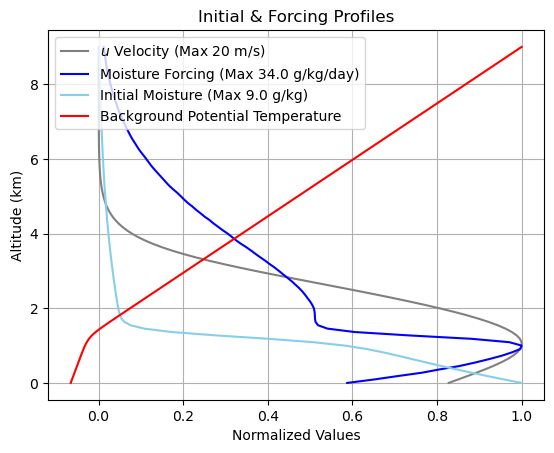

In [580]:
#def qvi(x,z):
    #qvtil = 0.018/f0(x,z)**(CpRd)*np.exp(-LL/Rv * (1/(f0(x,z)*pot0(x,z)) -1/theta0))
    #return qvtil

#def pot0(x, z):
    #return theta0+B*z

def pot0(x, z):
    theta_surf = 288.0  
    gamma_mbl = 0.001   
    gamma_trop = 0.004  
    z_inv = 1250.0       
    width = 200.0       
    smooth_step = width * np.log(np.cosh((z - z_inv) / width)) - width * np.log(np.cosh(-z_inv / width))
    return theta_surf + ((gamma_mbl + gamma_trop) / 2.0) * z + ((gamma_trop - gamma_mbl) / 2.0) * smooth_step

def poti(x, z):
    poti = pot0(x, z)
    x_mask = np.zeros(poti.shape[0], dtype=bool)
    x_mask[30:-30] = True
    z_mask = z < 2000
    combined_mask = (x_mask[:, np.newaxis]) & z_mask
    noise_size = np.sum(combined_mask)
    poti[combined_mask] += np.random.uniform(low=-0.02, high=0.02, size=noise_size)
    return poti

from scipy.integrate import cumulative_trapezoid

def f0(x, z):
    # Numerically integrates the hydrostatic equation
    theta = pot0(x, z)
    integrand = -DALR / theta
    integral = cumulative_trapezoid(integrand, z, axis=-1, initial=0)
    return 1.0 + integral

def P0(x, z): #divided by p0 = 10^5
    return f0(x,z)**(CpRd)

def rho0(x, z):
    return p0/(Rd*pot0(x,z))*f0(x,z)**(CpRd-1)

def qvs(x, z):
    return qvso/f0(x,z)**(CpRd)*np.exp(-LL/Rv * (1/(f0(x,z)*pot0(x,z)) -1/theta0))

def qvi(x, z):
    qvs_initial = qvs(x, z)
    RH = 0.10 + 0.85 * 0.5 * (1 - np.tanh((z - 1250) / 200.0))
    return qvs_initial * RH

def moistrate(x, z):
    moist_bg = (PchipInterpolator(zmoist, moistz)(z/1000)) / (86400 * 1000)
    x_coast = 100000
    ramp = 10000
    xmask = 0.5 * (1 + np.tanh((x_coast - x) / ramp))
    z_inv = 1250.0   
    z_sharp = 160.0 
    zmask = 0.5 * (1 - np.tanh((z - z_inv) / z_sharp))
    marine_mag = 20 / (86400 * 1000) #g/kg day -> #g/g s
    marine_forcing = marine_mag * xmask * zmask
    return moist_bg + marine_forcing

def coolrate(x,z):
    coolrat =  (PchipInterpolator(zcool, coolz)(z/1000))/(86400)
    return coolrat

def u_init(x, z):
    U_base = 12.0  
    base_wind = U_base * 0.5 * (1 - np.tanh((z - 3000.0) / 1000.0))
    U_jet = 8.0 
    z_jet = 1100
    h_jet = 1000
    jet_core = U_jet * np.exp(-((z - z_jet)**2) / (2 * h_jet**2))
    return base_wind + jet_core

def mountainmask(x, z):
    x_mount = 130000.0
    sigma = 15000.0  
    h = 1500.0 * np.exp(-((x - x_mount)**2) / (2.0 * sigma**2))
    z_sigma = 100.0 + 100.0 * (h / 1250.0) 
    vertical_mask = 0.5 * (1 - np.tanh((z - h) / z_sigma))
    horizontal_envelope = np.tanh(h / 50.0) 
    raw_mask = vertical_mask * horizontal_envelope
    return np.where(raw_mask > 0.02, raw_mask, 0.0)

def boundarymask(x, z):
    w = 15000  
    Lx = 256000
    leftmask = np.where(x < w, 0.5 * (1 + np.cos(np.pi * x / w)), 0.0)
    rightmask = np.where(x > (Lx - w), 0.5 * (1 + np.cos(np.pi*(Lx - x)/w)), 0.0)
    topmask = 0.5 * (1 + np.tanh((z-9000)/1000))
    return 1 - (1-leftmask)*(1-rightmask)*(1-topmask)

def mountainshape(x):
    x_mount = 130000
    sigma = 15000.0  
    h = 1500.0 * np.exp(-((x - x_mount)**2) / (2.0 * sigma**2))
    return h

ztestil = np.linspace(0, 9000, 100)

plt.plot(u_init(0,ztestil)/np.max(u_init(0,ztestil)),ztestil/1000, color='grey', label='$u$ Velocity (Max 20 m/s)')
plt.plot(moistrate(0,ztestil)/np.max(moistrate(0,ztestil)),ztestil/1000, color='blue', label=f'Moisture Forcing (Max {np.max(moistrate(0,ztestil))*1000*86400:.1f} g/kg/day)')
plt.plot(qvi(0,ztestil)/np.max(qvi(0,ztestil)), ztestil/1000, color='skyblue', label=f'Initial Moisture (Max {np.max(qvi(0,ztestil))*1000:.1f} g/kg)')
plt.plot((pot0(0,ztestil)-290)/(np.max(pot0(0,ztestil))-290), ztestil/1000, color='red', label=f'Background Potential Temperature')
plt.legend(loc='upper left')
plt.xlabel('Normalized Values')
plt.ylabel('Altitude (km)')
plt.title('Initial & Forcing Profiles')
plt.grid()
plt.savefig('Mount_Profils.png', dpi=200)

xtestil = np.linspace(0,256000, 100)

In [558]:
T = 80000 #a lot of times
s = 40

for i in range(0,1):
    n_t, t_s[i], cons_potr[i], cons_pote[i], cons_pot[i], cons_qt[i], cons_qr[i], cons_qv[i], cons_K[i],cons_B[i], cons_R[i], C[i], w_max[i], temp_max[i], x[i], z[i], P_s[i], pot_s[i], pot_r_s[i], u_s[i], w_s[i], qv_s[i], qr_s[i], pot0_s[i] = FARE(poti, qvi, u_init, L, grid[i], dt, T, s, pot0, f0, vis_art, gam_art, 0.01, time='AB3')
    print(f' Simulation {i+1} is complete!')

 Save 1818! Simulation 1 is complete!


## Animation

#### Temperatur Field

Simulation 1 is complete!


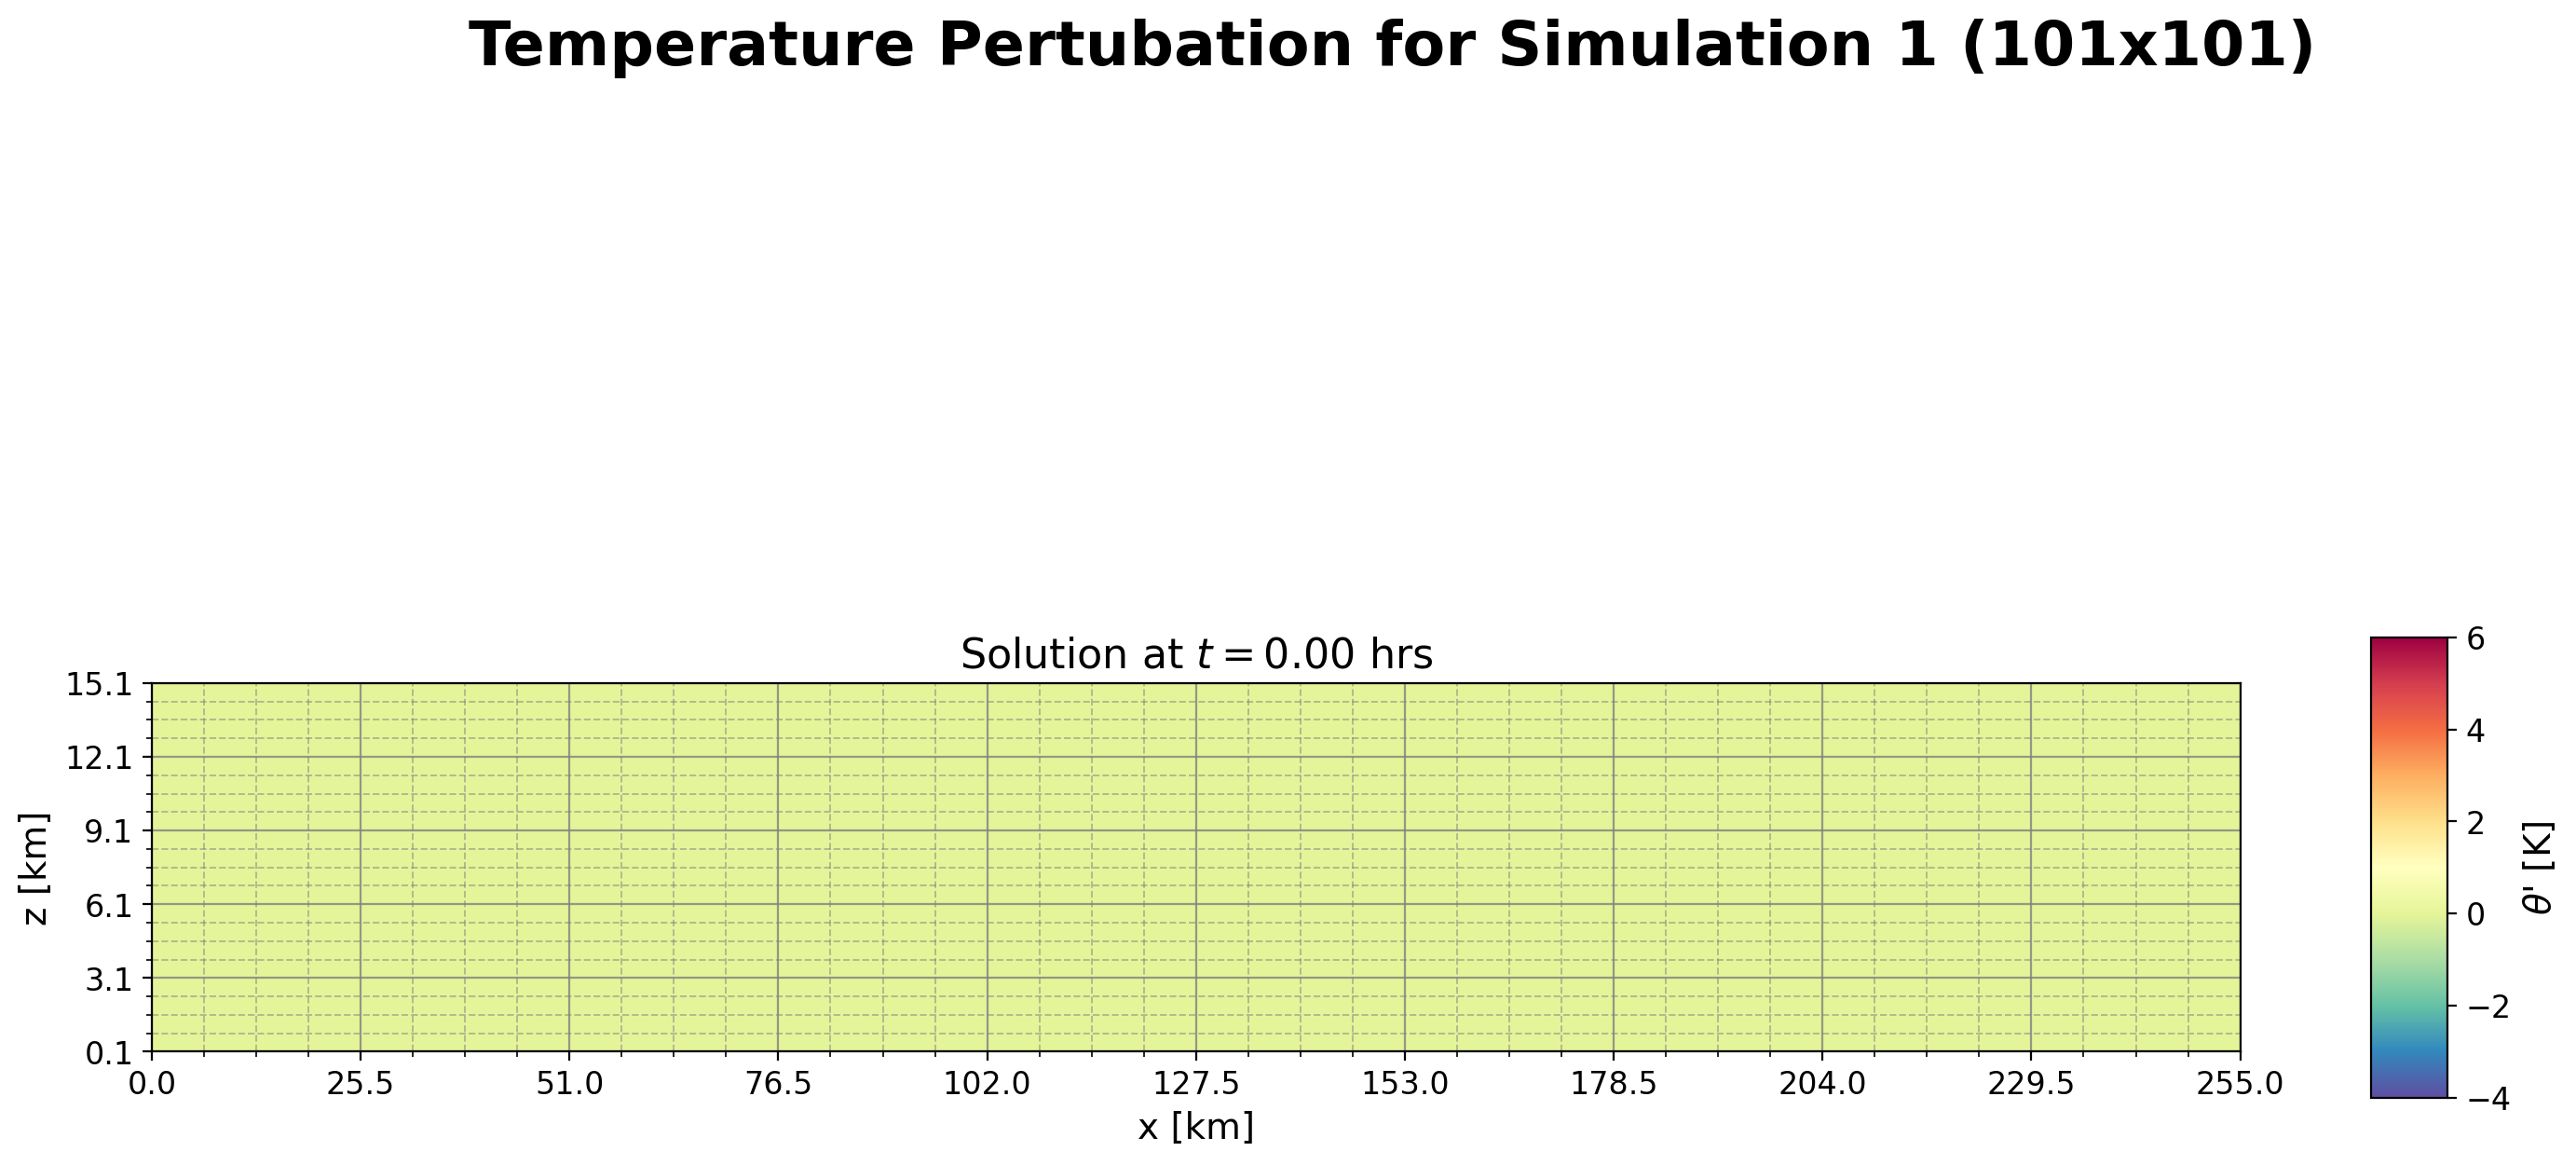

In [313]:
#prime field
vmin = -4
vmax = 6

sim = ["(101x101)", "(201x201)","(401x401)"]


for i in range(0,1):
    Quantity = pot_s[i]
    x1, y1 = x[i], z

    fig, ax = plt.subplots(figsize=(15, 9), dpi=200)

    # Filled and line contours
    cf = ax.contourf(x1, y1, Quantity[0]-pot0_s[i], levels=np.linspace(vmin, vmax, 25), cmap='Spectral_r', vmin=vmin, vmax=vmax, extend='both') #RdYlBu_r

    # Labels and formatting
    ax.set_title(r"Solution at $t = $"+ f"{t_s[i][0]:.3f} sec", fontsize=16, y=1)
    plt.suptitle(f'Temperature Pertubation for Simulation {i+1} '+sim[i], fontsize=24, fontweight='bold', y=0.98)
    ax.set_xlabel('x [km]', fontsize=12)
    ax.set_ylabel('z [km]', fontsize=12)
    ax.tick_params(labelsize=12)
    ax.set_aspect(3, anchor='C')

    ax.minorticks_on()
    ax.set_xticks(np.linspace(x1.min(), x1.max(), 11))
    ax.set_xticklabels(f'{vals:.1f}' for vals in np.linspace(x1.min(), x1.max(), 11)/1000)
    ax.set_yticks(np.linspace(y1.min(), y1.max(), 6))
    ax.set_yticklabels(f'{vals:.1f}' for vals in np.linspace(y1.min(), y1.max(), 6)/1000)
    ax.set_xticks(np.linspace(x1.min(), x1.max(), 41), minor=True)
    ax.set_yticks(np.linspace(y1.min(), y1.max(), 21), minor=True)
    ax.grid(True, which='major', linestyle='-', color='grey', linewidth=0.8, alpha=0.8)
    ax.grid(True, which='minor', linestyle='--', color='grey', linewidth=0.7, alpha=0.5)
     #    fig.subplots_adjust(left=0.07, right=0.93, top=0.88, bottom=0.1)


    # Colorbar
    norm = colors.Normalize(vmin=vmin, vmax=vmax)
    mappable = cm.ScalarMappable(norm=norm, cmap='Spectral_r')
    mappable.set_array([])
    cbar = fig.colorbar(mappable, ax=ax, shrink=0.3, aspect=6)
    cbar.set_label(r"$\theta$' [K]", fontsize=14)
    cbar.ax.tick_params(labelsize=12)
    fig.tight_layout()

    def update(n):
        ax.clear()

        # Filled and black line contours
        cf = ax.contourf(x1, y1, Quantity[n]-pot0_s[i], levels=np.linspace(vmin, vmax, 25), cmap='Spectral_r', vmin=vmin, vmax=vmax, extend='both')

        # Title and labels
        ax.set_title(r"Solution at $t = $"+ f"{t_s[i][n]/3600:.2f} hrs", fontsize=16, y=1)
        ax.set_xlabel('x [km]', fontsize=14)
        ax.set_ylabel('z [km]', fontsize=14)
        ax.tick_params(labelsize=12)
        ax.set_aspect(3, anchor='C')

        # Ticks and grid
        ax.minorticks_on()
        ax.set_xticks(np.linspace(x1.min(), x1.max(), 11))
        ax.set_xticklabels(f'{vals:.1f}' for vals in np.linspace(x1.min(), x1.max(), 11)/1000)
        ax.set_yticks(np.linspace(y1.min(), y1.max(), 6))
        ax.set_yticklabels(f'{vals:.1f}' for vals in np.linspace(y1.min(), y1.max(), 6)/1000)
        ax.set_xticks(np.linspace(x1.min(), x1.max(), 41), minor=True)
        ax.set_yticks(np.linspace(y1.min(), y1.max(), 21), minor=True)
        ax.grid(True, which='major', linestyle='-', color='grey', linewidth=0.8, alpha=0.8)
        ax.grid(True, which='minor', linestyle='--', color='grey', linewidth=0.7, alpha=0.5)

        return cf

    # Create and save animation
    ani = FuncAnimation(fig, update, frames=range(len(Quantity)), interval=50, blit=False) #len(Quantity)

    filename = f"Sim_{i+1}_Temperature.mp4"
    ani.save(filename, writer='ffmpeg', fps=20)
    print(f'Simulation {i+1} is complete!')

    # Display in notebook
    display(HTML(f"""<video width="720" height="480" controls><source src="{Path(filename).as_posix()}" type="video/mp4">
      Your browser does not support the video tag.</video>"""))

Simulation 1 is complete!


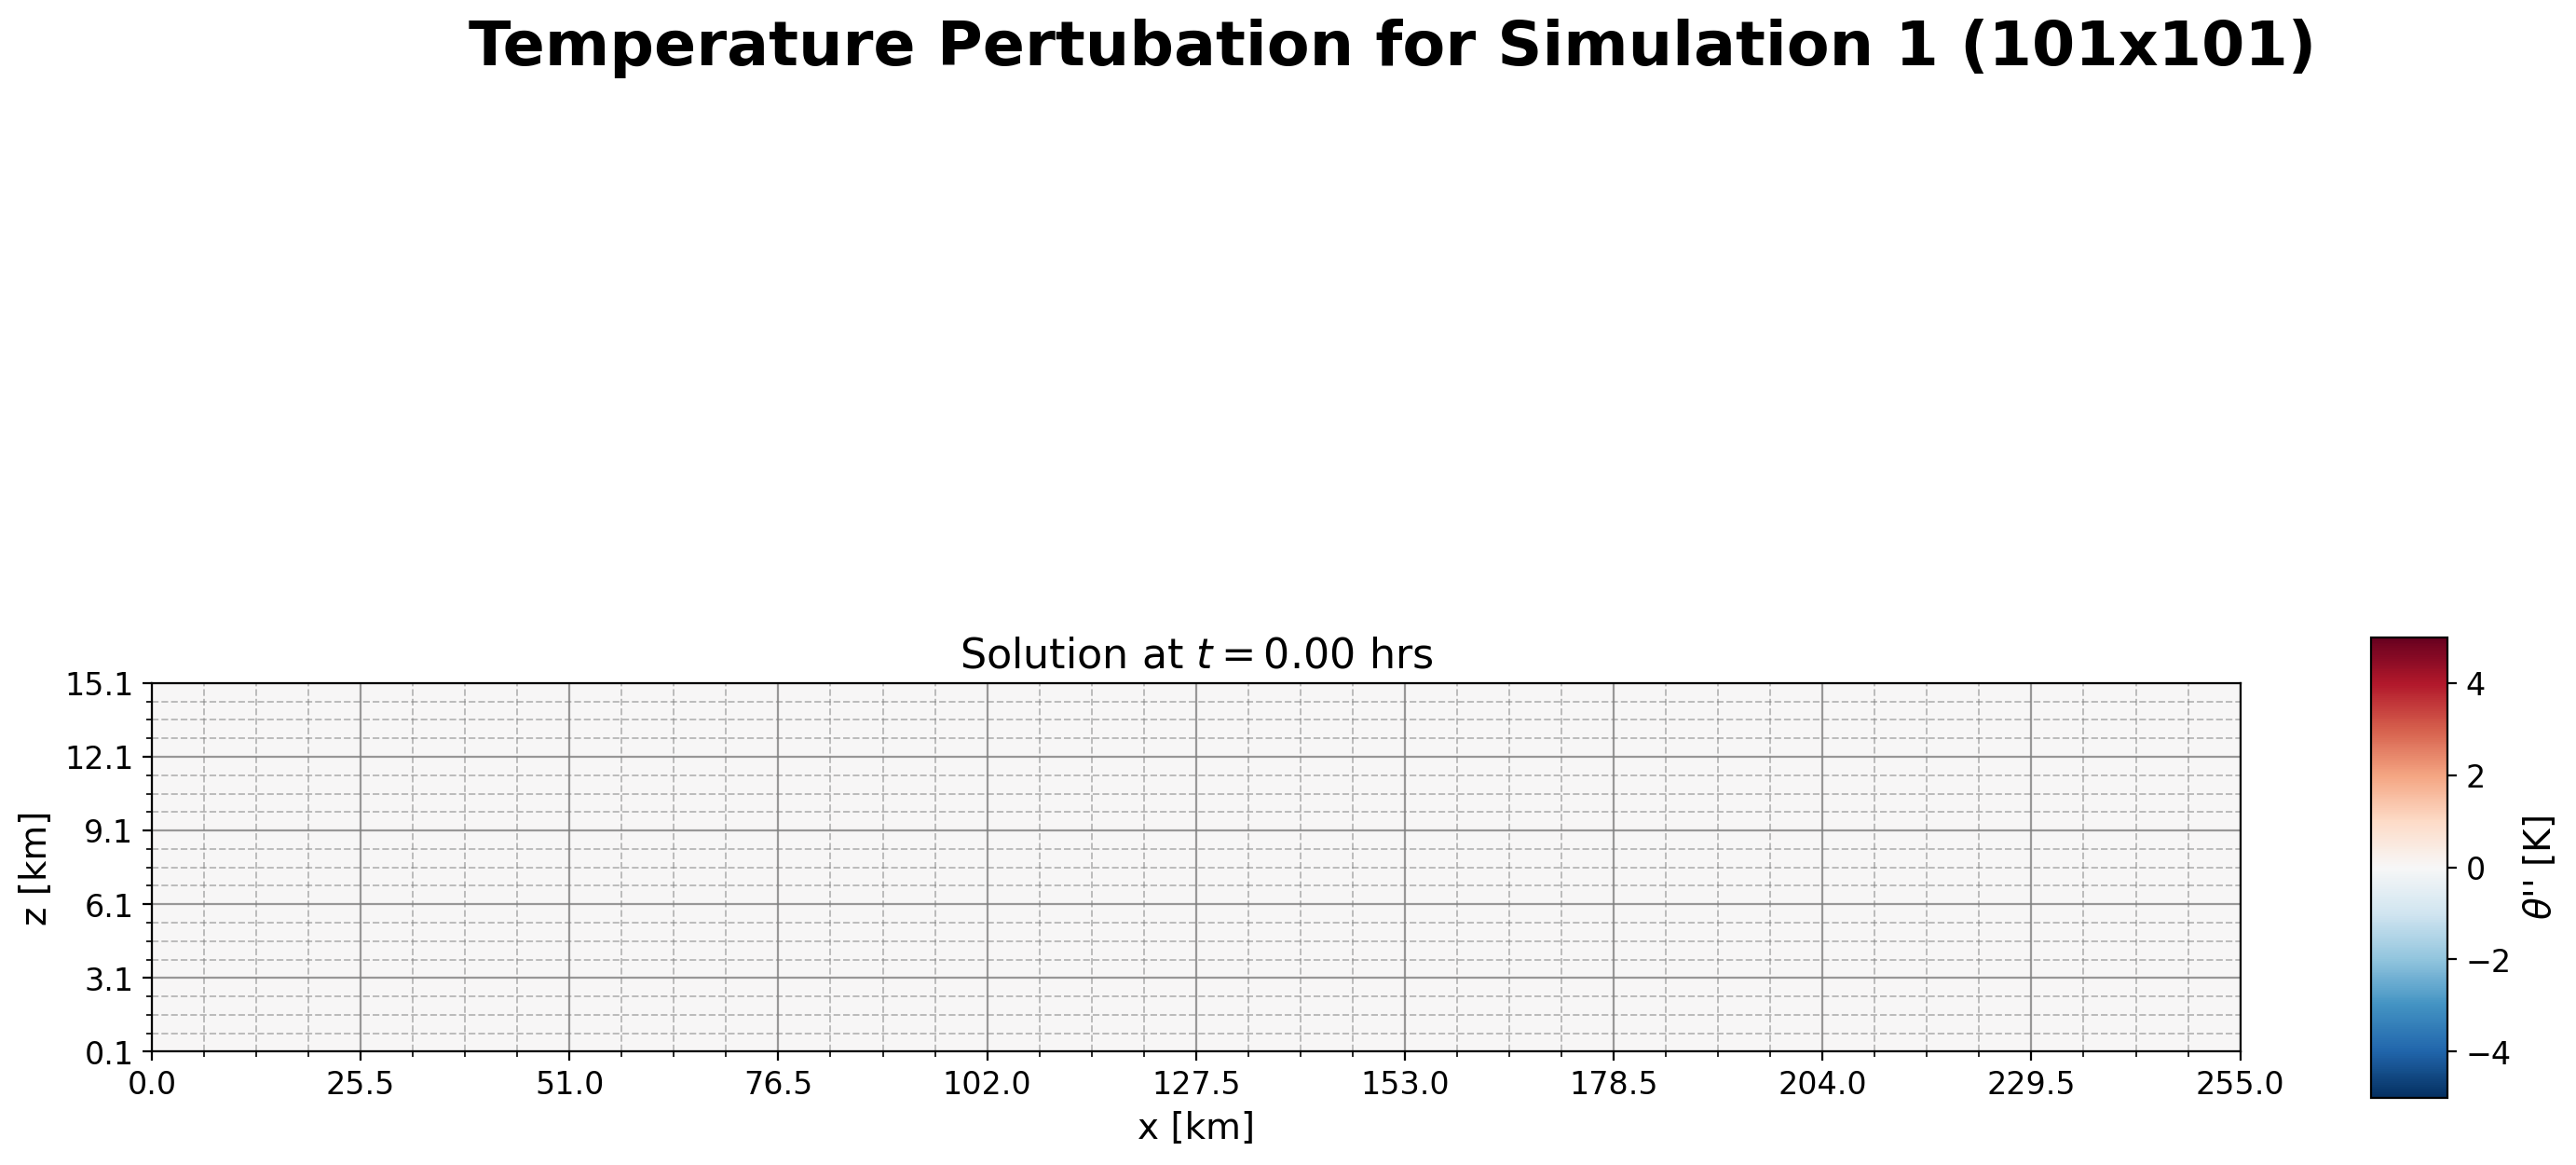

In [199]:
#prime prime field

coolingprof = coolrate(xtest, ztest)[:,1:-1]/2 #divided by two to account for the doubled length

vmin = -5
vmax = 5

sim = ["(101x101)", "(201x201)","(401x401)"]
 

for i in range(0,1):
    Quantity = pot_s[i]
    x1, y1 = x[i], z[i]

    fig, ax = plt.subplots(figsize=(15, 9), dpi=200)

    # Filled and line contours
    cf = ax.contourf(x1, y1, Quantity[0]-pot0_s[i], levels=np.linspace(vmin, vmax, 20), cmap='RdBu_r', vmin=vmin, vmax=vmax, extend='both') #RdYlBu_r

    # Labels and formatting
    ax.set_title(r"Solution at $t = $"+ f"{t_s[i][0]:.3f} sec", fontsize=16, y=1)
    plt.suptitle(f'Temperature Pertubation for Simulation {i+1} '+sim[i], fontsize=24, fontweight='bold', y=0.98)
    ax.set_xlabel('x [km]', fontsize=12)
    ax.set_ylabel('z [km]', fontsize=12)
    ax.tick_params(labelsize=12)
    ax.set_aspect(3, anchor='C')

    ax.minorticks_on()
    ax.set_xticks(np.linspace(x1.min(), x1.max(), 11))
    ax.set_xticklabels(f'{vals:.1f}' for vals in np.linspace(x1.min(), x1.max(), 11)/1000)
    ax.set_yticks(np.linspace(y1.min(), y1.max(), 6))
    ax.set_yticklabels(f'{vals:.1f}' for vals in np.linspace(y1.min(), y1.max(), 6)/1000)
    ax.set_xticks(np.linspace(x1.min(), x1.max(), 41), minor=True)
    ax.set_yticks(np.linspace(y1.min(), y1.max(), 21), minor=True)
    ax.grid(True, which='major', linestyle='-', color='grey', linewidth=0.8, alpha=0.8)
    ax.grid(True, which='minor', linestyle='--', color='grey', linewidth=0.7, alpha=0.5)
     #    fig.subplots_adjust(left=0.07, right=0.93, top=0.88, bottom=0.1)


    # Colorbar
    norm = colors.Normalize(vmin=vmin, vmax=vmax)
    mappable = cm.ScalarMappable(norm=norm, cmap='RdBu_r')
    mappable.set_array([])
    cbar = fig.colorbar(mappable, ax=ax, shrink=0.3, aspect=6)
    cbar.set_label(r"$\theta$'' [K]", fontsize=14)
    cbar.ax.tick_params(labelsize=12)
    fig.tight_layout()

    def update(n):
        ax.clear()

        # Filled and black line contours
        cf = ax.contourf(x1, y1, Quantity[n]-pot0_s[i]-coolingprof*n*s*dt, levels=np.linspace(vmin, vmax, 40), cmap='RdBu_r', vmin=vmin, vmax=vmax, extend='both')

        # Title and labels
        ax.set_title(r"Solution at $t = $"+ f"{t_s[i][n]/3600:.2f} hrs", fontsize=16, y=1)
        ax.set_xlabel('x [km]', fontsize=14)
        ax.set_ylabel('z [km]', fontsize=14)
        ax.tick_params(labelsize=12)
        ax.set_aspect(3, anchor='C')

        # Ticks and grid
        ax.minorticks_on()
        ax.set_xticks(np.linspace(x1.min(), x1.max(), 11))
        ax.set_xticklabels(f'{vals:.1f}' for vals in np.linspace(x1.min(), x1.max(), 11)/1000)
        ax.set_yticks(np.linspace(y1.min(), y1.max(), 6))
        ax.set_yticklabels(f'{vals:.1f}' for vals in np.linspace(y1.min(), y1.max(), 6)/1000)
        ax.set_xticks(np.linspace(x1.min(), x1.max(), 41), minor=True)
        ax.set_yticks(np.linspace(y1.min(), y1.max(), 21), minor=True)
        ax.grid(True, which='major', linestyle='-', color='grey', linewidth=0.8, alpha=0.8)
        ax.grid(True, which='minor', linestyle='--', color='grey', linewidth=0.7, alpha=0.5)

        return cf

    # Create and save animation
    ani = FuncAnimation(fig, update, frames=range(int(len(Quantity))), interval=50, blit=False) #

    filename = f"Sim_{i+1}_TemperaturePrimePrime.mp4"
    ani.save(filename, writer='ffmpeg', fps=20)
    print(f'Simulation {i+1} is complete!')

    # Display in notebook
    display(HTML(f"""<video width="720" height="480" controls><source src="{Path(filename).as_posix()}" type="video/mp4">
      Your browser does not support the video tag.</video>"""))

Simulation 1 is complete!


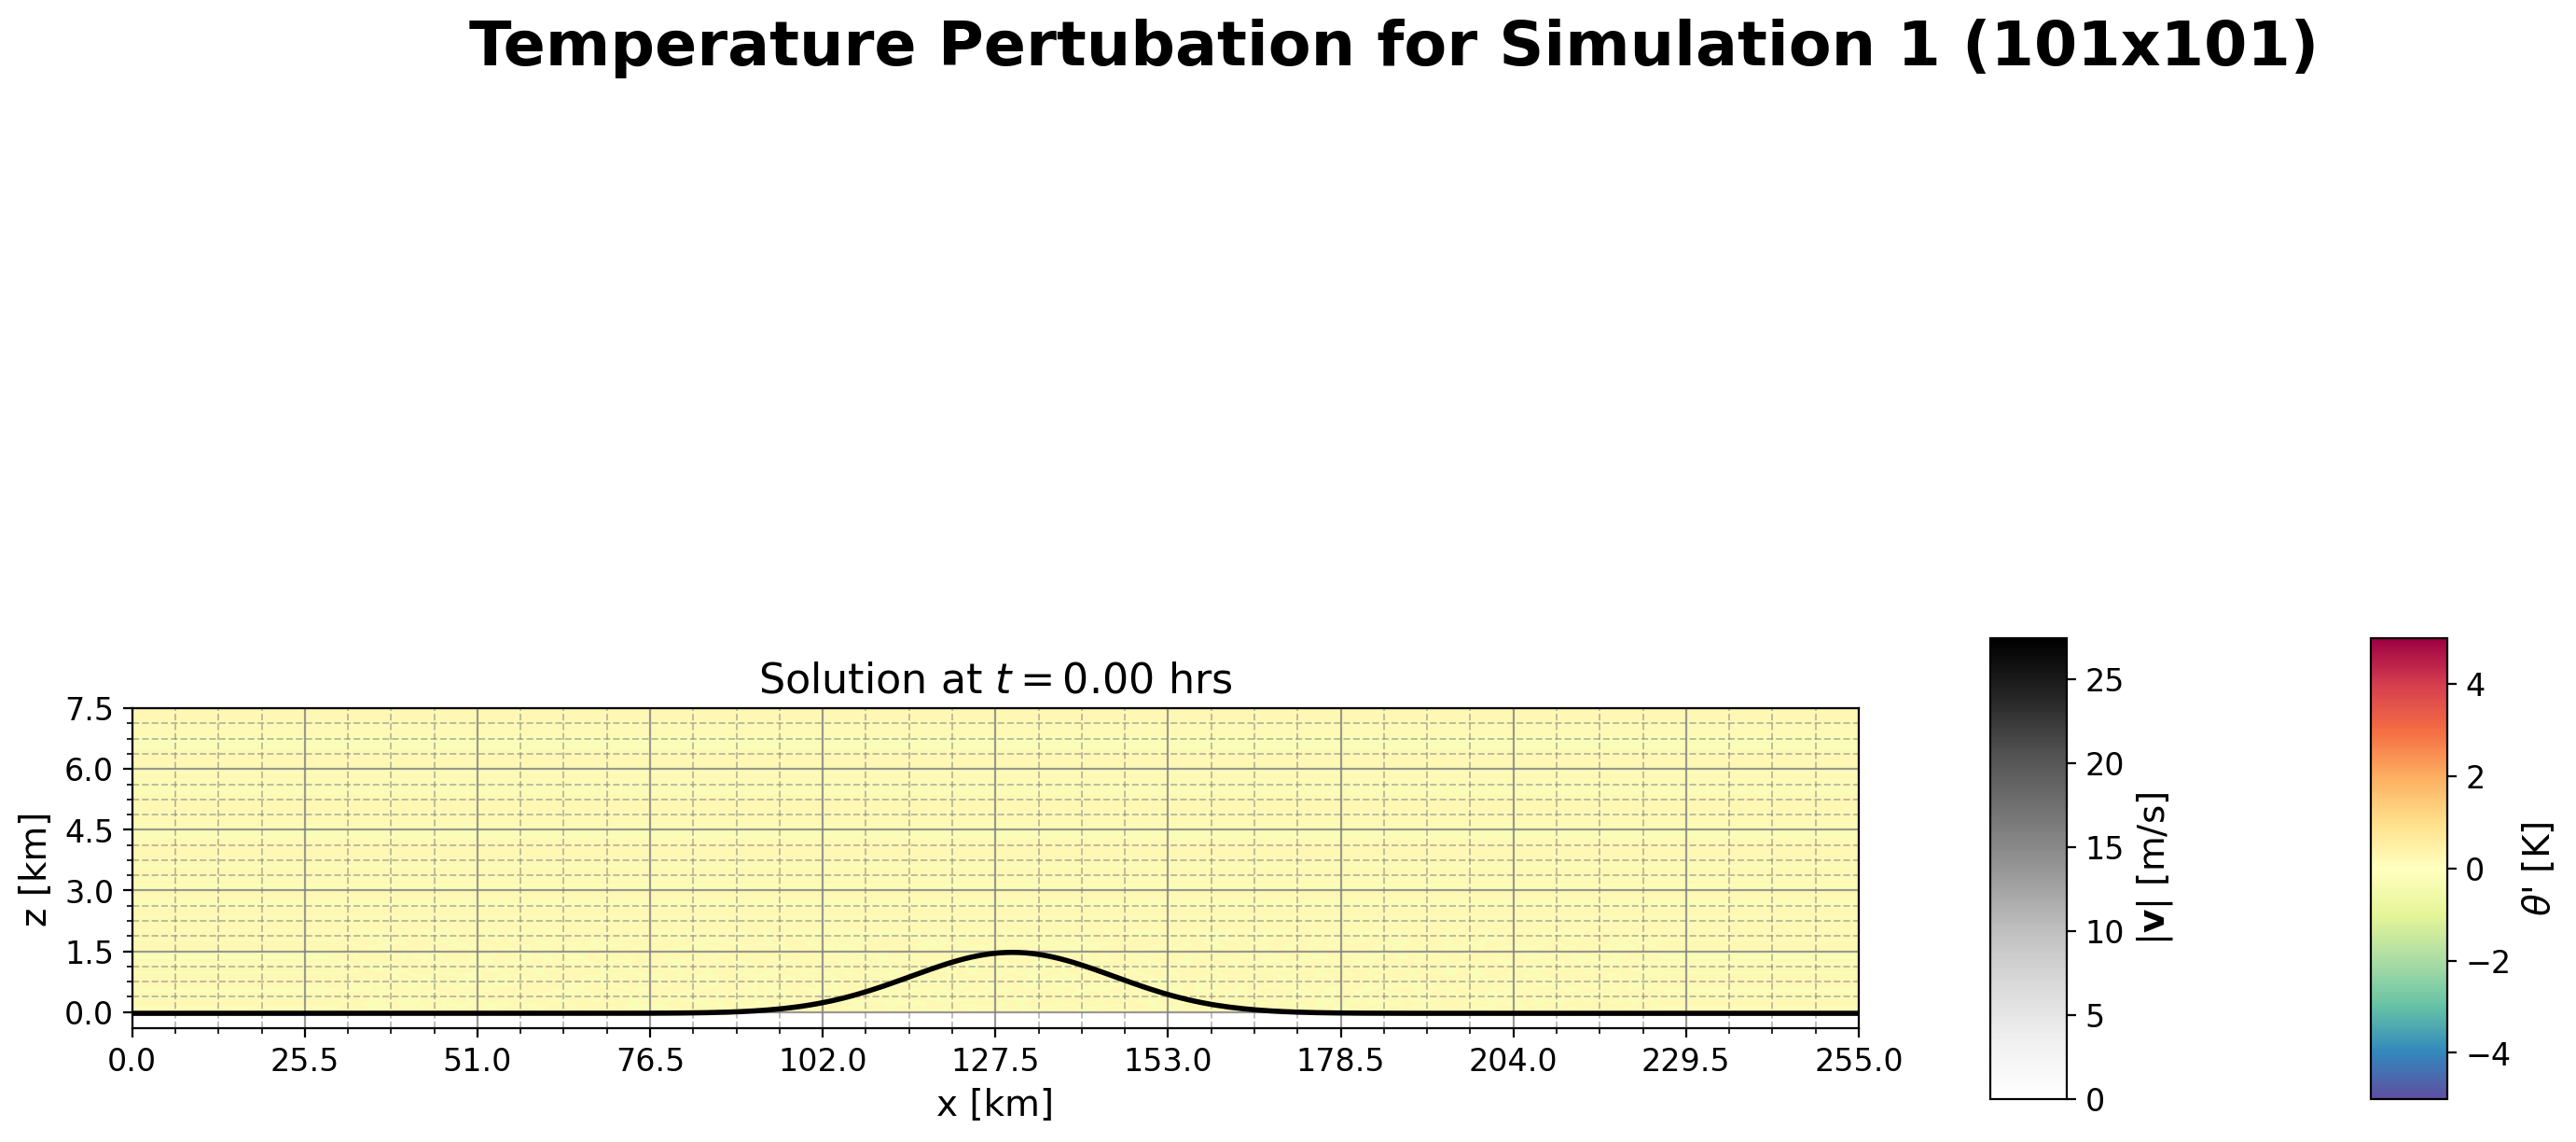

In [562]:
#shallow final

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.cm as cm
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display
from pathlib import Path

#prime field
vmin = -5
vmax = 5
z_cut = 125
sim = ["(101x101)", "(201x201)","(401x401)"]

for i in range(0,1):
    Quantity = pot_s[i][:, :, :z_cut]
    x1, y1 = x[i][:, :z_cut], z[i][:, :z_cut]

    x_line = x1[:,0]
    h = mountainshape(x_line)
        
    # --- Interpolate staggered w to u nodes (cell centers) ---
    # w_s[i] shape is (time, Nx, Nz), representing the top faces.
    # We prepend the chopped 0th boundary node (bottom wall, w=0).
    w_padded = np.zeros((w_s[i][:,:, :z_cut].shape[0], w_s[i][:,:, :z_cut].shape[1], w_s[i][:,:, :z_cut].shape[2] + 1))
    w_padded[:, :, 1:] = w_s[i][:,:, :z_cut]
    w_interp = (w_padded[:, :, :-1] + w_padded[:, :, 1:]) / 2.0
    # ---------------------------------------------------------

    # ---------------- QUIVER SETUP ----------------
    # Calculate global max speed across entire simulation for stable color/scaling
    max_spd = np.max(np.sqrt((u_s[i][:2401,:, :z_cut]-np.mean(u_s[i][:2401,:, :z_cut],axis=1, keepdims=True))**2 + w_interp[:2401]**2)) * 0.8
    norm_spd = colors.Normalize(vmin=0, vmax=max_spd)
    
    # Dynamically determine subsampling for a wide aspect ratio
    # Targets ~35 arrows horizontally and ~12 arrows vertically
    skip_x = max(1, x1.shape[0] // 35)
    skip_z = max(1, x1.shape[1] // 10)
    
    # Tuning parameter for arrow length. DECREASE this number to make arrows longer.
    # Adjust this until the max speed arrow just touches the next grid point.
    q_scale = max_spd * 15 
    # ----------------------------------------------

    fig, ax = plt.subplots(figsize=(15, 9), dpi=200)

    # Filled and line contours (Temperature)
    cf = ax.contourf(x1, y1, Quantity[0]-np.mean(Quantity[0], axis=0, keepdims=True), levels=np.linspace(vmin, vmax, 25), cmap='Spectral_r', vmin=vmin, vmax=vmax, extend='both') 
    ax.plot(x_line, h, zorder=20, color='black', linewidth=2)

    u_c = u_s[i][0, :, :z_cut]-np.mean(u_s[i][0, :, :z_cut],axis=0, keepdims=True)
    w_c = w_interp[0]
    spd = np.sqrt(u_c**2 + w_c**2)
    
    # --- Cap max arrow length to prevent overlapping ---
    spd_limit = max_spd * 0.4  # Cap visual length at 75% of max speed (tune as needed)
    spd_capped = np.minimum(spd, spd_limit)
    u_plot = (u_c / (spd + 1e-12)) * spd_capped
    w_plot = (w_c / (spd + 1e-12)) * spd_capped
    
    Vel = ax.quiver(x1[::skip_x, ::skip_z], y1[::skip_x, ::skip_z], 
                    u_plot[::skip_x, ::skip_z], w_plot[::skip_x, ::skip_z], 
                    spd[::skip_x, ::skip_z], # Still use raw spd for true color!
                    cmap='Greys', norm=norm_spd, scale=q_scale, zorder=10,
                    width=0.002, headwidth=4, headlength=4, headaxislength=3, minlength=0)

    # Labels and formatting
    ax.set_title(r"Solution at $t = $"+ f"{t_s[i][0]:.3f} sec", fontsize=16, y=1)
    plt.suptitle(f'Temperature Pertubation for Simulation {i+1} '+sim[i], fontsize=24, fontweight='bold', y=0.98)
    ax.set_xlabel('x [km]', fontsize=12)
    ax.set_ylabel('z [km]', fontsize=12)
    ax.tick_params(labelsize=12)
    ax.set_aspect(6, anchor='C')

    ax.minorticks_on()
    ax.set_xticks(np.linspace(x1.min(), x1.max(), 11))
    ax.set_xticklabels(f'{vals:.1f}' for vals in np.linspace(x1.min(), x1.max(), 11)/1000)
    ax.set_yticks(np.linspace(y1.min(), y1.max(), 6))
    ax.set_yticklabels(f'{vals:.1f}' for vals in np.linspace(y1.min(), y1.max(), 6)/1000)
    ax.set_xticks(np.linspace(x1.min(), x1.max(), 41), minor=True)
    ax.set_yticks(np.linspace(y1.min(), y1.max(), 21), minor=True)
    ax.grid(True, which='major', linestyle='-', color='grey', linewidth=0.8, alpha=0.8)
    ax.grid(True, which='minor', linestyle='--', color='grey', linewidth=0.7, alpha=0.5)

    # Temperature Colorbar
    norm_t = colors.Normalize(vmin=vmin, vmax=vmax)
    mappable_t = cm.ScalarMappable(norm=norm_t, cmap='Spectral_r')
    mappable_t.set_array([])
    cbar = fig.colorbar(mappable_t, ax=ax, shrink=0.3, aspect=6, pad=0.02)
    cbar.set_label(r"$\theta$' [K]", fontsize=14)
    cbar.ax.tick_params(labelsize=12)
    
    # Velocity Colorbar
    cbar2 = fig.colorbar(Vel, ax=ax, shrink=0.3, aspect=6, pad=0.06)
    cbar2.set_label(r'$|\mathbf{v}|$ [m/s]', fontsize=14)
    cbar2.ax.tick_params(labelsize=12)
    
    fig.tight_layout()

    def update(n):
        ax.clear()

        # Filled and black line contours
        cf = ax.contourf(x1, y1, Quantity[n]-np.mean(Quantity[n], axis=0, keepdims=True), levels=np.linspace(vmin, vmax, 25), cmap='Spectral_r', vmin=vmin, vmax=vmax, extend='both')
        ax.plot(x_line, h, zorder=20, color='black', linewidth=2)

        # Quiver (Velocity) - Must be re-drawn each frame because ax.clear() removes it
        u_c = u_s[i][n, :, :z_cut]-np.mean(u_s[i][n, :, :z_cut],axis=0, keepdims=True)
        w_c = w_interp[n]
        spd = np.sqrt(u_c**2 + w_c**2)
        
        # --- Cap max arrow length ---
        spd_capped = np.minimum(spd, spd_limit)
        u_plot = (u_c / (spd + 1e-12)) * spd_capped
        w_plot = (w_c / (spd + 1e-12)) * spd_capped
        
        Vel = ax.quiver(x1[::skip_x, ::skip_z], y1[::skip_x, ::skip_z], 
                        u_plot[::skip_x, ::skip_z], w_plot[::skip_x, ::skip_z], 
                        spd[::skip_x, ::skip_z], 
                        cmap='Greys', norm=norm_spd, scale=q_scale, zorder=10,
                        width=0.002, headwidth=4, headlength=4, headaxislength=3, minlength=0)

        # Title and labels
        ax.set_title(r"Solution at $t = $"+ f"{t_s[i][n]/3600:.2f} hrs", fontsize=16, y=1)
        ax.set_xlabel('x [km]', fontsize=14)
        ax.set_ylabel('z [km]', fontsize=14)
        ax.tick_params(labelsize=12)
        ax.set_aspect(6, anchor='C')

        # Ticks and grid
        ax.minorticks_on()
        ax.set_xticks(np.linspace(x1.min(), x1.max(), 11))
        ax.set_xticklabels(f'{vals:.1f}' for vals in np.linspace(x1.min(), x1.max(), 11)/1000)
        ax.set_yticks(np.linspace(y1.min(), y1.max(), 6))
        ax.set_yticklabels(f'{vals:.1f}' for vals in np.linspace(y1.min(), y1.max(), 6)/1000)
        ax.set_xticks(np.linspace(x1.min(), x1.max(), 41), minor=True)
        ax.set_yticks(np.linspace(y1.min(), y1.max(), 21), minor=True)
        ax.grid(True, which='major', linestyle='-', color='grey', linewidth=0.8, alpha=0.8)
        ax.grid(True, which='minor', linestyle='--', color='grey', linewidth=0.7, alpha=0.5)

        return cf, Vel

    # Create and save animation
    ani = FuncAnimation(fig, update, frames=range(0, 1801), interval=50, blit=False) #

    filename = f"Mount_{i+1}_Temperature.mp4"
    ani.save(filename, writer='ffmpeg', fps=20)
    print(f'Simulation {i+1} is complete!')

    # Display in notebook
    display(HTML(f"""<video width="720" height="480" controls><source src="{Path(filename).as_posix()}" type="video/mp4">
      Your browser does not support the video tag.</video>"""))

#### QR alone (as it should be)

In [332]:
from moviepy.video.io.VideoFileClip import VideoFileClip
from moviepy.video.compositing.CompositeVideoClip import CompositeVideoClip
from moviepy.video.io.ImageSequenceClip import ImageSequenceClip
from matplotlib.ticker import FuncFormatter

Simulation 1 is complete!


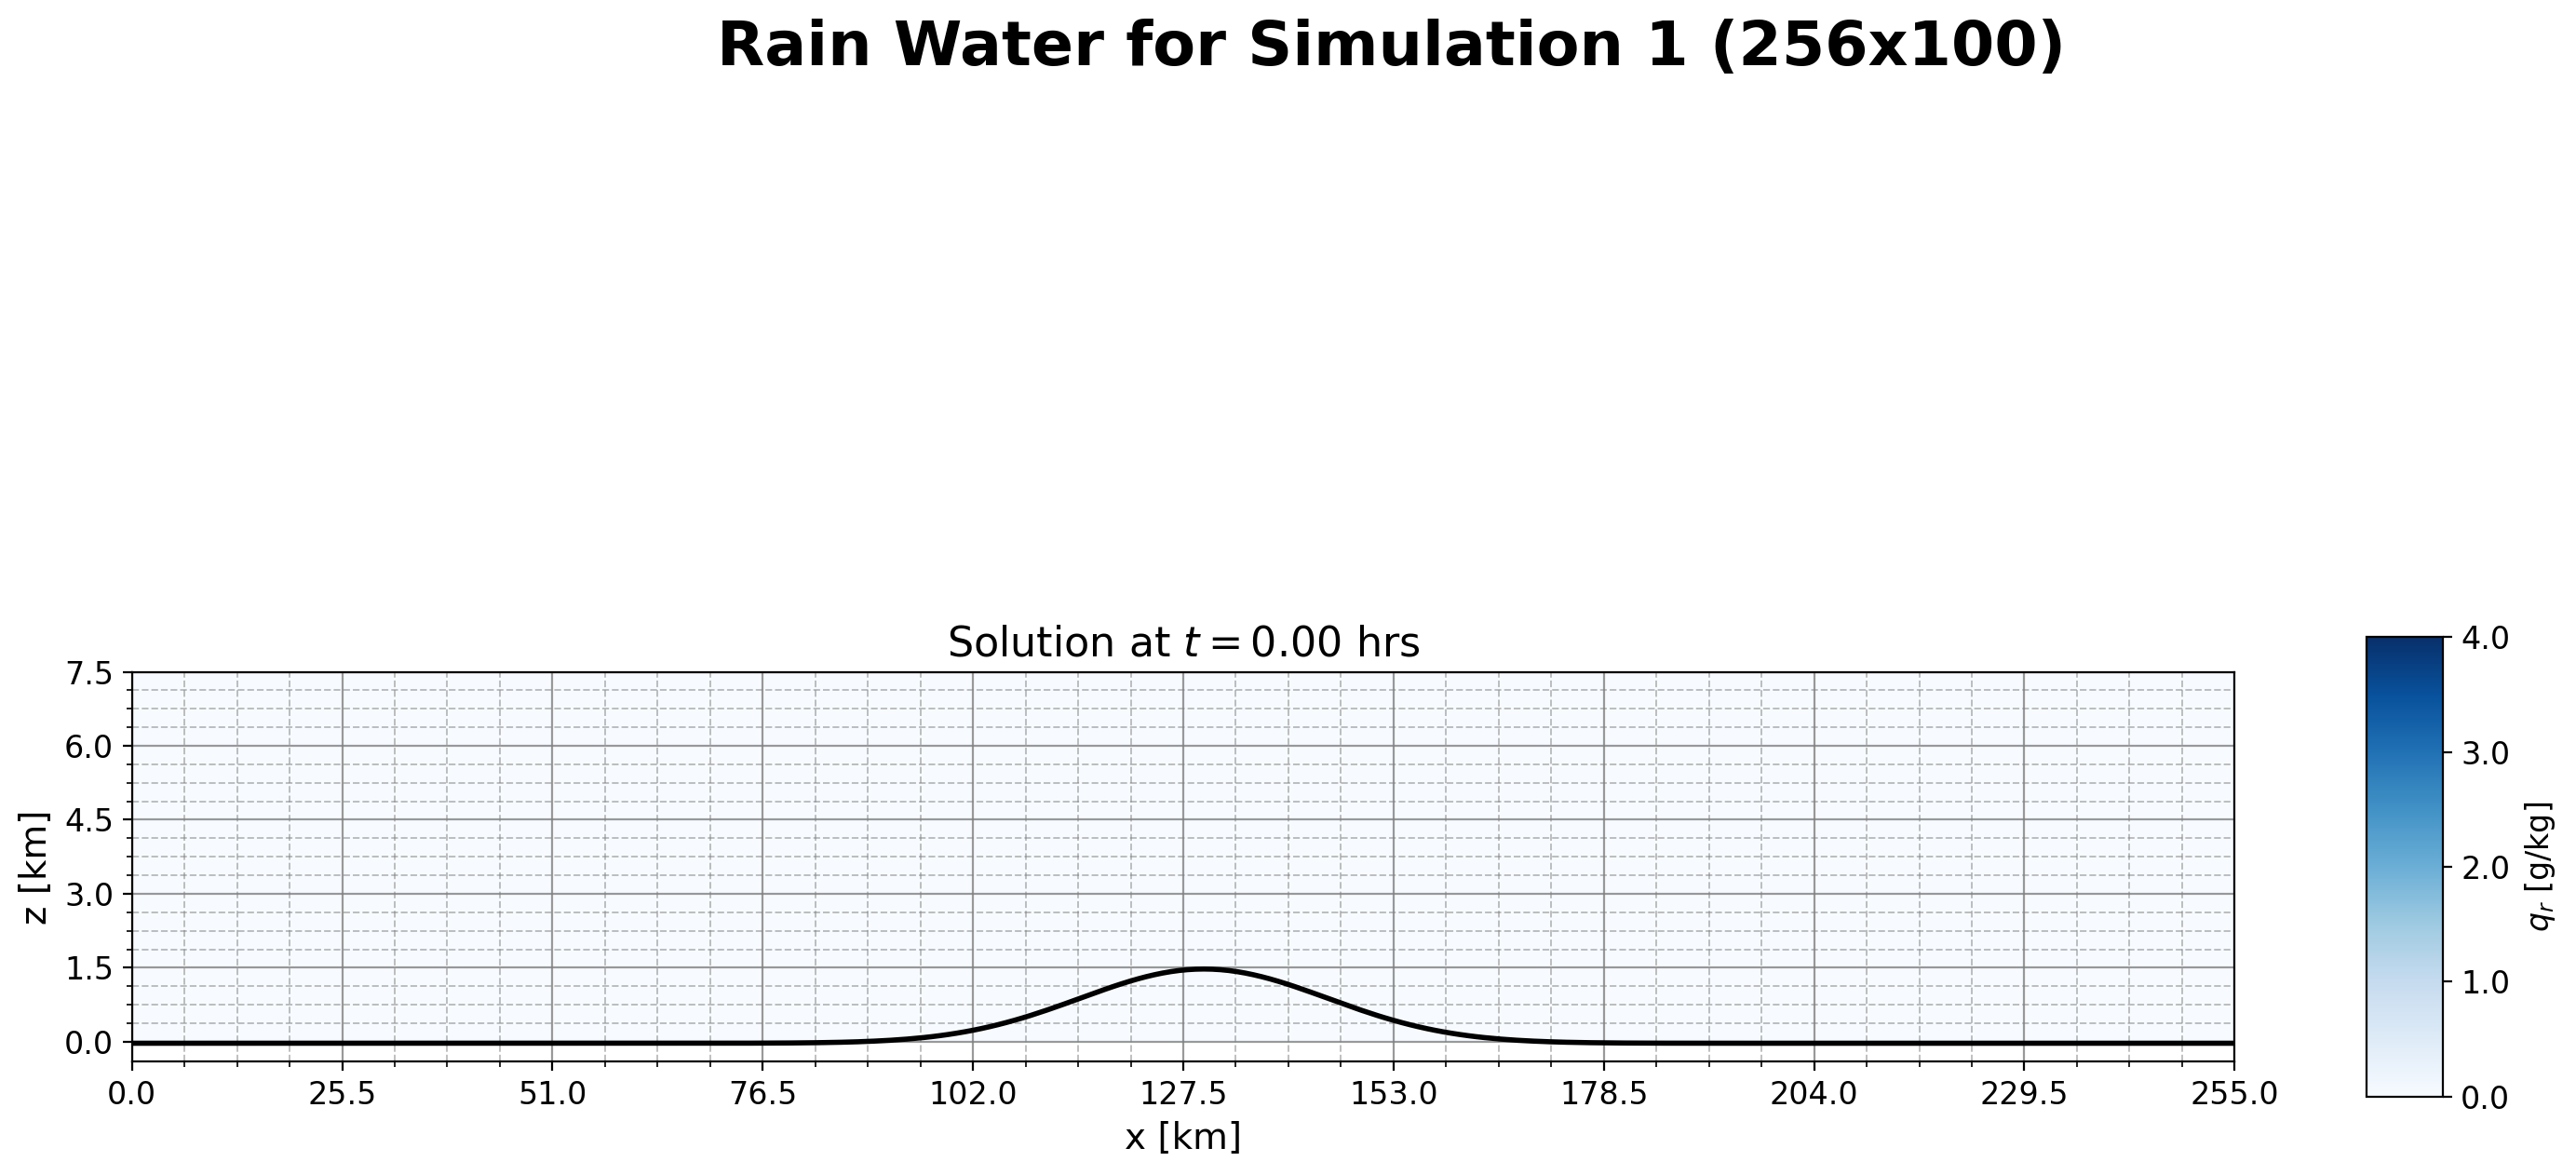

In [582]:
vmin = 0
vmax = 0.004

sim = ["(256x100)", "(201x201)","(401x401)"]

z_cut = 125


for i in range(0,1):
    Quantity = qr_s[i][:, :, :z_cut]
    x1, y1 = x[i][:, :z_cut], z[i][:, :z_cut]

    fig, ax = plt.subplots(figsize=(15, 9), dpi=200)
    ax.plot(x_line, h, zorder=20, color='black', linewidth=2)

    # Filled and line contours
    cf = ax.contourf(x1, y1, Quantity[0], levels=np.linspace(vmin, vmax, 25), cmap='Blues', vmin=vmin, vmax=vmax, extend='both') #RdYlBu_r

    # Labels and formatting
    ax.set_title(r"Solution at $t = $"+ f"{t_s[i][0]:.3f} sec", fontsize=16, y=1)
    plt.suptitle(f'Rain Water for Simulation {i+1} '+sim[i], fontsize=24, fontweight='bold', y=0.98)
    ax.set_xlabel('x [km]', fontsize=12)
    ax.set_ylabel('z [km]', fontsize=12)
    ax.tick_params(labelsize=12)
    ax.set_aspect(6, anchor='C')

    ax.minorticks_on()
    ax.set_xticks(np.linspace(x1.min(), x1.max(), 11))
    ax.set_xticklabels(f'{vals:.1f}' for vals in np.linspace(x1.min(), x1.max(), 11)/1000)
    ax.set_yticks(np.linspace(y1.min(), y1.max(), 6))
    ax.set_yticklabels(f'{vals:.1f}' for vals in np.linspace(y1.min(), y1.max(), 6)/1000)
    ax.set_xticks(np.linspace(x1.min(), x1.max(), 41), minor=True)
    ax.set_yticks(np.linspace(y1.min(), y1.max(), 21), minor=True)
    ax.grid(True, which='major', linestyle='-', color='grey', linewidth=0.8, alpha=0.8)
    ax.grid(True, which='minor', linestyle='--', color='grey', linewidth=0.7, alpha=0.5)
     #    fig.subplots_adjust(left=0.07, right=0.93, top=0.88, bottom=0.1)


    # Colorbar
    norm = colors.Normalize(vmin=vmin, vmax=vmax)
    mappable = cm.ScalarMappable(norm=norm, cmap='Blues')
    mappable.set_array([])
    cbar = fig.colorbar(mappable, ax=ax, shrink=0.3, aspect=6)
    cbar.set_label(f'$q_r$ [g/kg]', fontsize=12, labelpad=5)
    cbar.ax.tick_params(labelsize=12)
    formatter = FuncFormatter(lambda val, _: f"{val * 1000:.1f}")
    cbar.ax.yaxis.set_major_formatter(formatter)
    fig.tight_layout()

    def update(n):
        ax.clear()

        # Filled and black line contours
        cf = ax.contourf(x1, y1, Quantity[n], levels=np.linspace(vmin, vmax, 25), cmap='Blues', vmin=vmin, vmax=vmax, extend='both')
        ax.plot(x_line, h, zorder=20, color='black', linewidth=2)
        
        # Title and labels
        ax.set_title(r"Solution at $t = $"+ f"{t_s[i][n]/3600:.2f} hrs", fontsize=16, y=1)
        ax.set_xlabel('x [km]', fontsize=14)
        ax.set_ylabel('z [km]', fontsize=14)
        ax.tick_params(labelsize=12)
        ax.set_aspect(6, anchor='C')

        # Ticks and grid
        ax.minorticks_on()
        ax.set_xticks(np.linspace(x1.min(), x1.max(), 11))
        ax.set_xticklabels(f'{vals:.1f}' for vals in np.linspace(x1.min(), x1.max(), 11)/1000)
        ax.set_yticks(np.linspace(y1.min(), y1.max(), 6))
        ax.set_yticklabels(f'{vals:.1f}' for vals in np.linspace(y1.min(), y1.max(), 6)/1000)
        ax.set_xticks(np.linspace(x1.min(), x1.max(), 41), minor=True)
        ax.set_yticks(np.linspace(y1.min(), y1.max(), 21), minor=True)
        ax.grid(True, which='major', linestyle='-', color='grey', linewidth=0.8, alpha=0.8)
        ax.grid(True, which='minor', linestyle='--', color='grey', linewidth=0.7, alpha=0.5)

        return cf

    # Create and save animation
    ani = FuncAnimation(fig, update, frames=range(0,1801), interval=50, blit=False)

    filename = f"Mount_{i+1}_OceanMan.mp4"
    ani.save(filename, writer='ffmpeg', fps=20)
    print(f'Simulation {i+1} is complete!')

    # Display in notebook
    display(HTML(f"""<video width="720" height="480" controls><source src="{Path(filename).as_posix()}" type="video/mp4">
      Your browser does not support the video tag.</video>"""))

Simulation 1 is complete!


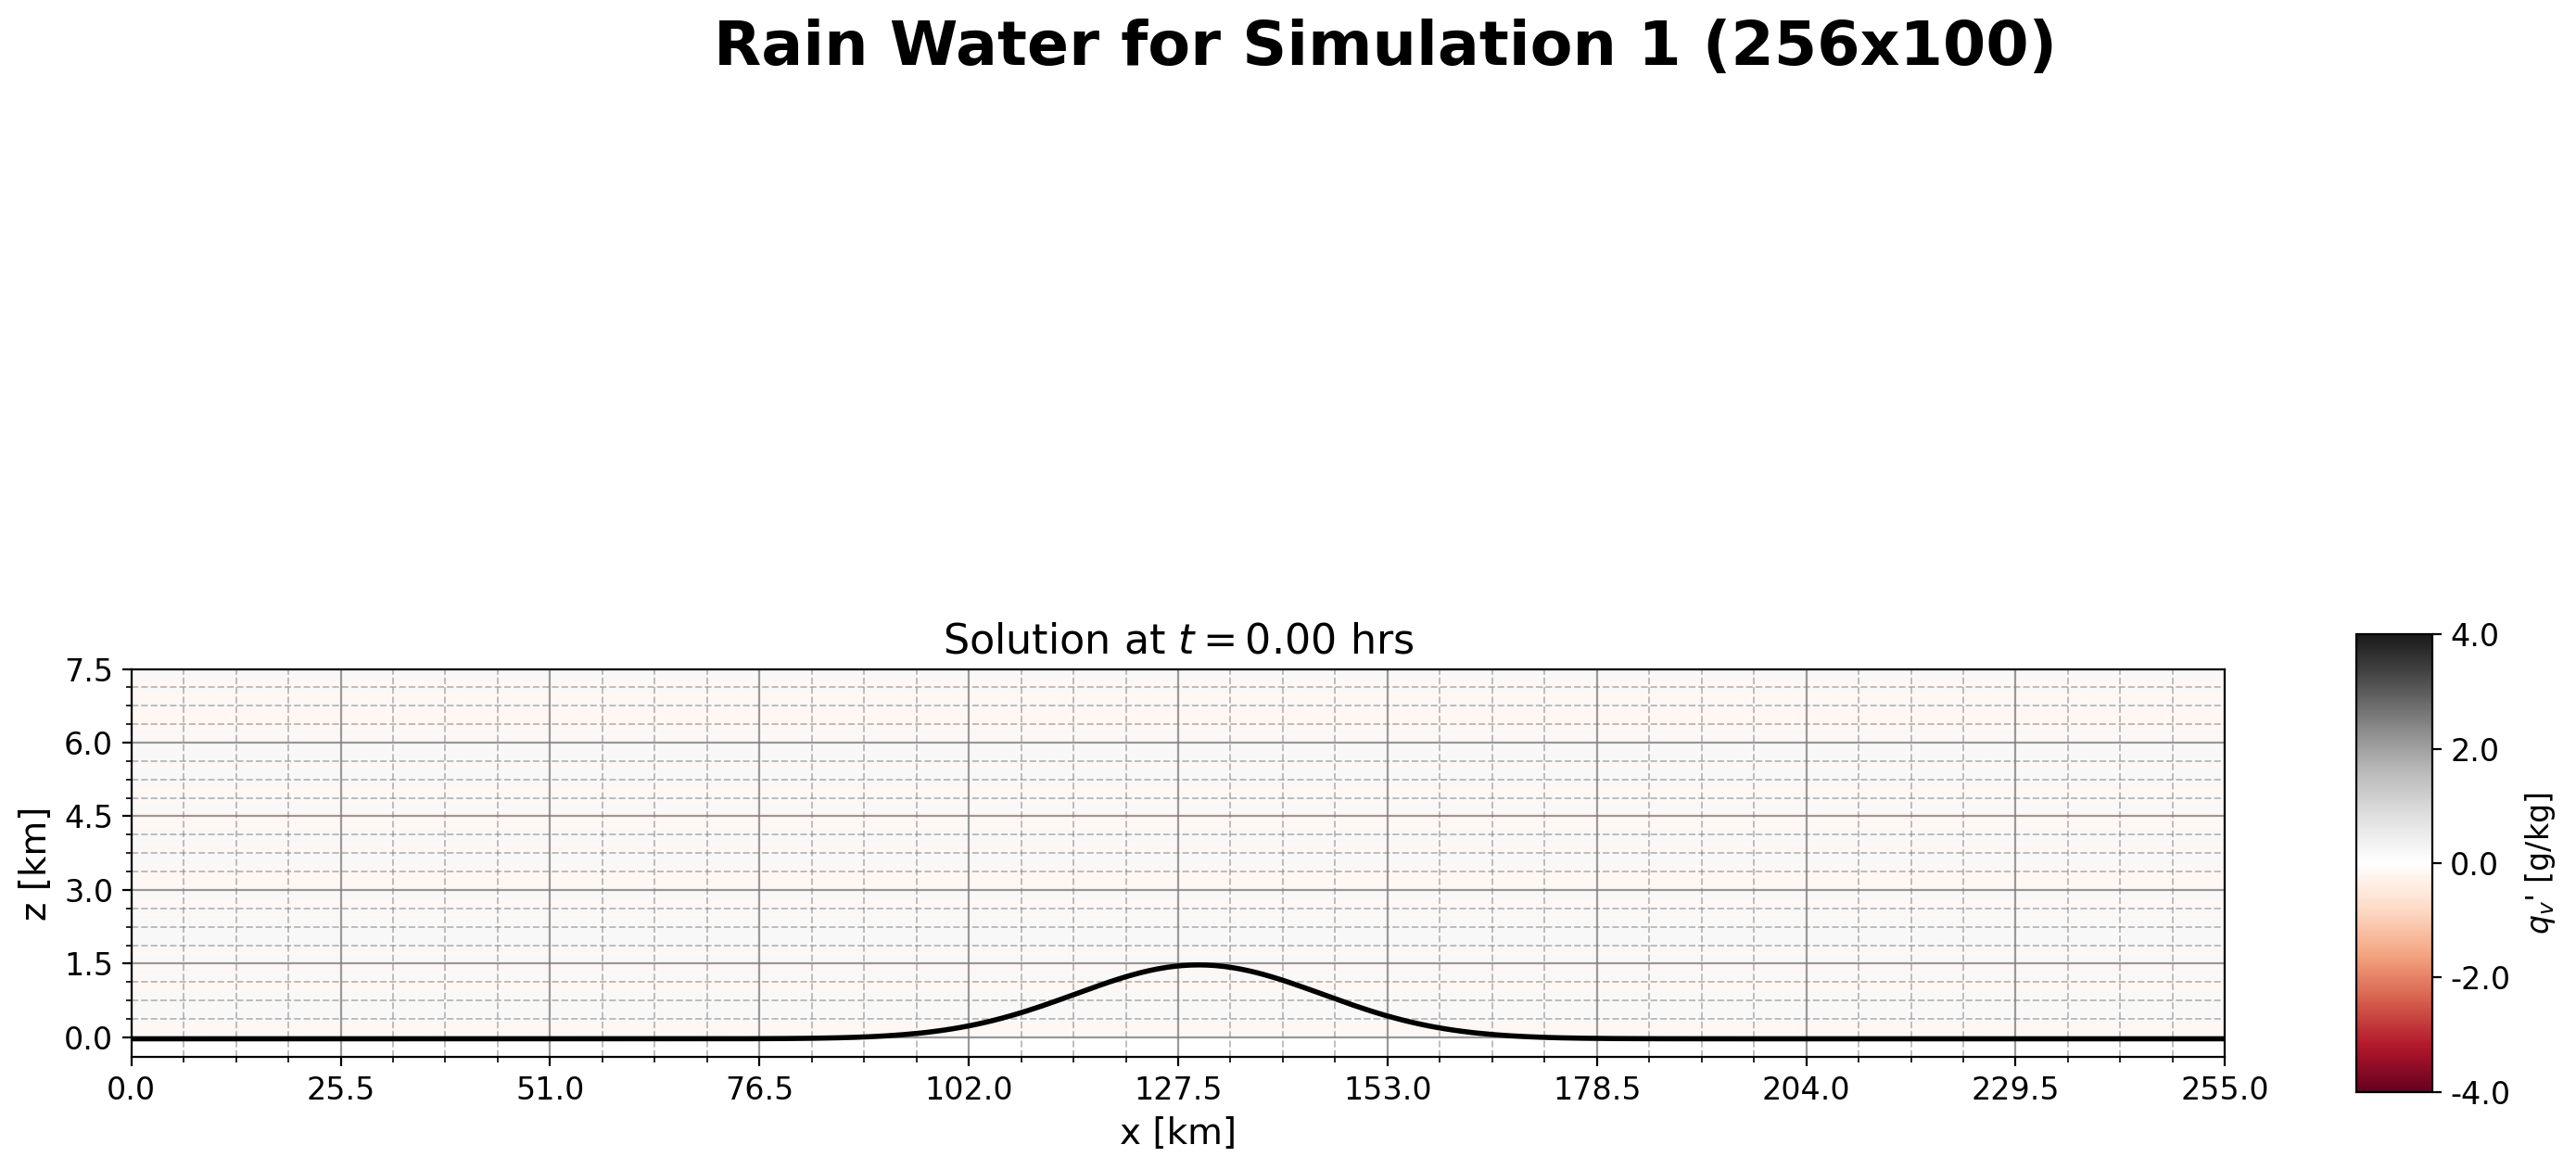

In [583]:
vmin = -0.004
vmax = 0.004

sim = ["(256x100)", "(201x201)","(401x401)"]

for i in range(0,1):
    Quantity = qv_s[i][:, :, :z_cut]
    x1, y1 = x[i][:, :z_cut], z[i][:, :z_cut]

    fig, ax = plt.subplots(figsize=(15, 9), dpi=200)

    # Filled and line contours
    cf = ax.contourf(x1, y1, Quantity[0]-np.mean(Quantity[0], axis=0, keepdims=True), levels=np.linspace(vmin, vmax, 25), cmap='RdGy', vmin=vmin, vmax=vmax, extend='both') #RdYlBu_r

    ax.plot(x_line, h, zorder=20, color='black', linewidth=2)

    # Labels and formatting
    ax.set_title(r"Solution at $t = $"+ f"{t_s[i][0]:.3f} sec", fontsize=16, y=1)
    plt.suptitle(f'Rain Water for Simulation {i+1} '+sim[i], fontsize=24, fontweight='bold', y=0.98)
    ax.set_xlabel('x [km]', fontsize=12)
    ax.set_ylabel('z [km]', fontsize=12)
    ax.tick_params(labelsize=12)
    ax.set_aspect(6, anchor='C')

    ax.minorticks_on()
    ax.set_xticks(np.linspace(x1.min(), x1.max(), 11))
    ax.set_xticklabels(f'{vals:.1f}' for vals in np.linspace(x1.min(), x1.max(), 11)/1000)
    ax.set_yticks(np.linspace(y1.min(), y1.max(), 6))
    ax.set_yticklabels(f'{vals:.1f}' for vals in np.linspace(y1.min(), y1.max(), 6)/1000)
    ax.set_xticks(np.linspace(x1.min(), x1.max(), 41), minor=True)
    ax.set_yticks(np.linspace(y1.min(), y1.max(), 21), minor=True)
    ax.grid(True, which='major', linestyle='-', color='grey', linewidth=0.8, alpha=0.8)
    ax.grid(True, which='minor', linestyle='--', color='grey', linewidth=0.7, alpha=0.5)
     #    fig.subplots_adjust(left=0.07, right=0.93, top=0.88, bottom=0.1)


    # Colorbar
    norm = colors.Normalize(vmin=vmin, vmax=vmax)
    mappable = cm.ScalarMappable(norm=norm, cmap='RdGy')
    mappable.set_array([])
    cbar = fig.colorbar(mappable, ax=ax, shrink=0.3, aspect=6)
    cbar.set_label(f"$q_v$' [g/kg]", fontsize=12, labelpad=5)
    cbar.ax.tick_params(labelsize=12)
    formatter = FuncFormatter(lambda val, _: f"{val * 1000:.1f}")
    cbar.ax.yaxis.set_major_formatter(formatter)
    fig.tight_layout()

    def update(n):
        ax.clear()

        # Filled and black line contours
        cf = ax.contourf(x1, y1, Quantity[n]-np.mean(Quantity[n], axis=0, keepdims=True), levels=np.linspace(vmin, vmax, 25), cmap='RdGy', vmin=vmin, vmax=vmax, extend='both')
        ax.plot(x_line, h, zorder=20, color='black', linewidth=2)

        # Title and labels
        ax.set_title(r"Solution at $t = $"+ f"{t_s[i][n]/3600:.2f} hrs", fontsize=16, y=1)
        ax.set_xlabel('x [km]', fontsize=14)
        ax.set_ylabel('z [km]', fontsize=14)
        ax.tick_params(labelsize=12)
        ax.set_aspect(6, anchor='C')

        # Ticks and grid
        ax.minorticks_on()
        ax.set_xticks(np.linspace(x1.min(), x1.max(), 11))
        ax.set_xticklabels(f'{vals:.1f}' for vals in np.linspace(x1.min(), x1.max(), 11)/1000)
        ax.set_yticks(np.linspace(y1.min(), y1.max(), 6))
        ax.set_yticklabels(f'{vals:.1f}' for vals in np.linspace(y1.min(), y1.max(), 6)/1000)
        ax.set_xticks(np.linspace(x1.min(), x1.max(), 41), minor=True)
        ax.set_yticks(np.linspace(y1.min(), y1.max(), 21), minor=True)
        ax.grid(True, which='major', linestyle='-', color='grey', linewidth=0.8, alpha=0.8)
        ax.grid(True, which='minor', linestyle='--', color='grey', linewidth=0.7, alpha=0.5)

        return cf

    # Create and save animation
    ani = FuncAnimation(fig, update, frames=range(0,1801), interval=50, blit=False)

    filename = f"Mount_{i+1}_VaporMan.mp4"
    ani.save(filename, writer='ffmpeg', fps=20)
    print(f'Simulation {i+1} is complete!')

    # Display in notebook
    display(HTML(f"""<video width="720" height="480" controls><source src="{Path(filename).as_posix()}" type="video/mp4">
      Your browser does not support the video tag.</video>"""))

#### Velocity/Other

Simulation 1 is complete!


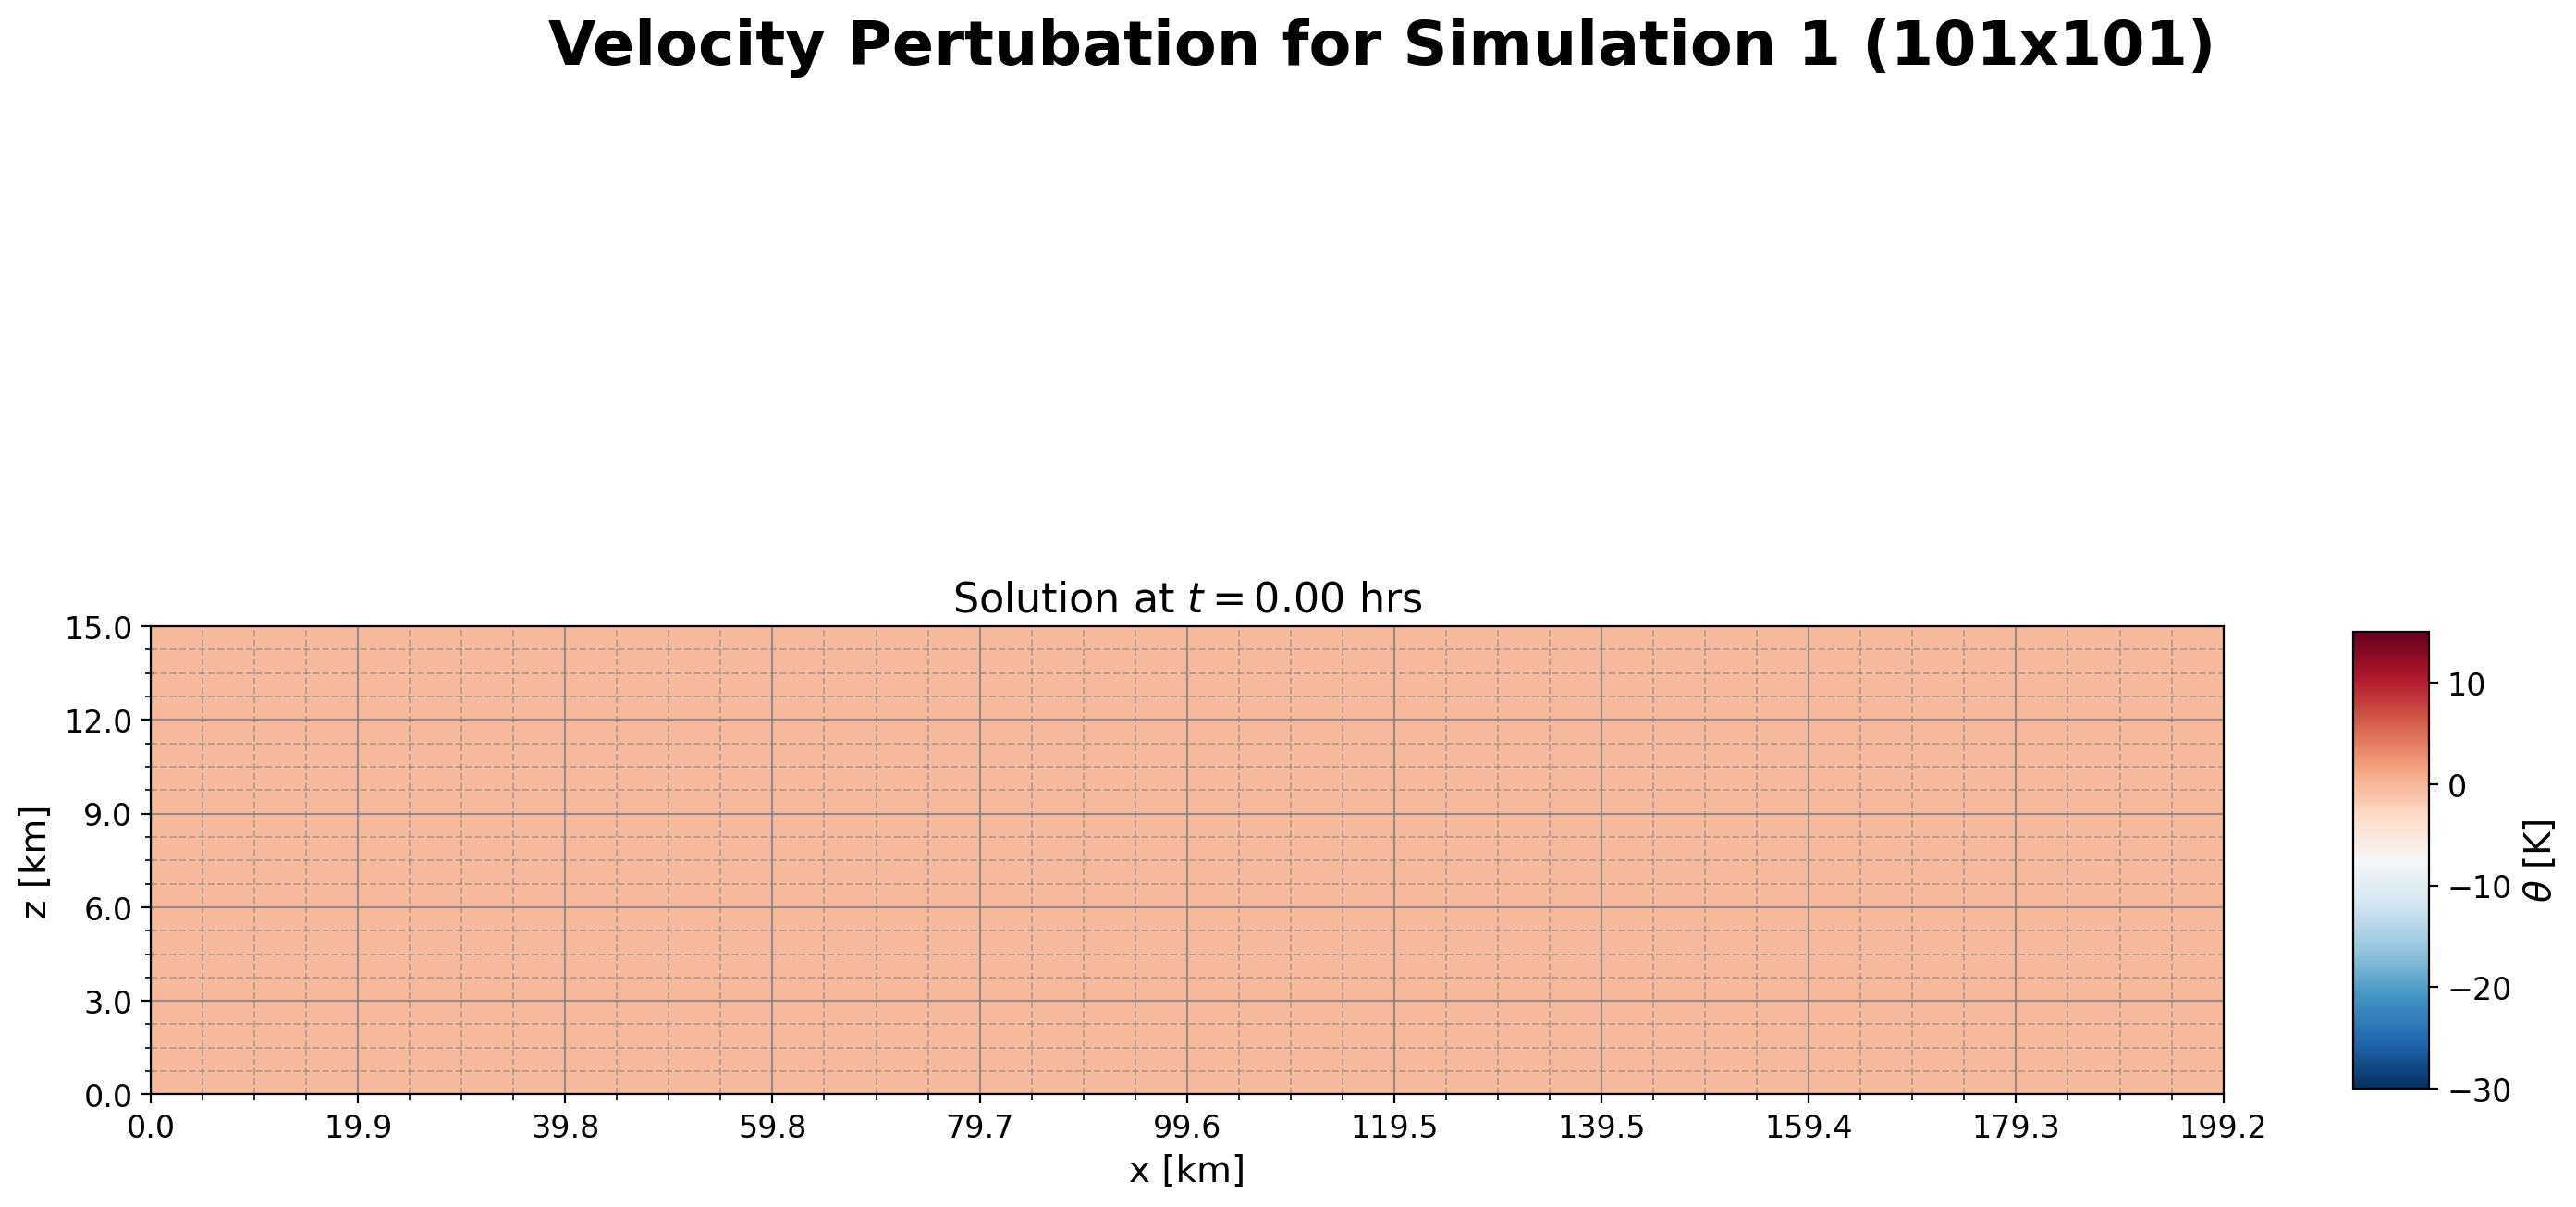

In [794]:
vmin = -30
vmax = 15

sim = ["(101x101)", "(201x201)","(401x401)"]
 

for i in range(0,1):
    Quantity = u_s[i]
    x1, y1 = x[i], z[i]

    fig, ax = plt.subplots(figsize=(15, 9), dpi=200)

    # Filled and line contours
    cf = ax.contourf(x1, y1, Quantity[0], levels=np.linspace(vmin, vmax, 50), cmap='RdBu_r', vmin=vmin, vmax=vmax, extend='both') #RdYlBu_r

    # Labels and formatting
    ax.set_title(r"Solution at $t = $"+ f"{t_s[i][0]:.3f} sec", fontsize=16, y=1)
    plt.suptitle(f'Velocity Pertubation for Simulation {i+1} '+sim[i], fontsize=24, fontweight='bold', y=0.98)
    ax.set_xlabel('x [km]', fontsize=12)
    ax.set_ylabel('z [km]', fontsize=12)
    ax.tick_params(labelsize=12)
    ax.set_aspect(3, anchor='C')

    ax.minorticks_on()
    ax.set_xticks(np.linspace(x1.min(), x1.max(), 11))
    ax.set_xticklabels(f'{vals:.1f}' for vals in np.linspace(x1.min(), x1.max(), 11)/1000)
    ax.set_yticks(np.linspace(y1.min(), y1.max(), 6))
    ax.set_yticklabels(f'{vals:.1f}' for vals in np.linspace(y1.min(), y1.max(), 6)/1000)
    ax.set_xticks(np.linspace(x1.min(), x1.max(), 41), minor=True)
    ax.set_yticks(np.linspace(y1.min(), y1.max(), 21), minor=True)
    ax.grid(True, which='major', linestyle='-', color='grey', linewidth=0.8, alpha=0.8)
    ax.grid(True, which='minor', linestyle='--', color='grey', linewidth=0.7, alpha=0.5)
     #    fig.subplots_adjust(left=0.07, right=0.93, top=0.88, bottom=0.1)


    # Colorbar
    norm = colors.Normalize(vmin=vmin, vmax=vmax)
    mappable = cm.ScalarMappable(norm=norm, cmap='RdBu_r')
    mappable.set_array([])
    cbar = fig.colorbar(mappable, ax=ax, shrink=0.3, aspect=6)
    cbar.set_label(r'$\theta$ [K]', fontsize=14)
    cbar.ax.tick_params(labelsize=12)
    fig.tight_layout()

    def update(n):
        ax.clear()

        # Filled and black line contours
        cf = ax.contourf(x1, y1, Quantity[n], levels=np.linspace(vmin, vmax, 50), cmap='RdBu_r', vmin=vmin, vmax=vmax, extend='both')

        # Title and labels
        ax.set_title(r"Solution at $t = $"+ f"{t_s[i][n]/3600:.2f} hrs", fontsize=16, y=1)
        ax.set_xlabel('x [km]', fontsize=14)
        ax.set_ylabel('z [km]', fontsize=14)
        ax.tick_params(labelsize=12)
        ax.set_aspect(3, anchor='C')

        # Ticks and grid
        ax.minorticks_on()
        ax.set_xticks(np.linspace(x1.min(), x1.max(), 11))
        ax.set_xticklabels(f'{vals:.1f}' for vals in np.linspace(x1.min(), x1.max(), 11)/1000)
        ax.set_yticks(np.linspace(y1.min(), y1.max(), 6))
        ax.set_yticklabels(f'{vals:.1f}' for vals in np.linspace(y1.min(), y1.max(), 6)/1000)
        ax.set_xticks(np.linspace(x1.min(), x1.max(), 41), minor=True)
        ax.set_yticks(np.linspace(y1.min(), y1.max(), 21), minor=True)
        ax.grid(True, which='major', linestyle='-', color='grey', linewidth=0.8, alpha=0.8)
        ax.grid(True, which='minor', linestyle='--', color='grey', linewidth=0.7, alpha=0.5)

        return cf

    # Create and save animation
    ani = FuncAnimation(fig, update, frames=range(int(len(Quantity))), interval=50, blit=False)

    filename = f"Sim_{i+1}_Vel.mp4"
    ani.save(filename, writer='ffmpeg', fps=20)
    print(f'Simulation {i+1} is complete!')

    # Display in notebook
    display(HTML(f"""<video width="720" height="480" controls><source src="{Path(filename).as_posix()}" type="video/mp4">
      Your browser does not support the video tag.</video>"""))

#### Qr and Qv

In [261]:
from moviepy.video.io.VideoFileClip import VideoFileClip
from moviepy.video.compositing.CompositeVideoClip import CompositeVideoClip
from moviepy.video.io.ImageSequenceClip import ImageSequenceClip
from matplotlib.ticker import FuncFormatter

In [265]:
def make_animation(x1, y1, Quantity, t_vals, filename, cmap, vmin_, vmax_, label, sim_index):
    
    fig = plt.figure(figsize=(9, 6), dpi=200)
    plt.suptitle(f'Water Vapor for Simulation {sim_index+1} {sim[sim_index]}', fontsize=24, fontweight='bold')

    main_ax_rect = [0.1, 0.1, 0.7, 0.75]
    ax = fig.add_axes(main_ax_rect)
    if label == 'q_v':
        cbar_ax_rect = [0.81, 0.1, 0.03, 0.75]
    else: 
        cbar_ax_rect = [0.91, 0.1, 0.03, 0.75]
        
    cax = fig.add_axes(cbar_ax_rect)
    # --- Setup the Colorbar (the rest of the code is now consistent) ---
    norm = colors.Normalize(vmin=vmin_, vmax=vmax_)
    sm = cm.ScalarMappable(norm=norm, cmap=cmap)
    cbar = fig.colorbar(sm, cax=cax)
    cbar.set_label(f'${label}$ [g/kg]', fontsize=12, labelpad=5)
    cbar.ax.tick_params(labelsize=8)
    formatter = FuncFormatter(lambda val, _: f"{val * 1000:.1f}")
    cbar.ax.yaxis.set_major_formatter(formatter)
    # --- Setup the initial plot labels and grid ---
    ax.set_xlabel('x [km]', fontsize=14)
    ax.set_ylabel('z [km]', fontsize=14)
    ax.tick_params(labelsize=12)
    ax.set_aspect(3, anchor='C')
    ax.minorticks_on()
    ax.set_xticks(np.linspace(x1.min(), x1.max(), 11))
    ax.set_xticklabels([f'{vals:.1f}' for vals in np.linspace(x1.min(), x1.max(), 11) / 1000])
    ax.set_yticks(np.linspace(y1.min(), y1.max(), 6))
    ax.set_yticklabels([f'{vals:.1f}' for vals in np.linspace(y1.min(), y1.max(), 6) / 1000])
    ax.grid(True, which='major', linestyle='-', color='grey', linewidth=0.8, alpha=0.8)

    # Initial drawing for the first frame
    cf_artists = ax.contourf(x1, y1, Quantity[0], levels=np.linspace(vmin_, vmax_, 50), cmap=cmap, vmin=vmin_, vmax=vmax_, extend='both')
    title = ax.set_title(f"Solution at t = {t_s[i][0]/3600:.2f} hrs", fontsize=16)

    # --- Update function (no changes needed here) ---
    def update(n):
        nonlocal cf_artists
        for c in cf_artists.get_children():
            c.remove()
        new_cf = ax.contourf(x1, y1, Quantity[n], levels=np.linspace(vmin_, vmax_, 50), cmap=cmap, vmin=vmin_, vmax=vmax_, extend='both')
        title.set_text(f"Solution at t = {t_s[i][n]/3600:.2f} hrs")
        cf_artists = new_cf
        return cf_artists.get_children() + [title]
    # --- Animation and saving (no changes needed here) ---
    ani = FuncAnimation(fig, update, frames=len(t_vals), interval=100, blit=True)
    ani.save(filename, writer='ffmpeg', fps=10)
    plt.close(fig)



# === Alpha blending function ===
def alpha_blend(fg, bg, alpha):
    """Alpha-blend two RGB frames."""
    return (alpha * fg + (1 - alpha) * bg).astype(np.uint8)

# === Main loop for simulations ===
sim = ["(101x101)", "(201x201)", "(401x401)"]

for i in range(0,1):
    x1, y1 = x[i], z[i]
    Quantity1 = qv_s[i]  # qv
    Quantity2 = qr_s[i]  # qr
    t_vals = t_s[i]
    qv_file = f"Sim_{i+1}_qv.mp4"
    qr_file = f"Sim_{i+1}_qr.mp4"
    out_file = f"Sim_{i+1}_Combined.mp4"

    # Generate both videos
    make_animation(x1, y1, Quantity1, t_vals, qv_file, cmap='Greys', vmin_=0, vmax_=0.01, label='q_v', sim_index=i)
    make_animation(x1, y1, Quantity2, t_vals, qr_file, cmap='Blues', vmin_=0, vmax_=0.006, label='q_r', sim_index=i)
    # Load both clips
    clip1 = VideoFileClip(qv_file)
    clip2 = VideoFileClip(qr_file)
    # Extract frames and alpha blend
    frames1 = list(clip1.iter_frames(fps=20, dtype="uint8"))
    frames2 = list(clip2.iter_frames(fps=20, dtype="uint8"))
    blended_frames = [alpha_blend(fg=f2, bg=f1, alpha=0.6) for f1, f2 in zip(frames1, frames2)]
    # Write combined video
    blended_clip = ImageSequenceClip(blended_frames, fps=20)
    blended_clip.write_videofile(out_file, fps=20)
    # Show video inline
    display(HTML(f"""<video width="720" height="480" controls><source src="{Path(out_file).as_posix()}" type="video/mp4">Your browser does not support the video tag. </video>"""))

MoviePy - Building video Sim_1_Combined.mp4.
MoviePy - Writing video Sim_1_Combined.mp4



MoviePy - Done !
MoviePy - video ready Sim_1_Combined.mp4


## Plots

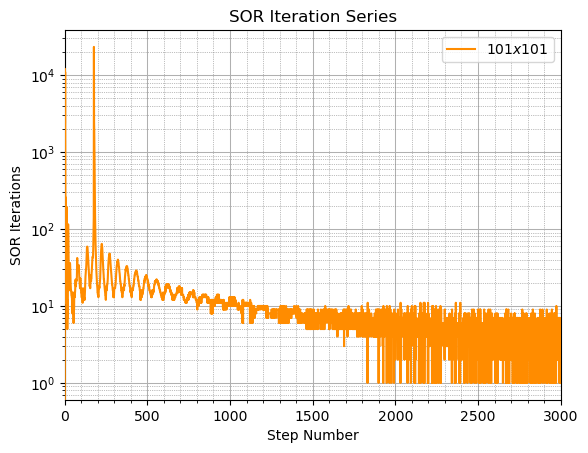

In [2140]:
plt.plot(n_t, l[0], color='darkorange', label='$101x101$',zorder=3)
#plt.plot(n_t, l[1], color='gold', label='$201x201$',zorder=4)
#plt.plot(n_t, l[2], color='green', label='$401x401$',zorder=5)
plt.minorticks_on()
plt.yscale('log')
plt.xlim(0,3000)
plt.legend()
plt.grid(True, which='major', linestyle='-', linewidth=0.75)
plt.grid(True, which='minor', linestyle=':', linewidth=0.5, color='gray')
plt.xlabel('Step Number')
plt.ylabel('SOR Iterations')
plt.title('SOR Iteration Series')
plt.savefig('JacobiIt.png', dpi=200)

In [289]:
from scipy.integrate import cumulative_trapezoid

R_int_time = cumulative_trapezoid(cons_R[0], t_s[0], initial=0)

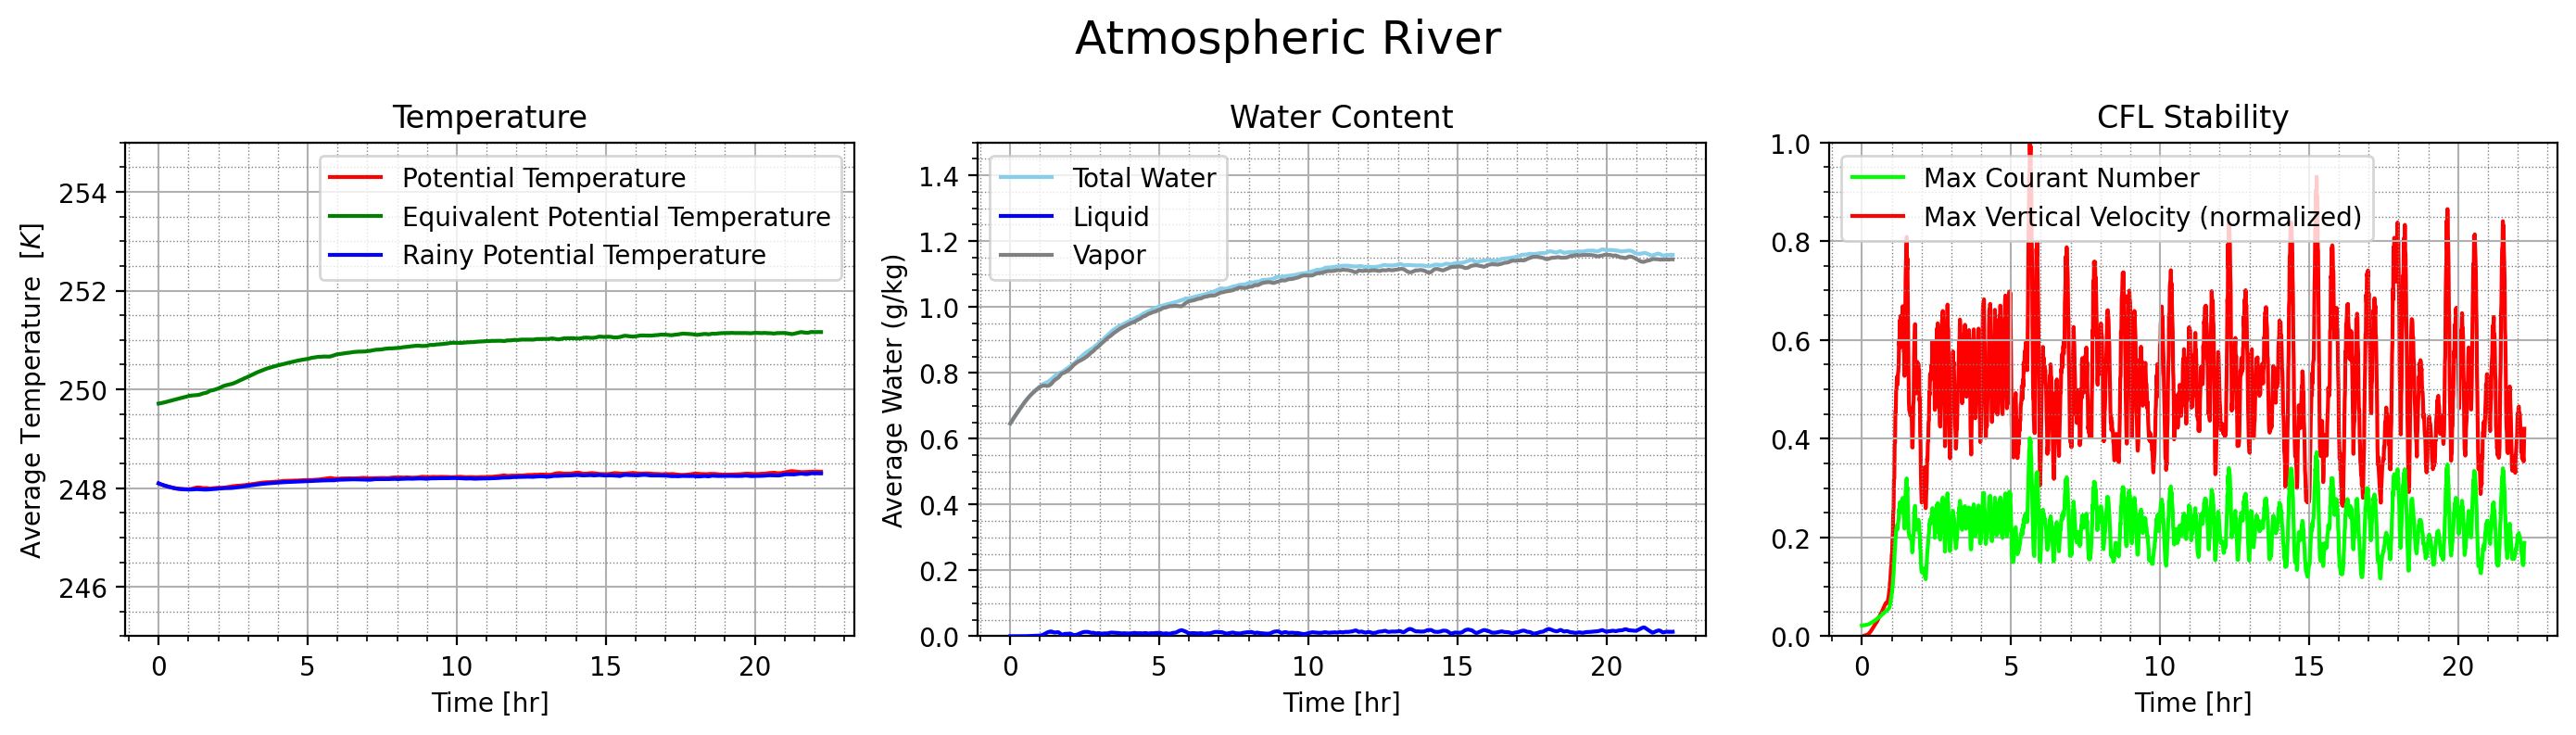

In [578]:
plt.figure(figsize=(14,4), dpi=200)
plt.subplot(1,3,1)
#plt.plot(t_s[0]/3600, temp_max[0], color='darkorange', label='Max Potential Temperature',zorder=3)
plt.plot(t_s[0]/3600, cons_pot[0]/(256000*15000), color='red', label='Potential Temperature',zorder=3)
plt.plot(t_s[0]/3600, cons_pote[0]/(256000*15000), color='green', label='Equivalent Potential Temperature',zorder=3)
plt.plot(t_s[0]/3600, cons_potr[0]/(256000*15000), color='blue', label='Rainy Potential Temperature',zorder=3)
plt.ylim(245,255)
plt.legend()
plt.xlabel('Time [hr]')
plt.minorticks_on()
plt.grid(True, which='major', linestyle='-', linewidth=0.75)
plt.grid(True, which='minor', linestyle=':', linewidth=0.5, color='gray')
plt.ylabel('Average Temperature  [$K$]')
plt.title('Temperature')

plt.subplot(1,3,3)
plt.plot(t_s[0]/3600, C[0], color='lime', label='Max Courant Number',zorder=3)
plt.plot(t_s[0]/3600, w_max[0]/(np.max(w_max[0])), color='red', label='Max Vertical Velocity (normalized)',zorder=1)
plt.ylim(0,1)
plt.legend()
plt.xlabel('Time [hr]')
plt.minorticks_on()
plt.grid(True, which='major', linestyle='-', linewidth=0.75)
plt.grid(True, which='minor', linestyle=':', linewidth=0.5, color='gray')
plt.title('CFL Stability')

plt.subplot(1,3,2)
plt.plot(t_s[0]/3600, cons_qt[0]*1000/(256000*15000), color='skyblue', label='Total Water',zorder=3)
plt.plot(t_s[0]/3600, cons_qr[0]*1000/(256000*15000), color='blue', label='Liquid',zorder=3)
plt.plot(t_s[0]/3600, cons_qv[0]*1000/(256000*15000), color='grey', label='Vapor',zorder=3)
plt.legend()
plt.xlabel('Time [hr]')
plt.ylim(0,1.5)
plt.minorticks_on()
plt.grid(True, which='major', linestyle='-', linewidth=0.75)
plt.grid(True, which='minor', linestyle=':', linewidth=0.5, color='gray')
plt.ylabel('Average Water (g/kg)')
plt.title('Water Content')
plt.suptitle('Atmospheric River',fontsize=18)
plt.tight_layout()
plt.savefig('Mount_Stats.png', dpi=200)

In [ ]:
plt.subplot(2,2,4)
#plt.plot(t_s[0]/3600, cons_K[0]/(256000*15000), color='skyblue', label='Total Water',zorder=3)
plt.plot(t_s[0]/3600, cons_B[0]/(256000*15000), color='grey', label='Liquid',zorder=3)
plt.plot(t_s[0]/3600, R_int_time/(256000*15000), color='grey', label='Liquid',zorder=3)
plt.legend()
plt.xlabel('Time [hr]')
plt.minorticks_on()
plt.grid(True, which='major', linestyle='-', linewidth=0.75)
plt.grid(True, which='minor', linestyle=':', linewidth=0.5, color='gray')
plt.ylabel('Total Water (g/kg)')
plt.title('Average Water Content')

plt.savefig('TempSer.png', dpi=200)